# Dynamic Nonlinear Synthetic Control: SCM-Style Placebo Validation

This notebook rebuilds the placebo validation workflow using the same core idea as the earlier synthetic-control notebook: **screen placebo cases first, then fit models only on cases that have enough target data and enough out-of-state regional donors**.

The previous version sampled placebo places first and only later discovered that many cases had no usable donor pool or insufficient pre/post data. This version fixes that by constructing an eligible `place_id × pseudo_date` table before any model is fit.

Main design choices:

1. Place IDs are cleaned into stable 8-digit strings.
2. Same-state donors are excluded, matching the stricter disaster donor-pool rule.
3. Placebo cases are required to have enough pre-period and post-period data before sampling.
4. Donor pools are required to have enough eligible out-of-state donors before sampling.
5. Classic SCM, linear ML, nonlinear ML, static donor selection, and dynamic donor selection are evaluated on the same screened placebo cases.
6. Hyperparameters are tuned only on the training placebo split, then evaluated on validation and test splits.


In [2]:
# Cell 1: Import packages and set global paths.
#
# This cell loads all libraries used by the notebook and defines project folders.
# The notebook assumes that the BPS panel already exists at
# output/bps_place_monthly_panel.csv relative to the project root.

from pathlib import Path
import sys, json, pickle, time, warnings
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Tuple, Iterable, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.model_selection import ParameterGrid
from scipy.optimize import nnls

HAS_XGB = False
XGBRegressor = None
XGB_IMPORT_ERROR = None
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError as exc:
    XGB_IMPORT_ERROR = f"not installed ({exc})"
except Exception as exc:
    XGB_IMPORT_ERROR = f"import failed ({type(exc).__name__}: {exc})"

warnings.filterwarnings("ignore")
warnings.filterwarnings(
    "ignore",
    message=".*sklearn.utils.parallel.delayed.*",
    category=UserWarning,
)

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.append(str(PROJECT_DIR))

OUTPUT_DIR = PROJECT_DIR / "output"
FIGURES_DIR = PROJECT_DIR / "figures"
CONFIG_DIR = PROJECT_DIR / "config"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

PANEL_PATH = OUTPUT_DIR / "bps_place_monthly_panel.csv"
RANDOM_SEED = 0
rng = np.random.default_rng(RANDOM_SEED)

print("PROJECT_DIR:", PROJECT_DIR)
print("PANEL_PATH:", PANEL_PATH)
print("XGBoost available:", HAS_XGB)
if not HAS_XGB:
    print("XGBoost note:", XGB_IMPORT_ERROR or "unavailable")
    print("Install with: pip install xgboost")


PROJECT_DIR: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo
PANEL_PATH: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\output\bps_place_monthly_panel.csv
XGBoost available: True


In [3]:
# Cell 2: Define experiment settings.
#
# These settings control the whole experiment. The most important change relative
# to the previous version is that placebo eligibility is checked before sampling.
# Same-state donor exclusion is intentionally kept.

@dataclass
class ExperimentConfig:
    # Number of screened placebo cases to sample after eligibility filtering.
    N_PLACEBO_RUNS: int = 3000

    # Placebo target requirements.
    MIN_AVG_PERMITS: float = 2.0
    MIN_MONTHS: int = 180
    PRE_MONTHS: int = 60
    POST_MONTHS: int = 48
    LAG: int = 12

    # Donor pool rules. EXCLUDE_SAME_STATE stays True by design.
    DONOR_POOL_SIZE: int = 500
    TOP_K_DONORS: int = 50
    MIN_DONORS: int = 10
    DONOR_MIN_AVG_PERMITS: float = 2.0
    EXCLUDE_SAME_STATE: bool = True
    USE_REGION_POOL: bool = True
    EXCLUDE_KNOWN_DISASTER_PLACES: bool = True

    # Candidate pseudo-treatment dates.
    PSEUDO_DATES: Tuple[str, ...] = (
        "2012-01-01", "2014-01-01", "2016-01-01", "2018-01-01", "2020-01-01"
    )

    # Split fractions at the placebo-case level.
    TRAIN_FRAC: float = 0.50
    VALID_FRAC: float = 0.25
    TEST_FRAC: float = 0.25

    # Split strategy options:
    # - "case_random": original random split at placebo-case level.
    # - "place_grouped_random": split by place_id, avoiding leakage across splits.
    # - "temporal_pseudo_date": split by pseudo_date, testing temporal generalization.
    SPLIT_STRATEGY: str = "place_grouped_random"
    
    # Used only when SPLIT_STRATEGY == "temporal_pseudo_date".
    TEMPORAL_TRAIN_END: str = "2016-01-01"
    TEMPORAL_VALID_END: str = "2018-01-01"

    # Hyperparameter tuning.
    RUN_HYPERPARAMETER_TUNING: bool = True
    MAX_TUNING_PLACEBOS_PER_METHOD: int = 400
    MAX_PARAM_CANDIDATES_PER_METHOD: int = 10

    # Output controls.
    SAVE_PREDICTIONS: bool = True
    RUN_REAL_DISASTER_APPLICATION: bool = False

    # Known-disaster exclusion. Cell 5 now treats this as the first path to try,
    # then searches config/, output/, and project-level disaster-place files.
    DISASTER_CONFIG_PATH: str = str(CONFIG_DIR / "disaster_config.json")

CFG = ExperimentConfig()
print(asdict(CFG))


{'N_PLACEBO_RUNS': 3000, 'MIN_AVG_PERMITS': 2.0, 'MIN_MONTHS': 180, 'PRE_MONTHS': 60, 'POST_MONTHS': 48, 'LAG': 12, 'DONOR_POOL_SIZE': 500, 'TOP_K_DONORS': 50, 'MIN_DONORS': 10, 'DONOR_MIN_AVG_PERMITS': 2.0, 'EXCLUDE_SAME_STATE': True, 'USE_REGION_POOL': True, 'EXCLUDE_KNOWN_DISASTER_PLACES': True, 'PSEUDO_DATES': ('2012-01-01', '2014-01-01', '2016-01-01', '2018-01-01', '2020-01-01'), 'TRAIN_FRAC': 0.5, 'VALID_FRAC': 0.25, 'TEST_FRAC': 0.25, 'SPLIT_STRATEGY': 'place_grouped_random', 'TEMPORAL_TRAIN_END': '2016-01-01', 'TEMPORAL_VALID_END': '2018-01-01', 'RUN_HYPERPARAMETER_TUNING': True, 'MAX_TUNING_PLACEBOS_PER_METHOD': 400, 'MAX_PARAM_CANDIDATES_PER_METHOD': 10, 'SAVE_PREDICTIONS': True, 'RUN_REAL_DISASTER_APPLICATION': False, 'DISASTER_CONFIG_PATH': 'C:\\Users\\Lenovo\\bps_dnsc_repo\\bps-dnsc-repo\\config\\disaster_config.json'}


In [4]:
# Cell 3: Load and standardize the BPS place-month panel.
#
# This cell cleans place identifiers, constructs date/state/region columns, and
# converts permit counts to numeric values. The cleaning is deliberately robust
# because the earlier debugging showed place IDs like 6283000.0 and "00000nan".

CENSUS_REGIONS = {
    "Northeast": ["09", "23", "25", "33", "34", "36", "42", "44", "50"],
    "Midwest":   ["17", "18", "19", "20", "26", "27", "29", "31", "38", "39", "46", "55"],
    "South":     ["01", "05", "10", "11", "12", "13", "21", "22", "24", "28", "37", "40", "45", "47", "48", "51", "54"],
    "West":      ["02", "04", "06", "08", "15", "16", "30", "32", "35", "41", "49", "53", "56"],
}
STATE_TO_REGION = {st: region for region, states in CENSUS_REGIONS.items() for st in states}


def clean_place_id(x) -> str:
    """Convert any place ID representation into an 8-digit string."""
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none", "null", "00000nan"}:
        return ""
    if s.isdigit():
        return s.zfill(8)
    try:
        return str(int(float(s))).zfill(8)
    except Exception:
        return ""


def standardize_panel(panel: pd.DataFrame) -> pd.DataFrame:
    panel = panel.copy()
    panel["place_id"] = panel["place_id"].apply(clean_place_id)
    panel = panel[panel["place_id"] != ""].copy()

    if "date" not in panel.columns:
        panel["date"] = pd.to_datetime(
            panel["year"].astype(int).astype(str) + "-" + panel["month"].astype(int).astype(str) + "-01"
        )
    else:
        panel["date"] = pd.to_datetime(panel["date"])

    if "units_1" not in panel.columns:
        raise ValueError("Expected target column 'units_1' in the BPS panel.")
    panel["units_1"] = pd.to_numeric(panel["units_1"], errors="coerce").fillna(0.0)

    # Use the first two digits of place_id as the state FIPS. This matches the
    # earlier synthetic-control notebook, where pid_str[:2] defined state.
    panel["state_fips"] = panel["place_id"].str[:2]

    # Keep state_code for backward compatibility, but make it robust.
    if "state_code" not in panel.columns:
        panel["state_code"] = panel["state_fips"]
    panel["state_code"] = panel["state_code"].astype(str)

    # Prefer Census-region donor pools. If the panel already has region, keep it;
    # otherwise build it from state FIPS.
    if "region" not in panel.columns:
        panel["region"] = panel["state_fips"].map(STATE_TO_REGION).fillna("Unknown")
    panel["region"] = panel["region"].fillna("Unknown")

    return panel.sort_values(["place_id", "date"]).reset_index(drop=True)

panel = pd.read_csv(PANEL_PATH)
panel = standardize_panel(panel)

print("Panel shape:", panel.shape)
print("Date range:", panel["date"].min(), "to", panel["date"].max())
print("Number of places:", panel["place_id"].nunique())
print("Regions:", panel["region"].value_counts().to_dict())

# Pre-index the panel once so placebo loops do not rescan 6M+ rows per case.
print("Building wide panel index...")
PANEL_WIDE = (
    panel.groupby(["date", "place_id"])["units_1"]
    .sum()
    .reset_index()
    .pivot(index="date", columns="place_id", values="units_1")
    .sort_index()
    .astype(float)
)
PLACE_STATS = (
    panel.groupby("place_id")
    .agg(
        avg_permits=("units_1", "mean"),
        n_months=("date", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        state_fips=("state_fips", "first"),
        region=("region", "first"),
    )
    .reset_index()
)
print("Wide panel shape:", PANEL_WIDE.shape)
panel.head()


Panel shape: (3278006, 26)
Date range: 2000-01-01 00:00:00 to 2025-10-01 00:00:00
Number of places: 21011
Regions: {'Midwest': 1136577, 'Northeast': 942509, 'South': 773944, 'West': 424852, 'Unknown': 124}
Building wide panel index...
Wide panel shape: (310, 21011)


,place_id,state_code,id_6digit,county_code,place_name,year,month,zip_code,csa_code,cbsa_code,...,units_2_value,units_34_bldgs,units_34,units_34_value,units_5plus_bldgs,units_5plus,units_5plus_value,date,state_fips,region
0,01001000,1.0,1000.0,67.0,Abbeville,2000,1,36310,NaN,NaN,...,0,0,0,0,0,0,0,2000-01-01,01,South
1,01001000,1.0,1000.0,67.0,Abbeville,2000,2,36310,NaN,NaN,...,0,0,0,0,0,0,0,2000-02-01,01,South
2,01001000,1.0,1000.0,67.0,Abbeville,2000,3,36310,NaN,NaN,...,0,0,0,0,0,0,0,2000-03-01,01,South
3,01001000,1.0,1000.0,67.0,Abbeville,2000,4,36310,NaN,NaN,...,0,0,0,0,0,0,0,2000-04-01,01,South
4,01001000,1.0,1000.0,67.0,Abbeville,2000,5,36310,NaN,NaN,...,0,0,0,0,0,0,0,2000-05-01,01,South


In [71]:
# Cell 4: Define evaluation metrics and basic time-series helper functions.
#
# These functions are reused by every model. They compute errors, extract a
# single place time series, create complete monthly indexes, and build donor
# matrices with months as rows and donor place IDs as columns.

def rmspe(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2))) if len(y_true) else np.nan


def mae(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred))) if len(y_true) else np.nan


def smape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), 1e-6)
    return float(np.mean(2 * np.abs(y_true - y_pred) / denom)) if len(y_true) else np.nan


def safe_ratio(num, den) -> float:
    if pd.isna(num) or pd.isna(den):
        return np.nan
    return float(num / max(float(den), 1e-6))


def get_place_series(panel: pd.DataFrame, place_id: str) -> Optional[pd.Series]:
    place_id = clean_place_id(place_id)
    if place_id not in PANEL_WIDE.columns:
        return None
    s = PANEL_WIDE[place_id].dropna()
    if s.empty:
        return None
    return s.sort_index().astype(float)


def make_complete_monthly_series(s: pd.Series, start: pd.Timestamp, end: pd.Timestamp) -> pd.Series:
    idx = pd.date_range(start, end, freq="MS")
    return s.reindex(idx).fillna(0.0).astype(float)


def build_donor_matrix(panel: pd.DataFrame, donor_ids: Iterable[str]) -> pd.DataFrame:
    donor_ids = [clean_place_id(x) for x in donor_ids]
    donor_ids = [x for x in donor_ids if x and x in PANEL_WIDE.columns]
    if len(donor_ids) == 0:
        return pd.DataFrame()
    return PANEL_WIDE[donor_ids].copy()

def moving_average_rmspe(y_true, y_pred, window=12, min_periods=1) -> float:
    """
    RMSPE after applying a rolling moving average to both y_true and y_pred.

    This is better aligned with long-run BPS baseline forecasting than raw
    month-by-month RMSPE, because it reduces the effect of noisy monthly timing.
    """
    y_true = pd.Series(np.asarray(y_true, dtype=float))
    y_pred = pd.Series(np.asarray(y_pred, dtype=float))

    if len(y_true) == 0 or len(y_pred) == 0:
        return np.nan

    y_true_ma = y_true.rolling(window=window, min_periods=min_periods).mean()
    y_pred_ma = y_pred.rolling(window=window, min_periods=min_periods).mean()

    valid = y_true_ma.notna() & y_pred_ma.notna()
    if valid.sum() == 0:
        return np.nan

    return float(np.sqrt(np.mean((y_true_ma[valid] - y_pred_ma[valid]) ** 2)))

In [6]:

# Cell 5: Load known disaster places and define SCM-style donor-pool screening.
#
# This cell excludes known disaster-affected places before placebo sampling and
# donor screening. The previous version only looked for one file:
#     output/disaster_config.json
# which can silently produce zero excluded places if the repo stores the disaster
# config under config/, uses a CSV file, or names the file differently.
#
# This version searches multiple likely locations and supports JSON/CSV/Excel/TXT
# files containing place IDs. It also prints diagnostics so exclusion problems are
# visible immediately.

DISASTER_PLACE_ID_COLUMNS = {
    "place_id",
    "place_ids",
    "treated_place_id",
    "treated_place_ids",
    "affected_place_id",
    "affected_place_ids",
    "disaster_place_id",
    "disaster_place_ids",
    "exclude_place_id",
    "exclude_place_ids",
    "place_fips",
    "placefp",
    "place_code",
}

DISASTER_FILE_PATTERNS = [
    "*disaster*.json",
    "*disaster*.csv",
    "*disaster*.xlsx",
    "*disaster*.xls",
    "*treated*.json",
    "*treated*.csv",
    "*exclude*.json",
    "*exclude*.csv",
]


def _normalize_key(k) -> str:
    return str(k).strip().lower().replace("-", "_").replace(" ", "_")


def _looks_like_place_key(k) -> bool:
    """Return True for keys/columns that likely store Census place IDs."""
    kk = _normalize_key(k)
    if kk in DISASTER_PLACE_ID_COLUMNS:
        return True
    if "place" in kk and any(tok in kk for tok in ["id", "ids", "fips", "fp", "code"]):
        return True
    return False


def _add_place_value(value, places: set):
    """Add scalar/list place IDs after robust cleaning."""
    if isinstance(value, (list, tuple, set, np.ndarray, pd.Series)):
        for item in value:
            _add_place_value(item, places)
        return

    pid = clean_place_id(value)
    if pid:
        places.add(pid)


def _scan_json_for_places(obj, places: set):
    """Recursively scan JSON-like objects for place-ID fields."""
    if isinstance(obj, dict):
        for k, v in obj.items():
            if _looks_like_place_key(k):
                _add_place_value(v, places)
            else:
                _scan_json_for_places(v, places)
    elif isinstance(obj, list):
        for item in obj:
            _scan_json_for_places(item, places)


def discover_disaster_place_files(config_path=None) -> List[Path]:
    """Search likely repo locations for disaster-place files."""
    candidates = []

    if config_path is not None:
        candidates.append(Path(config_path))

    # Most likely explicit repo paths.
    candidates += [
        CONFIG_DIR / "disaster_config.json",
        CONFIG_DIR / "known_disaster_places.json",
        CONFIG_DIR / "known_disaster_places.csv",
        CONFIG_DIR / "disaster_places.csv",
        OUTPUT_DIR / "disaster_config.json",
        OUTPUT_DIR / "known_disaster_places.csv",
        PROJECT_DIR / "disaster_config.json",
        PROJECT_DIR / "known_disaster_places.csv",
    ]

    # Broader fallback search. Limit to project/config/output roots when possible.
    search_roots = [CONFIG_DIR, OUTPUT_DIR, PROJECT_DIR]
    for root in search_roots:
        if not root.exists():
            continue
        for pattern in DISASTER_FILE_PATTERNS:
            try:
                candidates.extend(root.glob(pattern))
                candidates.extend(root.glob(f"**/{pattern}"))
            except Exception:
                pass

    # Deduplicate while preserving order.
    out = []
    seen = set()
    for p in candidates:
        try:
            p = p.resolve()
        except Exception:
            p = Path(p)
        if str(p) not in seen and p.exists() and p.is_file():
            out.append(p)
            seen.add(str(p))
    return out


def load_known_disaster_places(config_path: str = None) -> Tuple[set, List[Path], Dict[str, int]]:
    """Load known disaster place IDs from all discovered JSON/CSV/Excel/TXT files.

    Returns
    -------
    places : set
        Cleaned 8-digit Census place IDs.
    files : list[Path]
        Files that were actually read.
    counts : dict
        Per-file number of unique IDs found.
    """
    files = discover_disaster_place_files(config_path)
    places = set()
    per_file_counts = {}

    for path in files:
        before = len(places)
        suffix = path.suffix.lower()

        try:
            if suffix == ".json":
                with open(path, "r", encoding="utf-8") as f:
                    raw = json.load(f)
                _scan_json_for_places(raw, places)

            elif suffix in {".csv", ".txt"}:
                if suffix == ".txt":
                    # One place ID per line is allowed.
                    with open(path, "r", encoding="utf-8") as f:
                        for line in f:
                            _add_place_value(line.strip(), places)
                else:
                    df = pd.read_csv(path)
                    cols = [c for c in df.columns if _looks_like_place_key(c)]
                    # If there is only one column, allow it as a simple ID list.
                    if not cols and df.shape[1] == 1:
                        cols = [df.columns[0]]
                    for c in cols:
                        _add_place_value(df[c].dropna().tolist(), places)

            elif suffix in {".xlsx", ".xls"}:
                xls = pd.ExcelFile(path)
                for sheet in xls.sheet_names:
                    df = pd.read_excel(path, sheet_name=sheet)
                    cols = [c for c in df.columns if _looks_like_place_key(c)]
                    if not cols and df.shape[1] == 1:
                        cols = [df.columns[0]]
                    for c in cols:
                        _add_place_value(df[c].dropna().tolist(), places)

        except Exception as exc:
            print(f"WARNING: could not read disaster-place file {path}: {exc}")

        added = len(places) - before
        if added > 0:
            per_file_counts[str(path)] = added

    return places, files, per_file_counts


def select_candidate_places(panel: pd.DataFrame, min_avg_permits=2.0, min_months=180, exclude_places=None) -> pd.DataFrame:
    """Select high-activity places with sufficient overall monthly coverage."""
    exclude_places = set() if exclude_places is None else {clean_place_id(x) for x in exclude_places}
    exclude_places.discard("")

    stats = (
        panel.groupby("place_id")
        .agg(
            n_months=("date", "nunique"),
            avg_permits=("units_1", "mean"),
            total_permits=("units_1", "sum"),
            state_fips=("state_fips", "first"),
            state_code=("state_code", "first"),
            region=("region", "first"),
            first_date=("date", "min"),
            last_date=("date", "max"),
        )
        .reset_index()
    )

    eligible_before_exclusion = stats[
        (stats["n_months"] >= min_months)
        & (stats["avg_permits"] >= min_avg_permits)
        & (stats["region"] != "Unknown")
    ].copy()

    excluded_from_candidate_pool = eligible_before_exclusion[
        eligible_before_exclusion["place_id"].isin(exclude_places)
    ]["place_id"].nunique()

    keep = eligible_before_exclusion[
        ~eligible_before_exclusion["place_id"].isin(exclude_places)
    ].copy()

    keep.attrs["eligible_before_disaster_exclusion"] = len(eligible_before_exclusion)
    keep.attrs["excluded_from_candidate_pool"] = int(excluded_from_candidate_pool)
    keep.attrs["exclude_places_matched_panel"] = int(stats["place_id"].isin(exclude_places).sum())

    return keep.sort_values(["avg_permits", "n_months"], ascending=False).reset_index(drop=True)


def target_has_window_coverage(place_row: pd.Series, pseudo_date: pd.Timestamp, cfg: ExperimentConfig) -> Tuple[bool, str]:
    """Check whether a target has enough data around one pseudo-treatment date."""
    pseudo_date = pd.Timestamp(pseudo_date)
    needed_start = pseudo_date - pd.DateOffset(months=cfg.PRE_MONTHS + cfg.LAG)
    post_end = pseudo_date + pd.DateOffset(months=cfg.POST_MONTHS - 1)
    if pd.Timestamp(place_row["first_date"]) > needed_start:
        return False, "target_starts_after_needed_pre_lag_window"
    if pd.Timestamp(place_row["last_date"]) < post_end:
        return False, "target_ends_before_needed_post_window"
    return True, "ok"


def get_donor_pool(panel, target_place_id, pre_start, post_end, cfg, exclude_places=None) -> List[str]:
    """Return eligible donors using regional pool and same-state exclusion.

    Uses precomputed PLACE_STATS instead of copying the full panel each call.
    """
    target_place_id = clean_place_id(target_place_id)
    exclude_places = set() if exclude_places is None else {clean_place_id(x) for x in exclude_places}
    exclude_places.discard("")

    target_rows = PLACE_STATS[PLACE_STATS["place_id"] == target_place_id]
    if target_rows.empty:
        return []

    target_info = target_rows.iloc[0]
    target_state = target_info["state_fips"]
    target_region = target_info["region"]

    needed_start = pre_start - pd.DateOffset(months=cfg.LAG)
    needed_months = len(pd.date_range(needed_start, post_end, freq="MS"))

    donor_stats = PLACE_STATS[PLACE_STATS["place_id"] != target_place_id].copy()
    if cfg.USE_REGION_POOL:
        donor_stats = donor_stats[donor_stats["region"] == target_region]
    if cfg.EXCLUDE_SAME_STATE:
        donor_stats = donor_stats[donor_stats["state_fips"] != target_state]
    if exclude_places:
        donor_stats = donor_stats[~donor_stats["place_id"].isin(exclude_places)]

    donor_stats = donor_stats[
        (donor_stats["avg_permits"] >= cfg.DONOR_MIN_AVG_PERMITS)
        & (donor_stats["n_months"] >= min(cfg.MIN_MONTHS, needed_months))
        & (donor_stats["first_date"] <= needed_start)
        & (donor_stats["last_date"] >= post_end)
    ].sort_values("avg_permits", ascending=False)

    return donor_stats["place_id"].head(cfg.DONOR_POOL_SIZE).tolist()


if CFG.EXCLUDE_KNOWN_DISASTER_PLACES:
    known_disaster_places, disaster_place_files, disaster_place_file_counts = load_known_disaster_places(
        CFG.DISASTER_CONFIG_PATH
    )
else:
    known_disaster_places, disaster_place_files, disaster_place_file_counts = set(), [], {}

candidate_places = select_candidate_places(panel, CFG.MIN_AVG_PERMITS, CFG.MIN_MONTHS, known_disaster_places)

panel_place_ids = set(panel["place_id"].dropna().astype(str))
matched_disaster_places = sorted(known_disaster_places.intersection(panel_place_ids))

print("Disaster-place files discovered/read:", len(disaster_place_files))
for p in disaster_place_files:
    print("  -", p)
print("Known disaster place IDs loaded:", len(known_disaster_places))
print("Known disaster place IDs matched in panel:", len(matched_disaster_places))
print("Candidate places before disaster exclusion:", candidate_places.attrs.get("eligible_before_disaster_exclusion", "NA"))
print("Known disaster places excluded from candidate pool:", candidate_places.attrs.get("excluded_from_candidate_pool", "NA"))
print("Candidate placebo places before date/donor screening:", len(candidate_places))

if CFG.EXCLUDE_KNOWN_DISASTER_PLACES and len(known_disaster_places) == 0:
    print(
        "\nWARNING: EXCLUDE_KNOWN_DISASTER_PLACES=True but no disaster place IDs were loaded.\n"
        "Check that a disaster config/list exists under config/, output/, or PROJECT_DIR, "
        "or update CFG.DISASTER_CONFIG_PATH to the correct file."
    )

if disaster_place_file_counts:
    print("Per-file unique disaster IDs added:")
    for k, v in disaster_place_file_counts.items():
        print(f"  {v:>4}  {k}")

display(candidate_places.head())


Disaster-place files discovered/read: 4
  - C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\output\disaster_config.json
  - C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\config\fema_disasters_by_metro.csv
  - C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\output\baker_logic_treated_ratios.csv
  - C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\output\baker_logic_treated_scm_diagnostics.csv
Known disaster place IDs loaded: 258
Known disaster place IDs matched in panel: 258
Candidate places before disaster exclusion: 3901
Known disaster places excluded from candidate pool: 252
Candidate placebo places before date/donor screening: 3649
Per-file unique disaster IDs added:
   258  C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\output\baker_logic_treated_scm_diagnostics.csv


,place_id,n_months,avg_permits,total_permits,state_fips,state_code,region,first_date,last_date
0,48298000,310,1079.174194,334544,48,48.0,South,2000-01-01,2025-10-01
1,48238500,262,471.790076,123609,48,48.0,South,2004-01-01,2025-10-01
2,37379000,310,460.861290,142867,37,37.0,South,2000-01-01,2025-10-01
3,48240500,310,437.838710,135730,48,48.0,South,2000-01-01,2025-10-01
4,32021000,309,437.025890,135041,32,32.0,West,2000-01-01,2025-10-01


In [7]:
# Cell 6: Define static and dynamic donor selection strategies.
#
# The first choice uses smoothed pre-period similarity. If rolling-correlation
# screening is too strict for a case, the function falls back to raw correlation,
# then to highest-activity donors. This keeps the experiment from failing simply
# because a correlation window produced no scores.

def donor_similarity_scores(target_series, donor_matrix, start_date, end_date, smooth_window=12) -> pd.DataFrame:
    target_win = target_series.loc[start_date:end_date].rolling(
        smooth_window, min_periods=max(3, smooth_window // 2)
    ).mean()
    scores = []
    for col in donor_matrix.columns:
        donor_win = donor_matrix[col].loc[start_date:end_date].rolling(
            smooth_window, min_periods=max(3, smooth_window // 2)
        ).mean()
        both = pd.concat([target_win, donor_win], axis=1).dropna()
        if len(both) < 12:
            continue
        corr = both.iloc[:, 0].corr(both.iloc[:, 1])
        rmse_norm = rmspe(both.iloc[:, 0], both.iloc[:, 1]) / max(float(both.iloc[:, 0].mean()), 1.0)
        score = (0.8 * corr if pd.notna(corr) else -999.0) - 0.2 * rmse_norm
        if pd.notna(score):
            scores.append({"place_id": col, "corr": corr, "rmse_norm": rmse_norm, "score": score})
    if not scores:
        return pd.DataFrame(columns=["place_id", "corr", "rmse_norm", "score"])
    return pd.DataFrame(scores).sort_values("score", ascending=False)


def select_top_donors(target_series, donor_matrix, start_date, end_date, top_k=50) -> List[str]:
    """Select donors by smoothed similarity, with stable fallbacks."""
    if donor_matrix.empty:
        return []

    scores = donor_similarity_scores(target_series, donor_matrix, start_date, end_date)
    if not scores.empty:
        return scores["place_id"].head(top_k).tolist()

    # Fallback 1: raw correlation without rolling smoothing.
    raw_scores = []
    target_win = target_series.loc[start_date:end_date]
    for col in donor_matrix.columns:
        donor_win = donor_matrix[col].loc[start_date:end_date]
        both = pd.concat([target_win, donor_win], axis=1).dropna()
        if len(both) < 12:
            continue
        corr = both.iloc[:, 0].corr(both.iloc[:, 1])
        if pd.notna(corr):
            raw_scores.append((col, corr))
    if raw_scores:
        raw_scores = sorted(raw_scores, key=lambda x: x[1], reverse=True)
        return [x[0] for x in raw_scores[:top_k]]

    # Fallback 2: highest-activity donors in the relevant window.
    donor_means = donor_matrix.loc[start_date:end_date].mean().sort_values(ascending=False)
    return donor_means.head(top_k).index.tolist()


def get_donor_sets(target_series, donor_matrix, pseudo_date, pre_start, pre_end, post_end, cfg) -> Dict[str, List[str]]:
    return {
        "static": select_top_donors(
            target_series, donor_matrix, pre_start, pre_end, cfg.TOP_K_DONORS
        ),
        "early": select_top_donors(
            target_series,
            donor_matrix,
            max(pre_start, pseudo_date - pd.DateOffset(months=36)),
            pre_end,
            cfg.TOP_K_DONORS,
        ),
        "late": select_top_donors(
            target_series,
            donor_matrix,
            pre_start,
            max(pre_start, pseudo_date - pd.DateOffset(months=13)),
            cfg.TOP_K_DONORS,
        ),
        "recent": select_top_donors(
            target_series,
            donor_matrix,
            max(pre_start, pseudo_date - pd.DateOffset(months=24)),
            pre_end,
            cfg.TOP_K_DONORS,
        ),
    }


In [8]:
# Cell 7: Build seasonal and lagged supervised-learning features.
#
# Seasonality is represented using month dummies, sine/cosine month encodings,
# a linear time index, target lags, donor lags, and same-month-last-year target
# information. Missing donor values are filled with zero, which is appropriate for
# sparse monthly count data after the panel has been aligned to a monthly index.

def seasonal_features(t: pd.Timestamp, i: int) -> List[float]:
    month = int(t.month)
    feats = [month, np.sin(2 * np.pi * month / 12), np.cos(2 * np.pi * month / 12), i, i / 12.0]
    feats.extend([1.0 if month == m else 0.0 for m in range(1, 12)])
    return feats


def build_lagged_dataset(target_series, donor_matrix, dates, donor_ids, lag=12):
    donor_ids = [clean_place_id(x) for x in donor_ids]
    donor_ids = [x for x in donor_ids if x in donor_matrix.columns]
    if len(donor_ids) == 0:
        return np.empty((0, 0)), np.array([]), pd.to_datetime([])

    donor_matrix = donor_matrix.reindex(dates).fillna(0.0)[donor_ids].sort_index()
    target_series = target_series.reindex(dates).fillna(0.0).sort_index()

    X, y, out_dates = [], [], []
    for i in range(lag, len(dates)):
        t = dates[i]
        hist_dates = dates[i - lag:i]
        donor_hist = donor_matrix.loc[hist_dates, donor_ids]
        target_hist = target_series.loc[hist_dates]

        row = []
        row.extend(donor_hist.values.flatten(order="F"))
        row.extend(donor_hist.mean(axis=0).values)
        row.extend(donor_hist.tail(3).mean(axis=0).values)
        row.extend(donor_hist.tail(12).mean(axis=0).values)
        row.extend(target_hist.values)
        row.append(target_hist.tail(3).mean())
        row.append(target_hist.tail(12).mean())
        row.append(target_hist.iloc[-1])
        row.append(target_hist.iloc[-12] if len(target_hist) >= 12 else target_hist.iloc[0])
        row.extend(seasonal_features(t, i))

        X.append(row)
        y.append(target_series.loc[t])
        out_dates.append(t)

    return np.asarray(X, dtype=float), np.asarray(y, dtype=float), pd.to_datetime(out_dates)


In [9]:
# Cell 8: Register baseline and nonlinear models, including classic SCM.
#
# The comparison set includes classic synthetic control with non-negative least
# squares, regularized linear models, tree-based nonlinear models, support-vector
# regression, neural-network regression, and XGBoost when available.

def get_model_registry(random_state=0) -> Dict[str, object]:
    registry = {
        "ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
        "lasso": Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=0.01, max_iter=5000))]),
        "elasticnet": Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000))]),
        "random_forest": RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=3, random_state=random_state, n_jobs=1),
        "extra_trees": ExtraTreesRegressor(n_estimators=300, max_depth=8, min_samples_leaf=3, random_state=random_state, n_jobs=1),
        "gradient_boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.03, max_depth=2, random_state=random_state),
        "hist_gradient_boosting": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.03, max_leaf_nodes=15, random_state=random_state),
        "mlp": Pipeline([("scaler", StandardScaler()), ("model", MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.001, learning_rate_init=0.001, max_iter=1000, random_state=random_state))]),
        "svr": Pipeline([("scaler", StandardScaler()), ("model", SVR(C=10.0, epsilon=0.1, gamma="scale"))]),
    }
    if HAS_XGB:
        registry["xgb"] = XGBRegressor(
            n_estimators=300, max_depth=3, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8, random_state=random_state,
            objective="reg:squarederror", n_jobs=1
        )
    return registry


def get_param_grids() -> Dict[str, List[dict]]:
    grids = {
        "ridge": list(ParameterGrid({"model__alpha": [0.1, 1.0, 10.0, 100.0]})),
        "lasso": list(ParameterGrid({"model__alpha": [0.001, 0.01, 0.1]})),
        "elasticnet": list(ParameterGrid({"model__alpha": [0.001, 0.01, 0.1], "model__l1_ratio": [0.2, 0.5, 0.8]})),
        "random_forest": list(ParameterGrid({"n_estimators": [200, 400], "max_depth": [5, 8, None], "min_samples_leaf": [2, 5]})),
        "extra_trees": list(ParameterGrid({"n_estimators": [200, 400], "max_depth": [5, 8, None], "min_samples_leaf": [2, 5]})),
        "gradient_boosting": list(ParameterGrid({"n_estimators": [150, 300], "learning_rate": [0.03, 0.05], "max_depth": [2, 3]})),
        "hist_gradient_boosting": list(ParameterGrid({"max_iter": [150, 300], "learning_rate": [0.03, 0.05], "max_leaf_nodes": [15, 31]})),
        "mlp": list(ParameterGrid({"model__hidden_layer_sizes": [(32,), (64, 32)], "model__alpha": [0.0001, 0.001]})),
        "svr": list(ParameterGrid({"model__C": [1.0, 10.0], "model__epsilon": [0.1, 0.5]})),
    }
    if HAS_XGB:
        grids["xgb"] = list(ParameterGrid({"n_estimators": [200, 400], "max_depth": [2, 3, 4], "learning_rate": [0.03, 0.05], "subsample": [0.8, 1.0]}))
    return grids


MODEL_REGISTRY = get_model_registry(RANDOM_SEED)
PARAM_GRIDS = get_param_grids()
MODEL_NAMES = list(MODEL_REGISTRY.keys())
print("ML models:", MODEL_NAMES)


def fit_predict_scm_nnls(target_series, donor_matrix, donors, pre_dates, pred_dates):
    donors = [d for d in donors if d in donor_matrix.columns]
    if len(donors) == 0:
        return np.array([]), np.array([]), {}
    y_pre = target_series.reindex(pre_dates).fillna(0.0).values.astype(float)
    X_pre = donor_matrix.reindex(pre_dates).fillna(0.0)[donors].values.astype(float)
    if X_pre.shape[0] < 12:
        return np.array([]), np.array([]), {}
    X_aug = np.column_stack([X_pre, np.ones(X_pre.shape[0])])
    weights_aug, _ = nnls(X_aug, y_pre)
    weights, intercept = weights_aug[:-1], weights_aug[-1]
    X_pred = donor_matrix.reindex(pred_dates).fillna(0.0)[donors].values.astype(float)
    y_pred = X_pred @ weights + intercept
    y_pre_hat = X_pre @ weights + intercept
    info = {
        "effective_donors": int(np.sum(weights > 1e-8)),
        "intercept": float(intercept),
        "weight_sum": float(weights.sum()),
    }
    return y_pred, y_pre_hat, info


ML models: ['ridge', 'lasso', 'elasticnet', 'random_forest', 'extra_trees', 'gradient_boosting', 'hist_gradient_boosting', 'mlp', 'svr', 'xgb']


In [10]:
# Cell 9: Define hyperparameter tuning utilities.
#
# Hyperparameters are tuned only on training placebo cases. Within each training
# placebo, the pre-period is split chronologically into an internal fit segment
# and an internal validation segment. Post-period outcomes are not used for tuning.

def chronological_pre_validation_split(dates, pseudo_date, val_months=12):
    pre_dates = dates[dates < pseudo_date]
    if len(pre_dates) <= val_months + 24:
        return dates < pseudo_date, np.zeros(len(dates), dtype=bool)
    val_start = pre_dates[-val_months]
    return dates < val_start, (dates >= val_start) & (dates < pseudo_date)


def tune_one_model_on_dataset(model_name, X, y, dates, pseudo_date, cfg):
    base_model = MODEL_REGISTRY[model_name]
    grid = PARAM_GRIDS.get(model_name, [{}])[:cfg.MAX_PARAM_CANDIDATES_PER_METHOD]
    fit_mask, val_mask = chronological_pre_validation_split(dates, pseudo_date)
    if fit_mask.sum() < 24 or val_mask.sum() < 6:
        return {}, np.inf
    best_params, best_score = {}, np.inf
    for params in grid:
        try:
            model = clone(base_model)
            model.set_params(**params)
            model.fit(X[fit_mask], y[fit_mask])
            pred = model.predict(X[val_mask])
            score = rmspe(y[val_mask], pred)
            if score < best_score:
                best_params, best_score = params, score
        except Exception:
            continue
    return best_params, best_score


def choose_global_hyperparams(tuning_records):
    if tuning_records.empty:
        return {m: {} for m in MODEL_NAMES}
    best = {}
    for model_name, g in tuning_records.groupby("model"):
        tmp = g.copy()
        tmp["params_key"] = tmp["params"].apply(lambda x: json.dumps(x, sort_keys=True))
        score = tmp.groupby("params_key")["val_rmspe"].median().sort_values()
        best[model_name] = json.loads(score.index[0]) if not score.empty else {}
    for m in MODEL_NAMES:
        best.setdefault(m, {})
    return best


In [11]:
# Cell 10: Build SCM-style eligible placebo specifications efficiently.
#
# This version is faster than the previous Cell 10 because it avoids looping
# over every target place to count donors. Instead, it uses region-level and
# state-level donor counts to estimate the number of out-of-state regional donors.
#
# Donor rule remains:
# - same Census region
# - different state
# - not known disaster place
# - enough data coverage
# - enough average permit activity

def build_place_metadata(panel: pd.DataFrame) -> pd.DataFrame:
    """
    Build a compact place-level metadata table.

    This table has one row per place, so it is much smaller than the full
    place-month panel and is suitable for fast eligibility screening.
    """
    meta = (
        panel.groupby("place_id")
        .agg(
            n_months=("date", "nunique"),
            avg_permits=("units_1", "mean"),
            min_date=("date", "min"),
            max_date=("date", "max"),
            state_fips=("state_fips", "first"),
            region=("region", "first"),
        )
        .reset_index()
    )

    meta["place_id"] = meta["place_id"].apply(clean_place_id)
    meta["min_date"] = pd.to_datetime(meta["min_date"])
    meta["max_date"] = pd.to_datetime(meta["max_date"])

    meta = meta[
        (meta["place_id"] != "")
        & (meta["region"].notna())
        & (meta["state_fips"].notna())
    ].copy()

    return meta

def assign_case_random_splits(sampled: pd.DataFrame, cfg, rng) -> pd.DataFrame:
    n = len(sampled)
    order = rng.permutation(n)
    split = np.empty(n, dtype=object)

    n_train = int(n * cfg.TRAIN_FRAC)
    n_valid = int(n * cfg.VALID_FRAC)

    split[order[:n_train]] = "train"
    split[order[n_train:n_train + n_valid]] = "valid"
    split[order[n_train + n_valid:]] = "test"

    out = sampled.copy()
    out["split"] = split
    return out


def assign_place_grouped_splits(sampled: pd.DataFrame, cfg, rng) -> pd.DataFrame:
    places = sampled["place_id"].drop_duplicates().to_numpy()
    n_places = len(places)

    order = rng.permutation(n_places)
    n_train = int(n_places * cfg.TRAIN_FRAC)
    n_valid = int(n_places * cfg.VALID_FRAC)

    split_map = {}

    for idx in order[:n_train]:
        split_map[places[idx]] = "train"

    for idx in order[n_train:n_train + n_valid]:
        split_map[places[idx]] = "valid"

    for idx in order[n_train + n_valid:]:
        split_map[places[idx]] = "test"

    out = sampled.copy()
    out["split"] = out["place_id"].map(split_map)
    return out


def assign_temporal_splits(sampled: pd.DataFrame, cfg) -> pd.DataFrame:
    out = sampled.copy()
    out["pseudo_date"] = pd.to_datetime(out["pseudo_date"])

    train_end = pd.to_datetime(cfg.TEMPORAL_TRAIN_END)
    valid_end = pd.to_datetime(cfg.TEMPORAL_VALID_END)

    out["split"] = np.where(
        out["pseudo_date"] <= train_end,
        "train",
        np.where(out["pseudo_date"] <= valid_end, "valid", "test"),
    )

    return out


def apply_split_strategy(sampled: pd.DataFrame, cfg, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    strategy = getattr(cfg, "SPLIT_STRATEGY", "place_grouped_random")

    if strategy == "case_random":
        out = assign_case_random_splits(sampled, cfg, rng)

    elif strategy == "place_grouped_random":
        out = assign_place_grouped_splits(sampled, cfg, rng)

    elif strategy == "temporal_pseudo_date":
        out = assign_temporal_splits(sampled, cfg)

    else:
        raise ValueError(f"Unknown SPLIT_STRATEGY: {strategy}")

    split_counts = out["split"].value_counts().to_dict()
    missing = [s for s in ["train", "valid", "test"] if s not in split_counts]

    if missing:
        raise ValueError(
            f"Split strategy '{strategy}' produced empty splits: {missing}."
        )

    return out
    
def build_eligible_placebo_specs_fast(
    panel: pd.DataFrame,
    candidate_places: pd.DataFrame,
    cfg,
    exclude_places=None,
    seed=0,
) -> pd.DataFrame:
    """
    Build eligible placebo cases using fast metadata screening.

    This function does not call get_donor_pool() and does not loop through
    every target to count donors. It estimates donor availability using
    vectorized region and state counts.
    """
    rng = np.random.default_rng(seed)

    exclude_places = set(exclude_places or [])
    exclude_places = {
        clean_place_id(x) for x in exclude_places
        if clean_place_id(x) != ""
    }

    place_meta = build_place_metadata(panel)

    candidate_ids = set(candidate_places["place_id"].apply(clean_place_id))
    candidate_ids = {x for x in candidate_ids if x != ""}

    place_meta = place_meta[place_meta["place_id"].isin(candidate_ids)].copy()

    if exclude_places:
        place_meta = place_meta[~place_meta["place_id"].isin(exclude_places)].copy()

    rows = []
    pseudo_dates = pd.to_datetime(list(cfg.PSEUDO_DATES))

    for pseudo_date in pseudo_dates:
        print(f"Screening pseudo date {pseudo_date.date()}...")

        pre_needed = pseudo_date - pd.DateOffset(months=cfg.PRE_MONTHS)
        post_needed = pseudo_date + pd.DateOffset(months=cfg.POST_MONTHS - 1)

        target_meta = place_meta[
            (place_meta["avg_permits"] >= cfg.MIN_AVG_PERMITS)
            & (place_meta["n_months"] >= cfg.MIN_MONTHS)
            & (place_meta["min_date"] <= pre_needed)
            & (place_meta["max_date"] >= post_needed)
        ].copy()

        donor_meta = place_meta[
            (place_meta["avg_permits"] >= cfg.DONOR_MIN_AVG_PERMITS)
            & (place_meta["n_months"] >= getattr(cfg, "DONOR_MIN_MONTHS", cfg.MIN_MONTHS))
            & (place_meta["min_date"] <= pre_needed)
            & (place_meta["max_date"] >= post_needed)
        ].copy()

        if target_meta.empty or donor_meta.empty:
            print(f"  targets={len(target_meta)}, donors={len(donor_meta)}; skipped.")
            continue

        # Count donors by region.
        region_counts = (
            donor_meta.groupby("region")
            .size()
            .rename("region_donor_count")
            .reset_index()
        )

        # Count donors by region and state.
        state_counts = (
            donor_meta.groupby(["region", "state_fips"])
            .size()
            .rename("same_state_donor_count")
            .reset_index()
        )

        # Attach counts to every target.
        target_meta = target_meta.merge(
            region_counts,
            on="region",
            how="left",
        )

        target_meta = target_meta.merge(
            state_counts,
            on=["region", "state_fips"],
            how="left",
        )

        target_meta["region_donor_count"] = target_meta["region_donor_count"].fillna(0)
        target_meta["same_state_donor_count"] = target_meta["same_state_donor_count"].fillna(0)

        # Same-region, different-state donor count.
        target_meta["n_candidate_donors"] = (
            target_meta["region_donor_count"]
            - target_meta["same_state_donor_count"]
        )

        # If the target itself is in donor_meta, it is already in the same-state count,
        # so it is excluded by the same-state exclusion automatically.
        target_meta = target_meta[
            target_meta["n_candidate_donors"] >= cfg.MIN_DONORS
        ].copy()

        if target_meta.empty:
            print("  no eligible target after donor-count screening.")
            continue

        target_meta["pseudo_date"] = pseudo_date

        rows.append(
            target_meta[
                [
                    "place_id",
                    "pseudo_date",
                    "avg_permits",
                    "n_months",
                    "state_fips",
                    "region",
                    "n_candidate_donors",
                ]
            ]
        )

        print(f"  eligible cases for this date: {len(target_meta)}")

    if not rows:
        return pd.DataFrame()

    eligible = pd.concat(rows, ignore_index=True)

    # Shuffle and sample final placebo cases.
    eligible = eligible.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    n = min(cfg.N_PLACEBO_RUNS, len(eligible))
    sampled = eligible.head(n).copy().reset_index(drop=True)

    # Assign train, validation, and test splits using the configured strategy.
    sampled = apply_split_strategy(sampled, cfg=cfg, seed=seed)
    
    return sampled


eligible_placebo_specs = build_eligible_placebo_specs_fast(
    panel=panel,
    candidate_places=candidate_places,
    cfg=CFG,
    exclude_places=known_disaster_places,
    seed=RANDOM_SEED,
)

placebo_specs = eligible_placebo_specs.copy()
placebo_specs.to_csv(OUTPUT_DIR / "dnsc_eligible_placebo_specs.csv", index=False)

print("Eligible placebo cases after fast SCM-style screening:", len(eligible_placebo_specs))

if not placebo_specs.empty:
    print(f"\nSplit strategy: {CFG.SPLIT_STRATEGY}")

    overlap_places = (
        placebo_specs.groupby("place_id")["split"].nunique() > 1
    ).sum()

    print(f"Places appearing in multiple splits: {overlap_places}")
    
    print("\nPseudo-date counts:")
    print(placebo_specs["pseudo_date"].value_counts().sort_index())

    print("\nCandidate donor summary:")
    print(placebo_specs["n_candidate_donors"].describe())

    display(placebo_specs.head())
else:
    print(
        "WARNING: no eligible placebo cases were found. "
        "Consider lowering MIN_AVG_PERMITS, DONOR_MIN_AVG_PERMITS, "
        "MIN_MONTHS, DONOR_MIN_MONTHS, or MIN_DONORS."
    )

Screening pseudo date 2012-01-01...
  eligible cases for this date: 3617
Screening pseudo date 2014-01-01...
  eligible cases for this date: 3632
Screening pseudo date 2016-01-01...
  eligible cases for this date: 3637
Screening pseudo date 2018-01-01...
  eligible cases for this date: 3636
Screening pseudo date 2020-01-01...
  eligible cases for this date: 3633
Eligible placebo cases after fast SCM-style screening: 3000

Split strategy: place_grouped_random
Places appearing in multiple splits: 0

Pseudo-date counts:
pseudo_date
2012-01-01    573
2014-01-01    579
2016-01-01    596
2018-01-01    599
2020-01-01    653
Name: count, dtype: int64

Candidate donor summary:
count    3000.000000
mean      806.742000
std       184.704245
min       502.000000
25%       652.000000
50%       809.000000
75%       948.250000
max      1131.000000
Name: n_candidate_donors, dtype: float64


,place_id,pseudo_date,avg_permits,n_months,state_fips,region,n_candidate_donors,split
0,55415500,2018-01-01,3.545802,262,55,Midwest,842,test
1,48738000,2012-01-01,17.325806,310,48,South,899,train
2,21525000,2016-01-01,35.783871,310,21,South,1087,train
3,12431000,2018-01-01,4.400000,310,12,South,1013,test
4,47587000,2020-01-01,6.225664,226,47,South,1054,test


In [12]:
# Cell 11: Define the full model-fitting routine for one placebo case.
#
# This function is the experiment unit. It returns model results, optional monthly
# predictions, and a metadata dictionary. The metadata always contains a readable
# reason, so skipped cases never return an opaque [] reason.

def make_meta(reason="success", tuning_records=None, **kwargs):
    meta = {"reason": reason, "tuning_records": [] if tuning_records is None else tuning_records}
    meta.update(kwargs)
    return meta


def evaluate_predictions(place_id, pseudo_date, split, method, variant, y_pre_true, y_pre_pred, y_post_true, y_post_pred, n_donors, extra=None):
    extra = {} if extra is None else extra
    pre_r = rmspe(y_pre_true, y_pre_pred)
    post_r = rmspe(y_post_true, y_post_pred)
    out = {
        "place_id": clean_place_id(place_id),
        "pseudo_date": pd.Timestamp(pseudo_date),
        "split": split,
        "method": method,
        "variant": variant,
        "n_donors": int(n_donors),
        "rmspe_pre": pre_r,
        "rmspe_post": post_r,
        "ratio": safe_ratio(post_r, pre_r),
        "post_mae": mae(y_post_true, y_post_pred),
        "post_smape": smape(y_post_true, y_post_pred),
        "post_bias": float(np.mean(np.asarray(y_post_true) - np.asarray(y_post_pred))) if len(y_post_true) else np.nan,
        "mean_post_true": float(np.mean(y_post_true)) if len(y_post_true) else np.nan,
        "mean_post_pred": float(np.mean(y_post_pred)) if len(y_post_pred) else np.nan,
    }
    out.update(extra)
    return out


def fit_predict_ml(model_name, X, y, dates, pseudo_date, post_end, fixed_params=None):
    train_mask = dates < pseudo_date
    post_mask = (dates >= pseudo_date) & (dates <= post_end)
    if train_mask.sum() < 24:
        return None, f"too_few_ml_train_samples: {train_mask.sum()}"
    if post_mask.sum() < 12:
        return None, f"too_few_ml_post_samples: {post_mask.sum()}"
    try:
        model = clone(MODEL_REGISTRY[model_name])
        if fixed_params:
            model.set_params(**fixed_params)
        model.fit(X[train_mask], y[train_mask])
        return {
            "y_pre_true": y[train_mask],
            "y_pre_pred": model.predict(X[train_mask]),
            "y_post_true": y[post_mask],
            "y_post_pred": model.predict(X[post_mask]),
            "post_dates": dates[post_mask],
            "pre_dates": dates[train_mask],
        }, "success"
    except Exception as e:
        return None, f"model_fit_or_predict_error_{model_name}: {type(e).__name__}: {str(e)}"


def run_placebo_one(panel, target_place_id, pseudo_date, split, cfg, fixed_params_by_model=None, return_predictions=False, exclude_places=None):
    fixed_params_by_model = {} if fixed_params_by_model is None else fixed_params_by_model
    target_place_id = clean_place_id(target_place_id)
    pseudo_date = pd.Timestamp(pseudo_date)
    pre_start = pseudo_date - pd.DateOffset(months=cfg.PRE_MONTHS)
    pre_end = pseudo_date - pd.DateOffset(months=1)
    post_end = pseudo_date + pd.DateOffset(months=cfg.POST_MONTHS - 1)
    all_dates = pd.date_range(pre_start - pd.DateOffset(months=cfg.LAG), post_end, freq="MS")
    pre_dates = pd.date_range(pre_start, pre_end, freq="MS")
    post_dates = pd.date_range(pseudo_date, post_end, freq="MS")

    if not target_place_id:
        return [], [], make_meta("invalid_target_place_id")

    target_raw = get_place_series(panel, target_place_id)
    if target_raw is None or target_raw.empty:
        return [], [], make_meta("target_series_missing")

    target_series = make_complete_monthly_series(target_raw, all_dates.min(), all_dates.max())

    donor_pool = get_donor_pool(panel, target_place_id, pre_start, post_end, cfg, exclude_places=exclude_places)
    if len(donor_pool) < cfg.MIN_DONORS:
        return [], [], make_meta(f"too_few_candidate_donors: {len(donor_pool)}")

    donor_matrix = build_donor_matrix(panel, donor_pool).reindex(all_dates).fillna(0.0)
    if donor_matrix.empty:
        return [], [], make_meta("empty_donor_matrix")

    donor_sets = get_donor_sets(target_series, donor_matrix, pseudo_date, pre_start, pre_end, post_end, cfg)
    if len(donor_sets.get("static", [])) < cfg.MIN_DONORS:
        return [], [], make_meta(f"too_few_static_selected_donors: {len(donor_sets.get('static', []))}")

    results, predictions, tuning_records = [], [], []
    failure_reasons = []

    # Classic SCM baseline.
    donors = donor_sets["static"]
    scm_post, scm_pre, scm_info = fit_predict_scm_nnls(target_series, donor_matrix, donors, pre_dates, post_dates)
    if len(scm_post) == len(post_dates):
        y_pre_true = target_series.reindex(pre_dates).fillna(0.0).values
        y_post_true = target_series.reindex(post_dates).fillna(0.0).values
        results.append(evaluate_predictions(
            target_place_id, pseudo_date, split, "scm_nnls", "static",
            y_pre_true, scm_pre, y_post_true, scm_post, len(donors), scm_info
        ))
        if return_predictions:
            predictions.extend([
                {"place_id": target_place_id, "pseudo_date": pseudo_date, "split": split, "method": "scm_nnls", "variant": "static", "date": d, "y_true": yt, "y_pred": yp}
                for d, yt, yp in zip(post_dates, y_post_true, scm_post)
            ])
    else:
        failure_reasons.append("scm_fit_failed")

    # Static ML models.
    for model_name in MODEL_NAMES:
        donors = donor_sets["static"]
        X, y, dates = build_lagged_dataset(target_series, donor_matrix, all_dates, donors, cfg.LAG)
        if X.size == 0:
            failure_reasons.append(f"empty_static_features_{model_name}")
            continue
        if cfg.RUN_HYPERPARAMETER_TUNING and split == "train" and not fixed_params_by_model:
            params, val_score = tune_one_model_on_dataset(model_name, X, y, dates, pseudo_date, cfg)
            tuning_records.append({
                "place_id": target_place_id,
                "pseudo_date": pseudo_date,
                "split": split,
                "model": model_name,
                "variant": "static",
                "params": params,
                "val_rmspe": val_score,
            })
        pred, pred_reason = fit_predict_ml(model_name, X, y, dates, pseudo_date, post_end, fixed_params_by_model.get(model_name, {}))
        if pred is None:
            failure_reasons.append(pred_reason)
            continue
        results.append(evaluate_predictions(
            target_place_id, pseudo_date, split, model_name, "static",
            pred["y_pre_true"], pred["y_pre_pred"], pred["y_post_true"], pred["y_post_pred"], len(donors)
        ))
        if return_predictions:
            predictions.extend([
                {"place_id": target_place_id, "pseudo_date": pseudo_date, "split": split, "method": model_name, "variant": "static", "date": d, "y_true": yt, "y_pred": yp}
                for d, yt, yp in zip(pred["post_dates"], pred["y_post_true"], pred["y_post_pred"])
            ])

    # Phase dynamic ML models.
    stage_specs = [
        ("early", pseudo_date, min(post_end, pseudo_date + pd.DateOffset(months=11)), donor_sets["early"]),
        ("late", pseudo_date + pd.DateOffset(months=12), post_end, donor_sets["late"]),
    ]
    for model_name in MODEL_NAMES:
        ypre, yprehat, ypost, yposthat, stage_rows = [], [], [], [], []
        n_donors_total = 0
        for stage_name, stage_start, stage_end, donors in stage_specs:
            if stage_start > post_end or len(donors) < cfg.MIN_DONORS:
                failure_reasons.append(f"too_few_{stage_name}_dynamic_donors_{model_name}: {len(donors)}")
                continue
            X, y, dates = build_lagged_dataset(target_series, donor_matrix, all_dates, donors, cfg.LAG)
            if X.size == 0:
                failure_reasons.append(f"empty_{stage_name}_dynamic_features_{model_name}")
                continue
            train_mask = dates < pseudo_date
            test_mask = (dates >= stage_start) & (dates <= stage_end)
            if train_mask.sum() < 24 or test_mask.sum() < 6:
                failure_reasons.append(f"too_few_{stage_name}_samples_{model_name}")
                continue
            try:
                model = clone(MODEL_REGISTRY[model_name])
                params = fixed_params_by_model.get(model_name, {})
                if params:
                    model.set_params(**params)
                model.fit(X[train_mask], y[train_mask])
                pre_hat = model.predict(X[train_mask])
                post_hat = model.predict(X[test_mask])
            except Exception as e:
                failure_reasons.append(f"phase_dynamic_error_{model_name}: {type(e).__name__}: {str(e)}")
                continue
            ypre.append(y[train_mask]); yprehat.append(pre_hat); ypost.append(y[test_mask]); yposthat.append(post_hat)
            n_donors_total += len(donors)
            if return_predictions:
                stage_rows.extend([
                    {"place_id": target_place_id, "pseudo_date": pseudo_date, "split": split, "method": model_name, "variant": f"phase_dynamic_{stage_name}", "date": d, "y_true": yt, "y_pred": yp}
                    for d, yt, yp in zip(dates[test_mask], y[test_mask], post_hat)
                ])
        if ypost:
            results.append(evaluate_predictions(
                target_place_id, pseudo_date, split, model_name, "phase_dynamic",
                np.concatenate(ypre), np.concatenate(yprehat), np.concatenate(ypost), np.concatenate(yposthat), n_donors_total
            ))
            predictions.extend(stage_rows)

    # Rolling/recent dynamic ML models.
    for model_name in MODEL_NAMES:
        donors = donor_sets["recent"]
        if len(donors) < cfg.MIN_DONORS:
            failure_reasons.append(f"too_few_recent_dynamic_donors_{model_name}: {len(donors)}")
            continue
        X, y, dates = build_lagged_dataset(target_series, donor_matrix, all_dates, donors, cfg.LAG)
        if X.size == 0:
            failure_reasons.append(f"empty_recent_dynamic_features_{model_name}")
            continue
        pred, pred_reason = fit_predict_ml(model_name, X, y, dates, pseudo_date, post_end, fixed_params_by_model.get(model_name, {}))
        if pred is None:
            failure_reasons.append(pred_reason)
            continue
        results.append(evaluate_predictions(
            target_place_id, pseudo_date, split, model_name, "rolling_recent_dynamic",
            pred["y_pre_true"], pred["y_pre_pred"], pred["y_post_true"], pred["y_post_pred"], len(donors)
        ))
        if return_predictions:
            predictions.extend([
                {"place_id": target_place_id, "pseudo_date": pseudo_date, "split": split, "method": model_name, "variant": "rolling_recent_dynamic", "date": d, "y_true": yt, "y_pred": yp}
                for d, yt, yp in zip(pred["post_dates"], pred["y_post_true"], pred["y_post_pred"])
            ])

    if len(results) == 0:
        reason = "; ".join(failure_reasons[:10]) if failure_reasons else "no_model_produced_results"
    else:
        reason = "success"

    return results, predictions, make_meta(
        reason=reason,
        tuning_records=tuning_records,
        n_candidate_donors=len(donor_pool),
        n_static_donors=len(donor_sets.get("static", [])),
        n_recent_donors=len(donor_sets.get("recent", [])),
    )


In [13]:
# Cell 12: Tune hyperparameters using only the training placebo split.
#
# This cell reads tuning records from the metadata returned by run_placebo_one().
# The validation and test placebo splits remain untouched during this stage.

if placebo_specs.empty:
    print("No placebo specs available. Skipping hyperparameter tuning.")
    tuning_df = pd.DataFrame()
    BEST_PARAMS_BY_MODEL = {m: {} for m in MODEL_NAMES}
else:
    tuning_records = []
    if CFG.RUN_HYPERPARAMETER_TUNING:
        train_specs_for_tuning = placebo_specs[placebo_specs["split"] == "train"].head(CFG.MAX_TUNING_PLACEBOS_PER_METHOD)
        print("Tuning on training placebo cases:", len(train_specs_for_tuning))
        for tune_idx, (_, row) in enumerate(train_specs_for_tuning.iterrows(), start=1):
            print(f"Tuning {tune_idx}/{len(train_specs_for_tuning)}: {row['place_id']} {pd.Timestamp(row['pseudo_date']).date()}")
            _, _, meta = run_placebo_one(
                panel,
                row["place_id"],
                row["pseudo_date"],
                row["split"],
                CFG,
                fixed_params_by_model={},
                return_predictions=False,
                exclude_places=known_disaster_places,
            )
            tuning_records.extend(meta.get("tuning_records", []))
        tuning_df = pd.DataFrame(tuning_records)
        tuning_df.to_csv(OUTPUT_DIR / "dnsc_placebo_tuning_records.csv", index=False)
        BEST_PARAMS_BY_MODEL = choose_global_hyperparams(tuning_df)
        with open(OUTPUT_DIR / "dnsc_best_params_by_model.json", "w") as f:
            json.dump(BEST_PARAMS_BY_MODEL, f, indent=2)
    else:
        tuning_df = pd.DataFrame()
        BEST_PARAMS_BY_MODEL = {m: {} for m in MODEL_NAMES}

print("Best params by model:")
print(BEST_PARAMS_BY_MODEL)


Tuning on training placebo cases: 400
Tuning 1/400: 48738000 2012-01-01
Tuning 2/400: 21525000 2016-01-01
Tuning 3/400: 34377000 2018-01-01
Tuning 4/400: 17073300 2018-01-01
Tuning 5/400: 28659000 2014-01-01
Tuning 6/400: 17436600 2014-01-01
Tuning 7/400: 49227000 2012-01-01
Tuning 8/400: 09245000 2012-01-01
Tuning 9/400: 06438000 2014-01-01
Tuning 10/400: 48738000 2016-01-01
Tuning 11/400: 45311000 2014-01-01
Tuning 12/400: 12075000 2014-01-01
Tuning 13/400: 26622500 2018-01-01
Tuning 14/400: 47283000 2018-01-01
Tuning 15/400: 37375000 2020-01-01
Tuning 16/400: 37140000 2012-01-01
Tuning 17/400: 26448000 2018-01-01
Tuning 18/400: 55420500 2018-01-01
Tuning 19/400: 13108000 2016-01-01
Tuning 20/400: 50215000 2020-01-01
Tuning 21/400: 18652000 2020-01-01
Tuning 22/400: 18162500 2020-01-01
Tuning 23/400: 18402000 2014-01-01
Tuning 24/400: 34276000 2012-01-01
Tuning 25/400: 42538000 2020-01-01
Tuning 26/400: 17676000 2018-01-01
Tuning 27/400: 08261000 2016-01-01
Tuning 28/400: 37601000 20

In [14]:
# Cell 13: Run the full placebo experiment and save raw outputs.
#
# This cell runs all screened placebo cases. Because cases were pre-screened in
# Cell 10, the valid-result rate should be much higher than in the previous
# random-first workflow. If a case still fails, the metadata reason is saved.
# Progress is checkpointed every 25 cases so a long run can be resumed safely.

RESULT_COLUMNS = [
    "place_id", "pseudo_date", "split", "method", "variant",
    "rmspe_pre", "rmspe_post", "ratio", "post_mae", "post_smape",
    "post_bias", "n_donors",
]
PREDICTION_COLUMNS = [
    "place_id", "pseudo_date", "split", "method", "variant", "date", "y_true", "y_pred"
]
CHECKPOINT_PATH = OUTPUT_DIR / "dnsc_placebo_checkpoint.pkl"
CHECKPOINT_EVERY = 25


def _placebo_case_key(row):
    return (
        clean_place_id(row["place_id"]),
        str(pd.Timestamp(row["pseudo_date"]).date()),
        row["split"],
    )


def _save_placebo_checkpoint(completed_keys, all_results, all_predictions, skipped_placebos):
    with open(CHECKPOINT_PATH, "wb") as f:
        pickle.dump(
            {
                "completed_keys": completed_keys,
                "all_results": all_results,
                "all_predictions": all_predictions,
                "skipped_placebos": skipped_placebos,
            },
            f,
        )


all_results, all_predictions, skipped_placebos = [], [], []
completed_keys = set()

if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH, "rb") as f:
        ckpt = pickle.load(f)
    completed_keys = set(ckpt.get("completed_keys", []))
    all_results = ckpt.get("all_results", [])
    all_predictions = ckpt.get("all_predictions", [])
    skipped_placebos = ckpt.get("skipped_placebos", [])
    print(f"Resuming from checkpoint: {len(completed_keys)}/{len(placebo_specs)} cases already done")

total_cases = len(placebo_specs)
for run_idx, (_, row) in enumerate(placebo_specs.iterrows(), start=1):
    case_key = _placebo_case_key(row)
    if case_key in completed_keys:
        continue

    t0 = time.time()
    print(
        f"Running placebo {run_idx}/{total_cases} | "
        f"split={row['split']} | place={row['place_id']} | date={pd.Timestamp(row['pseudo_date']).date()}"
    )
    try:
        res, pred, meta = run_placebo_one(
            panel,
            row["place_id"],
            row["pseudo_date"],
            row["split"],
            CFG,
            BEST_PARAMS_BY_MODEL,
            CFG.SAVE_PREDICTIONS,
            known_disaster_places,
        )
        reason = meta.get("reason", "no_reason_in_metadata") if isinstance(meta, dict) else str(meta)
        if len(res) == 0:
            skipped_placebos.append({
                "place_id": row["place_id"],
                "pseudo_date": row["pseudo_date"],
                "split": row["split"],
                "reason": reason,
            })
        all_results.extend(res)
        all_predictions.extend(pred)
    except Exception as e:
        skipped_placebos.append({
            "place_id": row["place_id"],
            "pseudo_date": row["pseudo_date"],
            "split": row["split"],
            "reason": f"exception: {type(e).__name__}: {str(e)}",
        })

    completed_keys.add(case_key)
    elapsed = time.time() - t0
    done = len(completed_keys)
    print(f"  finished in {elapsed:.1f}s | completed {done}/{total_cases}")

    if done % CHECKPOINT_EVERY == 0 or done == total_cases:
        _save_placebo_checkpoint(completed_keys, all_results, all_predictions, skipped_placebos)
        print(f"  checkpoint saved ({done}/{total_cases})")

placebo_df = pd.DataFrame(all_results)
if placebo_df.empty:
    placebo_df = pd.DataFrame(columns=RESULT_COLUMNS)
else:
    for col in RESULT_COLUMNS:
        if col not in placebo_df.columns:
            placebo_df[col] = np.nan
    placebo_df = placebo_df[RESULT_COLUMNS + [c for c in placebo_df.columns if c not in RESULT_COLUMNS]]

placebo_pred_df = pd.DataFrame(all_predictions)
if placebo_pred_df.empty:
    placebo_pred_df = pd.DataFrame(columns=PREDICTION_COLUMNS)
else:
    for col in PREDICTION_COLUMNS:
        if col not in placebo_pred_df.columns:
            placebo_pred_df[col] = np.nan
    placebo_pred_df = placebo_pred_df[PREDICTION_COLUMNS]

skipped_df = pd.DataFrame(skipped_placebos)
if skipped_df.empty:
    skipped_df = pd.DataFrame(columns=["place_id", "pseudo_date", "split", "reason"])

placebo_specs.to_csv(OUTPUT_DIR / "dnsc_placebo_specs.csv", index=False)
placebo_df.to_csv(OUTPUT_DIR / "dnsc_placebo_results_full.csv", index=False)
skipped_df.to_csv(OUTPUT_DIR / "dnsc_placebo_skipped_runs.csv", index=False)
if CFG.SAVE_PREDICTIONS:
    placebo_pred_df.to_csv(OUTPUT_DIR / "dnsc_placebo_predictions_full.csv", index=False)

if CHECKPOINT_PATH.exists() and len(completed_keys) >= total_cases:
    CHECKPOINT_PATH.unlink()
    print("Checkpoint removed after successful completion.")

print("Result shape:", placebo_df.shape)
print("Prediction shape:", placebo_pred_df.shape)
print("Skipped placebo runs:", len(skipped_df))
if not skipped_df.empty:
    print("\nTop skipped reasons:")
    print(skipped_df["reason"].value_counts().head(20))
if placebo_df.empty:
    print("\nWARNING: No valid placebo results were produced.")
else:
    print("\nValid result counts by split:")
    print(placebo_df.groupby("split").size())
    print("\nValid result counts by method and variant:")
    print(placebo_df.groupby(["method", "variant"]).size())


Running placebo 1/3000 | split=test | place=55415500 | date=2018-01-01
  finished in 21.0s | completed 1/3000
Running placebo 2/3000 | split=train | place=48738000 | date=2012-01-01
  finished in 24.2s | completed 2/3000
Running placebo 3/3000 | split=train | place=21525000 | date=2016-01-01
  finished in 24.2s | completed 3/3000
Running placebo 4/3000 | split=test | place=12431000 | date=2018-01-01
  finished in 21.3s | completed 4/3000
Running placebo 5/3000 | split=test | place=47587000 | date=2020-01-01
  finished in 13.7s | completed 5/3000
Running placebo 6/3000 | split=train | place=34377000 | date=2018-01-01
  finished in 19.2s | completed 6/3000
Running placebo 7/3000 | split=test | place=42013000 | date=2018-01-01
  finished in 16.2s | completed 7/3000
Running placebo 8/3000 | split=train | place=17073300 | date=2018-01-01
  finished in 21.8s | completed 8/3000
Running placebo 9/3000 | split=valid | place=39392800 | date=2014-01-01
  finished in 22.5s | completed 9/3000
Runni

VALIDATION summary, sorted by post RMSPE (absolute units):


,method,variant,n,median_rmspe_post,mean_rmspe_post,median_ratio,median_mae,median_smape,median_bias
27,svr,static,545,4.020969,9.274495,1.709640,2.940347,0.756251,0.727881
25,svr,phase_dynamic,545,4.047220,9.299690,1.731481,2.972314,0.756254,0.740425
11,hist_gradient_boosting,static,545,4.066840,8.736734,2.341848,2.924570,0.715302,0.335167
10,hist_gradient_boosting,rolling_recent_dynamic,545,4.079372,8.709629,2.315671,2.837085,0.730830,0.349052
26,svr,rolling_recent_dynamic,545,4.081611,9.331636,1.719855,2.937660,0.771491,0.865910
9,hist_gradient_boosting,phase_dynamic,545,4.084235,8.711873,2.304209,2.921943,0.724259,0.317302
5,extra_trees,static,545,4.102433,8.847915,7.654470,2.978340,0.708423,-0.023819
20,random_forest,static,545,4.176946,8.765942,3.426503,2.947182,0.701672,-0.016076
29,xgb,rolling_recent_dynamic,545,4.185685,8.926827,10.455077,2.988488,0.718884,0.002845
19,random_forest,rolling_recent_dynamic,545,4.188115,8.735312,3.349073,2.990646,0.685460,0.000000


TEST summary, sorted by post RMSPE (absolute units):


,method,variant,n,median_rmspe_post,mean_rmspe_post,median_ratio,median_mae,median_smape,median_bias
9,hist_gradient_boosting,phase_dynamic,547,3.751025,8.428240,2.409766,2.877605,0.706475,0.260761
11,hist_gradient_boosting,static,547,3.755143,8.341827,2.379786,2.883395,0.709526,0.223445
10,hist_gradient_boosting,rolling_recent_dynamic,547,3.756072,8.333530,2.408133,2.847608,0.718553,0.430713
27,svr,static,547,3.772470,9.170526,1.766215,2.811449,0.750107,0.771657
25,svr,phase_dynamic,547,3.798984,9.194459,1.763171,2.874271,0.757104,0.764576
28,xgb,phase_dynamic,547,3.821243,8.606042,10.829203,3.037833,0.705995,-0.001204
18,random_forest,phase_dynamic,547,3.831508,8.504961,3.398939,3.066467,0.679594,-0.004338
19,random_forest,rolling_recent_dynamic,547,3.835081,8.333823,3.415685,2.938317,0.653706,0.000000
26,svr,rolling_recent_dynamic,547,3.836108,9.213025,1.745801,2.806252,0.765969,0.866597
20,random_forest,static,547,3.855183,8.426192,3.388275,2.944688,0.680322,-0.006840



Relative improvement vs SCM on VALIDATION (positive = beats SCM):


...

Relative improvement vs SCM on TEST (positive = beats SCM):


,method,variant,n_paired,median_scm_rmspe_post,median_method_rmspe_post,median_relative_improvement_vs_scm,mean_relative_improvement_vs_scm,p10_relative_improvement_vs_scm,p90_relative_improvement_vs_scm,win_rate_vs_scm,median_scm_ratio,median_method_ratio
0,hist_gradient_boosting,static,747,4.855752,3.755143,0.080671,-0.004003,-0.212027,0.539720,0.607764,2.335964,2.379786
1,random_forest,rolling_recent_dynamic,747,4.855752,3.835081,0.078844,0.127283,-0.212159,0.565668,0.623829,2.335964,3.415685
2,extra_trees,rolling_recent_dynamic,747,4.855752,3.992209,0.076273,0.131482,-0.209998,0.574445,0.625167,2.335964,7.283425
3,hist_gradient_boosting,phase_dynamic,747,4.855752,3.751025,0.070959,-0.115033,-0.252672,0.541663,0.583668,2.335964,2.409766
4,random_forest,static,747,4.855752,3.855183,0.068991,0.101596,-0.191440,0.520276,0.610442,2.335964,3.388275
5,hist_gradient_boosting,rolling_recent_dynamic,747,4.855752,3.756072,0.068770,0.090029,-0.254801,0.551340,0.582329,2.335964,2.408133
6,extra_trees,static,747,4.855752,3.913085,0.065603,0.110147,-0.203096,0.529938,0.605087,2.335964,7.318097
7,xgb,rolling_recent_dynamic,747,4.855752,3.951334,0.059264,0.100485,-0.245664,0.551687,0.582329,2.335964,10.600983
8,random_forest,phase_dynamic,747,4.855752,3.831508,0.057720,0.034433,-0.214573,0.498414,0.597055,2.335964,3.398939
9,xgb,static,747,4.855752,3.902890,0.055278,0.056598,-0.219801,0.527887,0.579652,2.335964,10.557940


Overfitting diagnostics:


,split,method,variant,n,median_pre_rmspe,median_post_rmspe,median_post_pre_ratio,p75_ratio,p90_ratio
26,test,svr,rolling_recent_dynamic,547,2.223973,3.836108,1.745801,2.909464,5.715343
25,test,svr,phase_dynamic,547,2.240012,3.798984,1.763171,2.906548,5.916660
27,test,svr,static,547,2.244247,3.772470,1.766215,2.959917,5.786242
24,test,scm_nnls,static,547,1.974295,4.855752,2.335964,3.574468,7.835153
11,test,hist_gradient_boosting,static,547,1.587784,3.755143,2.379786,3.798308,6.566509
10,test,hist_gradient_boosting,rolling_recent_dynamic,547,1.568606,3.756072,2.408133,3.928572,6.847469
9,test,hist_gradient_boosting,phase_dynamic,547,1.579996,3.751025,2.409766,3.820227,6.555040
20,test,random_forest,static,547,1.099256,3.855183,3.388275,5.288605,9.722132
18,test,random_forest,phase_dynamic,547,1.108679,3.831508,3.398939,5.317179,9.580918
19,test,random_forest,rolling_recent_dynamic,547,1.117234,3.835081,3.415685,5.330252,9.592961


Best method selected on validation split (absolute RMSPE): svr static
Best method on validation by relative improvement vs SCM: extra_trees rolling_recent_dynamic (median rel. improvement = 0.067, win rate = 62.7%)


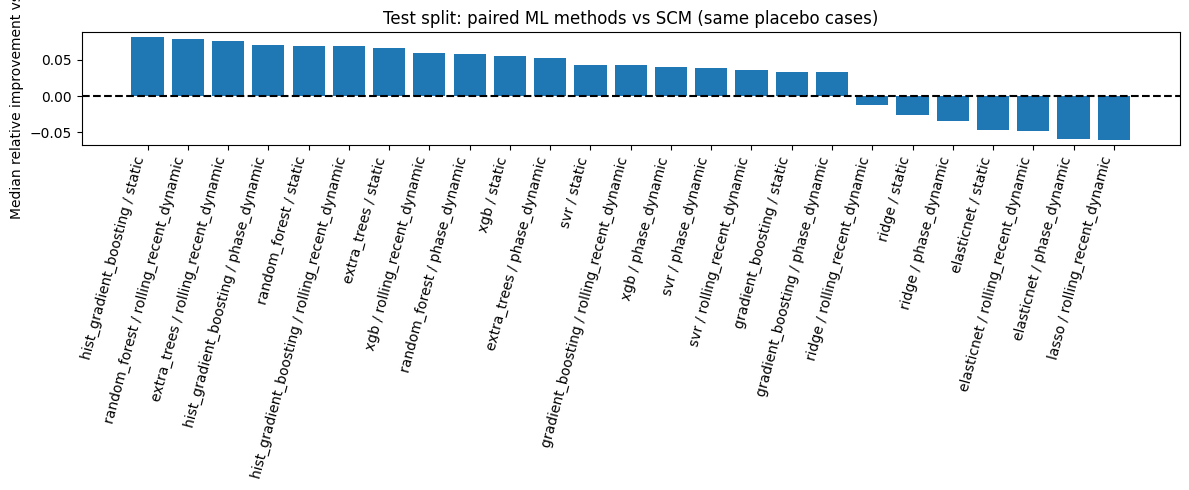

Saved: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\figures\dnsc_test_relative_improvement_vs_scm_top25.png


In [15]:
# Cell 14: Summarize validation/test results and diagnose overfitting.
#
# The validation split is used to choose the best method. The test split is only
# reported after validation-based method selection. The post/pre RMSPE ratio is a
# simple overfitting diagnostic: a model with very low pre-error but high post-error
# is likely overfitting the history.
#
# Post-period RMSPE is reported in absolute permit units. For cross-method comparison
# on the same placebo case, we also compute paired relative improvement vs SCM:
#   (scm_rmspe_post - method_rmspe_post) / scm_rmspe_post
# Positive values mean the method beat SCM on that case.

SCM_BASELINE = ("scm_nnls", "static")


def summarize_results(df, split=None):
    out_cols = [
        "method", "variant", "n", "median_rmspe_post", "mean_rmspe_post",
        "median_ratio", "median_mae", "median_smape", "median_bias"
    ]
    tmp = df.copy()
    if "split" not in tmp.columns or tmp.empty:
        return pd.DataFrame(columns=out_cols)
    if split is not None:
        tmp = tmp[tmp["split"] == split]
    if tmp.empty:
        return pd.DataFrame(columns=out_cols)
    return (
        tmp.groupby(["method", "variant"])
        .agg(
            n=("place_id", "nunique"),
            median_rmspe_post=("rmspe_post", "median"),
            mean_rmspe_post=("rmspe_post", "mean"),
            median_ratio=("ratio", "median"),
            median_mae=("post_mae", "median"),
            median_smape=("post_smape", "median"),
            median_bias=("post_bias", "median"),
        )
        .reset_index()
        .sort_values(["median_rmspe_post", "median_ratio"])
    )


def compute_paired_vs_scm(
    df,
    split=None,
    baseline=SCM_BASELINE,
    exclude_baseline=True,
):
    """Paired relative improvement vs SCM for every method on the same placebo cases."""
    tmp = df.copy()
    if split is not None:
        tmp = tmp[tmp["split"] == split]
    if tmp.empty:
        return pd.DataFrame()

    key_cols = ["place_id", "pseudo_date"]
    base_method, base_variant = baseline
    base = tmp[(tmp["method"] == base_method) & (tmp["variant"] == base_variant)][
        key_cols + ["rmspe_post", "ratio"]
    ].rename(columns={"rmspe_post": "scm_rmspe_post", "ratio": "scm_ratio"})

    if base.empty:
        return pd.DataFrame()

    rows = []
    for (method, variant), g in tmp.groupby(["method", "variant"]):
        if exclude_baseline and (method, variant) == baseline:
            continue
        comp = g[key_cols + ["rmspe_post", "ratio"]].rename(
            columns={"rmspe_post": "method_rmspe_post", "ratio": "method_ratio"}
        )
        paired = base.merge(comp, on=key_cols, how="inner")
        if paired.empty:
            continue

        rel = (paired["scm_rmspe_post"] - paired["method_rmspe_post"]) / paired["scm_rmspe_post"].replace(0, np.nan)
        wins = paired["method_rmspe_post"] < paired["scm_rmspe_post"]
        rows.append({
            "method": method,
            "variant": variant,
            "n_paired": len(paired),
            "median_scm_rmspe_post": paired["scm_rmspe_post"].median(),
            "median_method_rmspe_post": paired["method_rmspe_post"].median(),
            "median_relative_improvement_vs_scm": rel.median(),
            "mean_relative_improvement_vs_scm": rel.mean(),
            "p10_relative_improvement_vs_scm": np.nanpercentile(rel.dropna(), 10) if rel.notna().any() else np.nan,
            "p90_relative_improvement_vs_scm": np.nanpercentile(rel.dropna(), 90) if rel.notna().any() else np.nan,
            "win_rate_vs_scm": wins.mean(),
            "median_scm_ratio": paired["scm_ratio"].median(),
            "median_method_ratio": paired["method_ratio"].median(),
        })

    if not rows:
        return pd.DataFrame()

    return (
        pd.DataFrame(rows)
        .sort_values(["median_relative_improvement_vs_scm", "win_rate_vs_scm"], ascending=False)
        .reset_index(drop=True)
    )


def build_paired_case_table(df, split=None, baseline=SCM_BASELINE):
    """Case-level paired table: one row per placebo x method with relative improvement."""
    tmp = df.copy()
    if split is not None:
        tmp = tmp[tmp["split"] == split]
    if tmp.empty:
        return pd.DataFrame()

    key_cols = ["place_id", "pseudo_date", "split"]
    base_method, base_variant = baseline
    base = tmp[(tmp["method"] == base_method) & (tmp["variant"] == base_variant)][
        key_cols + ["rmspe_post"]
    ].rename(columns={"rmspe_post": "scm_rmspe_post"})

    if base.empty:
        return pd.DataFrame()

    out = []
    for (method, variant), g in tmp.groupby(["method", "variant"]):
        if (method, variant) == baseline:
            continue
        comp = g[key_cols + ["rmspe_post"]].rename(columns={"rmspe_post": "method_rmspe_post"})
        paired = base.merge(comp, on=key_cols, how="inner")
        if paired.empty:
            continue
        paired["method"] = method
        paired["variant"] = variant
        paired["relative_improvement_vs_scm"] = (
            paired["scm_rmspe_post"] - paired["method_rmspe_post"]
        ) / paired["scm_rmspe_post"].replace(0, np.nan)
        paired["beats_scm"] = paired["method_rmspe_post"] < paired["scm_rmspe_post"]
        out.append(paired)

    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


summary_all = summarize_results(placebo_df)
summary_train = summarize_results(placebo_df, "train")
summary_valid = summarize_results(placebo_df, "valid")
summary_test = summarize_results(placebo_df, "test")
summary_all.to_csv(OUTPUT_DIR / "dnsc_summary_all.csv", index=False)
summary_train.to_csv(OUTPUT_DIR / "dnsc_summary_train.csv", index=False)
summary_valid.to_csv(OUTPUT_DIR / "dnsc_summary_valid.csv", index=False)
summary_test.to_csv(OUTPUT_DIR / "dnsc_summary_test.csv", index=False)

relative_vs_scm_all = compute_paired_vs_scm(placebo_df)
relative_vs_scm_train = compute_paired_vs_scm(placebo_df, "train")
relative_vs_scm_valid = compute_paired_vs_scm(placebo_df, "valid")
relative_vs_scm_test = compute_paired_vs_scm(placebo_df, "test")
relative_vs_scm_all.to_csv(OUTPUT_DIR / "dnsc_relative_improvement_vs_scm_all.csv", index=False)
relative_vs_scm_train.to_csv(OUTPUT_DIR / "dnsc_relative_improvement_vs_scm_train.csv", index=False)
relative_vs_scm_valid.to_csv(OUTPUT_DIR / "dnsc_relative_improvement_vs_scm_valid.csv", index=False)
relative_vs_scm_test.to_csv(OUTPUT_DIR / "dnsc_relative_improvement_vs_scm_test.csv", index=False)

paired_cases_test = build_paired_case_table(placebo_df, "test")
paired_cases_test.to_csv(OUTPUT_DIR / "dnsc_paired_vs_scm_test_cases.csv", index=False)

print("VALIDATION summary, sorted by post RMSPE (absolute units):")
display(summary_valid.head(20))
print("TEST summary, sorted by post RMSPE (absolute units):")
display(summary_test.head(20))

print("\nRelative improvement vs SCM on VALIDATION (positive = beats SCM):")
display(relative_vs_scm_valid.head(30))
print("Relative improvement vs SCM on TEST (positive = beats SCM):")
display(relative_vs_scm_test.head(30))

if not placebo_df.empty:
    overfit_diag = (
        placebo_df.groupby(["split", "method", "variant"])
        .agg(
            n=("place_id", "nunique"),
            median_pre_rmspe=("rmspe_pre", "median"),
            median_post_rmspe=("rmspe_post", "median"),
            median_post_pre_ratio=("ratio", "median"),
            p75_ratio=("ratio", lambda x: np.nanpercentile(x, 75)),
            p90_ratio=("ratio", lambda x: np.nanpercentile(x, 90)),
        )
        .reset_index()
        .sort_values(["split", "median_post_pre_ratio"])
    )
else:
    overfit_diag = pd.DataFrame()

overfit_diag.to_csv(OUTPUT_DIR / "dnsc_overfit_diagnostics.csv", index=False)
print("Overfitting diagnostics:")
display(overfit_diag.head(30))

if not summary_valid.empty:
    best_row = summary_valid.sort_values(["median_rmspe_post", "median_ratio"]).iloc[0]
    BEST_METHOD, BEST_VARIANT = best_row["method"], best_row["variant"]
else:
    BEST_METHOD, BEST_VARIANT = None, None
print("Best method selected on validation split (absolute RMSPE):", BEST_METHOD, BEST_VARIANT)

if not relative_vs_scm_valid.empty:
    best_rel = relative_vs_scm_valid.iloc[0]
    print(
        "Best method on validation by relative improvement vs SCM:",
        best_rel["method"],
        best_rel["variant"],
        f"(median rel. improvement = {best_rel['median_relative_improvement_vs_scm']:.3f}, "
        f"win rate = {best_rel['win_rate_vs_scm']:.1%})",
    )

if not relative_vs_scm_test.empty:
    plt.figure(figsize=(12, 5))
    plot_df = relative_vs_scm_test.head(25).copy()
    plot_df["label"] = plot_df["method"] + " / " + plot_df["variant"]
    plt.bar(range(len(plot_df)), plot_df["median_relative_improvement_vs_scm"])
    plt.axhline(0, linestyle="--", color="black")
    plt.xticks(range(len(plot_df)), plot_df["label"], rotation=75, ha="right")
    plt.ylabel("Median relative improvement vs SCM")
    plt.title("Test split: paired ML methods vs SCM (same placebo cases)")
    plt.tight_layout()
    rel_plot = FIGURES_DIR / "dnsc_test_relative_improvement_vs_scm_top25.png"
    plt.savefig(rel_plot, dpi=200)
    plt.show()
    print("Saved:", rel_plot)


# Research Upgrade Cells

The cells below turn the notebook from a pure model comparison into a stronger CS229-style research experiment. They add:

1. seasonal naive baselines,
2. seasonality and target-history ablations,
3. SCM vs ML paired-improvement diagnostics,
4. cross-region generalization stress tests,
5. oracle donor upper-bound experiments for exploratory diagnostics only.

Run the original notebook through the full placebo experiment first, then run these cells.


In [51]:
# Upgrade Cell A: Research-upgrade configuration.
#
# These settings control add-on experiments and final model-selection candidates.
# The final selection should match the report logic:
# validation RMSPE + paired improvement vs SCM + win rate vs SCM + overfitting diagnostic.

UPGRADE = {
    "N_ABLATION_PLACEBOS": 120,
    "N_ORACLE_PLACEBOS": 80,

    # Feature ablation is used only as supporting evidence about feature design.
    "ABLATION_MODELS": [
        "ridge",
        "hist_gradient_boosting",
        "extra_trees",
    ],

    # Oracle outputs are not used in final report/model selection.
    "ORACLE_MODELS": ["ridge", "hist_gradient_boosting", "scm_nnls", "extra_trees"],

    # Candidate pool for final validation-based model selection.
    # Include the strong models that appear in the main comparison table.
    # Final selection is made on validation metrics only.
    "BEST_ML_CANDIDATES": [
        ("hist_gradient_boosting", "static"),
        ("hist_gradient_boosting", "phase_dynamic"),
        ("hist_gradient_boosting", "rolling_recent_dynamic"),

        ("random_forest", "static"),
        ("random_forest", "phase_dynamic"),
        ("random_forest", "rolling_recent_dynamic"),

        ("extra_trees", "static"),
        ("extra_trees", "phase_dynamic"),
        ("extra_trees", "rolling_recent_dynamic"),

        ("xgb", "static"),
        ("xgb", "phase_dynamic"),
        ("xgb", "rolling_recent_dynamic"),

        ("gradient_boosting", "static"),
        ("gradient_boosting", "phase_dynamic"),
        ("gradient_boosting", "rolling_recent_dynamic"),

        ("svr", "static"),
        ("svr", "phase_dynamic"),
        ("svr", "rolling_recent_dynamic"),

        ("ridge", "static"),
        ("lasso", "static"),
        ("elasticnet", "static"),
        ("mlp", "static"),
    ],

    # Composite validation score.
    # Lower selection_score is better.
    # RMSPE and win/improvement are primary; post/pre ratio is an overfitting diagnostic.
    "SELECTION_WEIGHTS": {
        "rank_rmspe": 1.0,
        "rank_improvement": 1.0,
        "rank_win": 1.0,
        "rank_ratio": 0.5,
    },
}

# Remove XGB from upgrade experiments if it is unavailable.
if not HAS_XGB:
    UPGRADE["ABLATION_MODELS"] = [m for m in UPGRADE["ABLATION_MODELS"] if m != "xgb"]
    UPGRADE["ORACLE_MODELS"] = [m for m in UPGRADE["ORACLE_MODELS"] if m != "xgb"]
    UPGRADE["BEST_ML_CANDIDATES"] = [
        x for x in UPGRADE["BEST_ML_CANDIDATES"] if x[0] != "xgb"
    ]

# Keep only candidate pairs that actually appear in placebo_plus_df if it already exists.
if "placebo_plus_df" in globals() and isinstance(placebo_plus_df, pd.DataFrame) and not placebo_plus_df.empty:
    available_pairs = set(
        placebo_plus_df[["method", "variant"]]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )
    UPGRADE["BEST_ML_CANDIDATES"] = [
        pair for pair in UPGRADE["BEST_ML_CANDIDATES"] if pair in available_pairs
    ]

print("Upgrade configuration:")
print(UPGRADE)

Upgrade configuration:
{'N_ABLATION_PLACEBOS': 120, 'N_ORACLE_PLACEBOS': 80, 'ABLATION_MODELS': ['ridge', 'hist_gradient_boosting', 'extra_trees'], 'ORACLE_MODELS': ['ridge', 'hist_gradient_boosting', 'scm_nnls', 'extra_trees'], 'BEST_ML_CANDIDATES': [('hist_gradient_boosting', 'static'), ('hist_gradient_boosting', 'phase_dynamic'), ('hist_gradient_boosting', 'rolling_recent_dynamic'), ('random_forest', 'static'), ('random_forest', 'phase_dynamic'), ('random_forest', 'rolling_recent_dynamic'), ('extra_trees', 'static'), ('extra_trees', 'phase_dynamic'), ('extra_trees', 'rolling_recent_dynamic'), ('xgb', 'static'), ('xgb', 'phase_dynamic'), ('xgb', 'rolling_recent_dynamic'), ('gradient_boosting', 'static'), ('gradient_boosting', 'phase_dynamic'), ('gradient_boosting', 'rolling_recent_dynamic'), ('svr', 'static'), ('svr', 'phase_dynamic'), ('svr', 'rolling_recent_dynamic'), ('ridge', 'static'), ('lasso', 'static'), ('elasticnet', 'static'), ('mlp', 'static')], 'SELECTION_WEIGHTS': {'rank

In [52]:
# Upgrade Cell B: Add naive seasonal baselines to the already-screened placebo cases.
#
# These baselines are important because BPS permit series are strongly seasonal.
# A nonlinear model is only convincing if it beats simple seasonal rules.

def predict_naive_baselines_for_case(panel, place_id, pseudo_date, cfg):
    place_id = clean_place_id(place_id)
    pseudo_date = pd.Timestamp(pseudo_date)
    pre_start = pseudo_date - pd.DateOffset(months=cfg.PRE_MONTHS)
    pre_end = pseudo_date - pd.DateOffset(months=1)
    post_end = pseudo_date + pd.DateOffset(months=cfg.POST_MONTHS - 1)
    all_dates = pd.date_range(pre_start - pd.DateOffset(months=12), post_end, freq="MS")
    pre_dates = pd.date_range(pre_start, pre_end, freq="MS")
    post_dates = pd.date_range(pseudo_date, post_end, freq="MS")

    s_raw = get_place_series(panel, place_id)
    if s_raw is None or s_raw.empty:
        return [], []
    s = make_complete_monthly_series(s_raw, all_dates.min(), all_dates.max())

    y_pre = s.reindex(pre_dates).fillna(0.0)
    y_post = s.reindex(post_dates).fillna(0.0)

    results, preds = [], []

    # Baseline 0A: constant pre-period mean.
    mean_pred_pre = np.repeat(y_pre.mean(), len(pre_dates))
    mean_pred_post = np.repeat(y_pre.mean(), len(post_dates))
    results.append(evaluate_predictions(
        place_id, pseudo_date, "", "naive_pre_mean", "no_donors",
        y_pre.values, mean_pred_pre, y_post.values, mean_pred_post, 0
    ))
    preds.extend([
        {"place_id": place_id, "pseudo_date": pseudo_date, "split": "", "method": "naive_pre_mean", "variant": "no_donors", "date": d, "y_true": yt, "y_pred": yp}
        for d, yt, yp in zip(post_dates, y_post.values, mean_pred_post)
    ])

    # Baseline 0B: month-of-year average from pre-period.
    month_means = y_pre.groupby(y_pre.index.month).mean()
    seasonal_pre = np.array([month_means.get(d.month, y_pre.mean()) for d in pre_dates], dtype=float)
    seasonal_post = np.array([month_means.get(d.month, y_pre.mean()) for d in post_dates], dtype=float)
    results.append(evaluate_predictions(
        place_id, pseudo_date, "", "naive_month_mean", "seasonal",
        y_pre.values, seasonal_pre, y_post.values, seasonal_post, 0
    ))
    preds.extend([
        {"place_id": place_id, "pseudo_date": pseudo_date, "split": "", "method": "naive_month_mean", "variant": "seasonal", "date": d, "y_true": yt, "y_pred": yp}
        for d, yt, yp in zip(post_dates, y_post.values, seasonal_post)
    ])

    # Baseline 0C: same month last year, with fallback to seasonal mean.
    def last_year_or_month_mean(d):
        lag_date = d - pd.DateOffset(months=12)
        if lag_date in s.index:
            return float(s.loc[lag_date])
        return float(month_means.get(d.month, y_pre.mean()))

    ly_pre = np.array([last_year_or_month_mean(d) for d in pre_dates], dtype=float)
    ly_post = np.array([last_year_or_month_mean(d) for d in post_dates], dtype=float)
    results.append(evaluate_predictions(
        place_id, pseudo_date, "", "naive_last_year", "seasonal_lag12",
        y_pre.values, ly_pre, y_post.values, ly_post, 0
    ))
    preds.extend([
        {"place_id": place_id, "pseudo_date": pseudo_date, "split": "", "method": "naive_last_year", "variant": "seasonal_lag12", "date": d, "y_true": yt, "y_pred": yp}
        for d, yt, yp in zip(post_dates, y_post.values, ly_post)
    ])

    return results, preds

naive_results, naive_predictions = [], []
for _, row in placebo_specs.iterrows():
    res, pred = predict_naive_baselines_for_case(panel, row["place_id"], row["pseudo_date"], CFG)
    for r in res:
        r["split"] = row["split"]
    for p in pred:
        p["split"] = row["split"]
    naive_results.extend(res)
    naive_predictions.extend(pred)

naive_df = pd.DataFrame(naive_results)
naive_pred_df = pd.DataFrame(naive_predictions)
naive_df.to_csv(OUTPUT_DIR / "dnsc_naive_baseline_results.csv", index=False)
naive_pred_df.to_csv(OUTPUT_DIR / "dnsc_naive_baseline_predictions.csv", index=False)

placebo_plus_df = pd.concat([placebo_df, naive_df], ignore_index=True, sort=False)
placebo_plus_df.to_csv(OUTPUT_DIR / "dnsc_placebo_results_with_naive_baselines.csv", index=False)

print("Naive baseline rows:", naive_df.shape)
display(summarize_results(placebo_plus_df, "test").head(25))


Naive baseline rows: (9000, 14)


,method,variant,n,median_rmspe_post,mean_rmspe_post,median_ratio,median_mae,median_smape,median_bias
9,hist_gradient_boosting,phase_dynamic,547,3.751025,8.428240,2.409766,2.877605,0.706475,0.260761
11,hist_gradient_boosting,static,547,3.755143,8.341827,2.379786,2.883395,0.709526,0.223445
10,hist_gradient_boosting,rolling_recent_dynamic,547,3.756072,8.333530,2.408133,2.847608,0.718553,0.430713
30,svr,static,547,3.772470,9.170526,1.766215,2.811449,0.750107,0.771657
28,svr,phase_dynamic,547,3.798984,9.194459,1.763171,2.874271,0.757104,0.764576
31,xgb,phase_dynamic,547,3.821243,8.606042,10.829203,3.037833,0.705995,-0.001204
21,random_forest,phase_dynamic,547,3.831508,8.504961,3.398939,3.066467,0.679594,-0.004338
22,random_forest,rolling_recent_dynamic,547,3.835081,8.333823,3.415685,2.938317,0.653706,0.000000
29,svr,rolling_recent_dynamic,547,3.836108,9.213025,1.745801,2.806252,0.765969,0.866597
23,random_forest,static,547,3.855183,8.426192,3.388275,2.944688,0.680322,-0.006840


In [83]:
# Upgrade Cell C: MA12 feature ablation for seasonality and target-history information.
#
# This answers:
#   Which feature groups help long-run BPS baseline forecasting?
#
# Main metric:
#   12-month moving-average RMSPE over the full 48-month post-period.
#
# This cell reruns only the small feature-ablation experiment.
# It does NOT rerun the main placebo model comparison.

import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# 0. Helpers
# ---------------------------------------------------------------------

def compute_raw_rmspe_ablation(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true) == 0:
        return np.nan

    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def compute_ma_rmspe_ablation(y_true, y_pred, window=12, min_periods=1):
    """
    RMSPE after applying moving average to both observed and predicted series.
    This uses all 48 post-period months after smoothing.
    """
    y_true = pd.Series(np.asarray(y_true, dtype=float))
    y_pred = pd.Series(np.asarray(y_pred, dtype=float))

    if len(y_true) == 0:
        return np.nan

    y_true_ma = y_true.rolling(window=window, min_periods=min_periods).mean()
    y_pred_ma = y_pred.rolling(window=window, min_periods=min_periods).mean()

    valid = y_true_ma.notna() & y_pred_ma.notna()

    if valid.sum() == 0:
        return np.nan

    return float(np.sqrt(np.mean((y_true_ma[valid] - y_pred_ma[valid]) ** 2)))


def pretty_feature_mode(feature_mode):
    mapping = {
        "donors_current": "donors current",
        "donors_summary": "donor summaries",
        "donors_plus_month": "donors + month",
        "donors_plus_target_lags": "donors + target lags",
        "full_original": "full original",
    }
    return mapping.get(feature_mode, str(feature_mode).replace("_", " "))


def pretty_ablation_method(method):
    mapping = {
        "hist_gradient_boosting": "HGB",
        "extra_trees": "Extra Trees",
        "ridge": "Ridge",
        "random_forest": "Random Forest",
        "xgb": "XGBoost",
    }
    return mapping.get(method, method)


# ---------------------------------------------------------------------
# 1. Ablation feature builder
# ---------------------------------------------------------------------

def build_lagged_dataset_ablation(
    target_series,
    donor_matrix,
    dates,
    donor_ids,
    lag=12,
    feature_mode="full_original",
):
    donor_ids = [clean_place_id(x) for x in donor_ids]
    donor_ids = [x for x in donor_ids if x in donor_matrix.columns]

    if len(donor_ids) == 0:
        return np.empty((0, 0)), np.array([]), pd.to_datetime([])

    donor_matrix = donor_matrix.reindex(dates).fillna(0.0)[donor_ids].sort_index()
    target_series = target_series.reindex(dates).fillna(0.0).sort_index()

    X, y, out_dates = [], [], []

    for i in range(lag, len(dates)):
        t = dates[i]
        hist_dates = dates[i - lag:i]

        donor_hist = donor_matrix.loc[hist_dates, donor_ids]
        target_hist = target_series.loc[hist_dates]

        row = []

        # Donor current value.
        if feature_mode in [
            "donors_current",
            "donors_summary",
            "donors_plus_month",
            "donors_plus_target_lags",
            "full_original",
        ]:
            row.extend(donor_hist.iloc[-1].values)

        # Donor summary statistics.
        if feature_mode in [
            "donors_summary",
            "donors_plus_month",
            "donors_plus_target_lags",
            "full_original",
        ]:
            row.extend(donor_hist.mean(axis=0).values)
            row.extend(donor_hist.tail(3).mean(axis=0).values)
            row.extend(donor_hist.tail(12).mean(axis=0).values)

        # Calendar / month features.
        if feature_mode in [
            "donors_plus_month",
            "full_original",
        ]:
            row.extend(seasonal_features(t, i))

        # Target lag/history features.
        if feature_mode in [
            "donors_plus_target_lags",
            "full_original",
        ]:
            row.extend(target_hist.values)
            row.append(target_hist.tail(3).mean())
            row.append(target_hist.tail(12).mean())
            row.append(target_hist.iloc[-1])
            row.append(target_hist.iloc[-12] if len(target_hist) >= 12 else target_hist.iloc[0])

        # Full original also includes flattened donor histories.
        if feature_mode == "full_original":
            row.extend(donor_hist.values.flatten(order="F"))

        X.append(row)
        y.append(target_series.loc[t])
        out_dates.append(t)

    return np.asarray(X, dtype=float), np.asarray(y, dtype=float), pd.to_datetime(out_dates)


# ---------------------------------------------------------------------
# 2. One-case ablation runner
# ---------------------------------------------------------------------

def run_feature_ablation_one_ma12(
    panel,
    target_place_id,
    pseudo_date,
    split,
    cfg,
    model_names,
    feature_modes,
    fixed_params_by_model,
    exclude_places=None,
    ma_window=12,
):
    target_place_id = clean_place_id(target_place_id)
    pseudo_date = pd.Timestamp(pseudo_date)

    pre_start = pseudo_date - pd.DateOffset(months=cfg.PRE_MONTHS)
    pre_end = pseudo_date - pd.DateOffset(months=1)
    post_end = pseudo_date + pd.DateOffset(months=cfg.POST_MONTHS - 1)

    all_dates = pd.date_range(
        pre_start - pd.DateOffset(months=cfg.LAG),
        post_end,
        freq="MS",
    )

    target_raw = get_place_series(panel, target_place_id)

    if target_raw is None or target_raw.empty:
        return [], []

    target_series = make_complete_monthly_series(
        target_raw,
        all_dates.min(),
        all_dates.max(),
    )

    donor_pool = get_donor_pool(
        panel,
        target_place_id,
        pre_start,
        post_end,
        cfg,
        exclude_places=exclude_places,
    )

    if len(donor_pool) < cfg.MIN_DONORS:
        return [], []

    donor_matrix = build_donor_matrix(panel, donor_pool).reindex(all_dates).fillna(0.0)

    if donor_matrix.empty:
        return [], []

    donor_sets = get_donor_sets(
        target_series,
        donor_matrix,
        pseudo_date,
        pre_start,
        pre_end,
        post_end,
        cfg,
    )

    donors = donor_sets.get("static", [])

    if len(donors) < cfg.MIN_DONORS:
        return [], []

    rows = []
    pred_rows = []

    for feature_mode in feature_modes:
        X, y, dates = build_lagged_dataset_ablation(
            target_series,
            donor_matrix,
            all_dates,
            donors,
            lag=cfg.LAG,
            feature_mode=feature_mode,
        )

        if X.size == 0:
            continue

        for model_name in model_names:
            if model_name not in MODEL_REGISTRY:
                continue

            pred, reason = fit_predict_ml(
                model_name,
                X,
                y,
                dates,
                pseudo_date,
                post_end,
                fixed_params_by_model.get(model_name, {}),
            )

            if pred is None:
                continue

            y_post_true = np.asarray(pred["y_post_true"], dtype=float)
            y_post_pred = np.asarray(pred["y_post_pred"], dtype=float)
            y_pre_true = np.asarray(pred["y_pre_true"], dtype=float)
            y_pre_pred = np.asarray(pred["y_pre_pred"], dtype=float)

            # Only keep complete post-period forecasts.
            if len(y_post_true) != cfg.POST_MONTHS:
                continue

            monthly_rmspe_post = compute_raw_rmspe_ablation(y_post_true, y_post_pred)
            monthly_rmspe_pre = compute_raw_rmspe_ablation(y_pre_true, y_pre_pred)
            ma12_rmspe_post = compute_ma_rmspe_ablation(
                y_post_true,
                y_post_pred,
                window=ma_window,
                min_periods=1,
            )

            row = {
                "place_id": target_place_id,
                "pseudo_date": pseudo_date,
                "split": split,
                "method": model_name,
                "feature_mode": feature_mode,
                "variant": feature_mode,
                "n_donors": len(donors),
                "n_post_months": len(y_post_true),

                # Main ablation metric.
                "ma12_rmspe_post": ma12_rmspe_post,

                # Secondary diagnostics.
                "rmspe_pre": monthly_rmspe_pre,
                "rmspe_post": monthly_rmspe_post,
                "ratio": safe_ratio(monthly_rmspe_post, monthly_rmspe_pre),
                "post_mae": mae(y_post_true, y_post_pred),
                "post_smape": smape(y_post_true, y_post_pred),
                "post_bias": float(np.mean(y_post_true - y_post_pred)) if len(y_post_true) else np.nan,
                "mean_post_true": float(np.mean(y_post_true)) if len(y_post_true) else np.nan,
                "mean_post_pred": float(np.mean(y_post_pred)) if len(y_post_pred) else np.nan,
                "experiment": "feature_ablation_ma12",
            }

            rows.append(row)

            for d, yt, yp in zip(pred["post_dates"], y_post_true, y_post_pred):
                pred_rows.append({
                    "place_id": target_place_id,
                    "pseudo_date": pseudo_date,
                    "split": split,
                    "method": model_name,
                    "feature_mode": feature_mode,
                    "variant": feature_mode,
                    "date": pd.Timestamp(d),
                    "y_true": float(yt),
                    "y_pred": float(yp),
                })

    return rows, pred_rows


# ---------------------------------------------------------------------
# 3. Run ablation on sampled placebo cases
# ---------------------------------------------------------------------

feature_modes = [
    "donors_current",
    "donors_summary",
    "donors_plus_month",
    "donors_plus_target_lags",
    "full_original",
]

# You can include random_forest/xgb if you want, but these three are enough
# for the report and keep the ablation fast.
ablation_model_names = [
    m for m in UPGRADE["ABLATION_MODELS"]
    if m in MODEL_REGISTRY
]

print("Ablation models:", ablation_model_names)
print("Feature modes:", feature_modes)

ablation_specs = placebo_specs.sample(
    min(UPGRADE["N_ABLATION_PLACEBOS"], len(placebo_specs)),
    random_state=RANDOM_SEED,
).copy()

ablation_rows = []
ablation_pred_rows = []

for case_i, (_, row) in enumerate(ablation_specs.iterrows(), start=1):
    print(
        f"Feature ablation case {case_i}/{len(ablation_specs)} | "
        f"rows={len(ablation_rows)} | "
        f"place={row['place_id']} | "
        f"date={pd.Timestamp(row['pseudo_date']).date()}"
    )

    rows_i, preds_i = run_feature_ablation_one_ma12(
        panel=panel,
        target_place_id=row["place_id"],
        pseudo_date=row["pseudo_date"],
        split=row["split"],
        cfg=CFG,
        model_names=ablation_model_names,
        feature_modes=feature_modes,
        fixed_params_by_model=BEST_PARAMS_BY_MODEL,
        exclude_places=known_disaster_places,
        ma_window=12,
    )

    ablation_rows.extend(rows_i)
    ablation_pred_rows.extend(preds_i)

feature_ablation_df = pd.DataFrame(ablation_rows)
feature_ablation_pred_df = pd.DataFrame(ablation_pred_rows)

feature_ablation_df.to_csv(
    OUTPUT_DIR / "dnsc_feature_ablation_results.csv",
    index=False,
)

feature_ablation_pred_df.to_csv(
    OUTPUT_DIR / "dnsc_feature_ablation_predictions.csv",
    index=False,
)

print("Feature ablation shape:", feature_ablation_df.shape)
print("Feature ablation prediction shape:", feature_ablation_pred_df.shape)

if feature_ablation_df.empty:
    raise ValueError("Feature ablation produced no rows.")


# ---------------------------------------------------------------------
# 4. Report-ready MA12 ablation table
# ---------------------------------------------------------------------

feature_ablation_summary = (
    feature_ablation_df
    .groupby(["method", "feature_mode"])
    .agg(
        n_cases=("place_id", "size"),
        median_ma12_rmspe=("ma12_rmspe_post", "median"),
        mean_ma12_rmspe=("ma12_rmspe_post", "mean"),
        median_monthly_rmspe=("rmspe_post", "median"),
        median_ratio=("ratio", "median"),
    )
    .reset_index()
)

feature_ablation_summary["method_pretty"] = feature_ablation_summary["method"].map(pretty_ablation_method)
feature_ablation_summary["feature_set"] = feature_ablation_summary["feature_mode"].map(pretty_feature_mode)

feature_ablation_summary = feature_ablation_summary.sort_values(
    ["median_ma12_rmspe", "median_monthly_rmspe"],
    ascending=[True, True],
).reset_index(drop=True)

feature_ablation_summary.to_csv(
    OUTPUT_DIR / "report_ready_ma12_feature_ablation.csv",
    index=False,
)

print("\nReport-ready MA12 feature ablation:")
display(feature_ablation_summary)


# ---------------------------------------------------------------------
# 5. Compact table for report: keep only HGB and Extra Trees top rows
# ---------------------------------------------------------------------

report_feature_ablation_compact = feature_ablation_summary[
    feature_ablation_summary["method"].isin(["hist_gradient_boosting", "extra_trees"])
].copy()

report_feature_ablation_compact = report_feature_ablation_compact.sort_values(
    ["method_pretty", "median_ma12_rmspe"],
    ascending=[True, True],
)

report_feature_ablation_compact.to_csv(
    OUTPUT_DIR / "report_ready_ma12_feature_ablation_compact.csv",
    index=False,
)

print("\nCompact MA12 feature ablation table:")
display(report_feature_ablation_compact)


# ---------------------------------------------------------------------
# 6. LaTeX-ready rows
# ---------------------------------------------------------------------

print("\nLaTeX-ready feature ablation rows:")
for _, row in report_feature_ablation_compact.iterrows():
    print(
        f"{row['method_pretty']} & "
        f"{row['feature_set']} & "
        f"{int(row['n_cases'])} & "
        f"{row['median_ma12_rmspe']:.3f} & "
        f"{row['median_monthly_rmspe']:.3f} \\\\"
    )

Ablation models: ['ridge', 'hist_gradient_boosting', 'extra_trees']
Feature modes: ['donors_current', 'donors_summary', 'donors_plus_month', 'donors_plus_target_lags', 'full_original']
Feature ablation case 1/120 | rows=0 | place=42687700 | date=2012-01-01
Feature ablation case 2/120 | rows=15 | place=04221000 | date=2018-01-01
Feature ablation case 3/120 | rows=30 | place=27706000 | date=2014-01-01
Feature ablation case 4/120 | rows=45 | place=01331000 | date=2012-01-01
Feature ablation case 5/120 | rows=60 | place=27514000 | date=2016-01-01
Feature ablation case 6/120 | rows=75 | place=42404500 | date=2012-01-01
Feature ablation case 7/120 | rows=90 | place=54155000 | date=2020-01-01
Feature ablation case 8/120 | rows=105 | place=17826900 | date=2020-01-01
Feature ablation case 9/120 | rows=120 | place=53181000 | date=2014-01-01
Feature ablation case 10/120 | rows=135 | place=42288700 | date=2018-01-01
Feature ablation case 11/120 | rows=150 | place=06418000 | date=2018-01-01
Feature

,method,feature_mode,n_cases,median_ma12_rmspe,mean_ma12_rmspe,median_monthly_rmspe,median_ratio,method_pretty,feature_set
0,hist_gradient_boosting,donors_plus_target_lags,120,1.846348,3.830779,3.532800,1.695880,HGB,donors + target lags
1,hist_gradient_boosting,donors_plus_month,120,1.886490,3.875703,3.460045,1.741400,HGB,donors + month
2,hist_gradient_boosting,donors_summary,120,1.891106,3.917565,3.506980,1.716643,HGB,donor summaries
3,hist_gradient_boosting,donors_current,120,1.963384,3.958911,3.404687,1.579449,HGB,donors current
4,hist_gradient_boosting,full_original,120,1.978760,3.786568,3.488951,2.024798,HGB,full original
5,extra_trees,donors_current,120,2.124407,3.975663,3.765117,4.011124,Extra Trees,donors current
6,extra_trees,donors_summary,120,2.245648,4.280911,3.890108,4.820608,Extra Trees,donor summaries
7,extra_trees,full_original,120,2.286909,4.012738,3.799628,6.579036,Extra Trees,full original
8,extra_trees,donors_plus_month,120,2.309314,4.227664,3.900511,4.925248,Extra Trees,donors + month
9,extra_trees,donors_plus_target_lags,120,2.339636,4.313849,3.906076,4.856649,Extra Trees,donors + target lags



Compact MA12 feature ablation table:


,method,feature_mode,n_cases,median_ma12_rmspe,mean_ma12_rmspe,median_monthly_rmspe,median_ratio,method_pretty,feature_set
5,extra_trees,donors_current,120,2.124407,3.975663,3.765117,4.011124,Extra Trees,donors current
6,extra_trees,donors_summary,120,2.245648,4.280911,3.890108,4.820608,Extra Trees,donor summaries
7,extra_trees,full_original,120,2.286909,4.012738,3.799628,6.579036,Extra Trees,full original
8,extra_trees,donors_plus_month,120,2.309314,4.227664,3.900511,4.925248,Extra Trees,donors + month
9,extra_trees,donors_plus_target_lags,120,2.339636,4.313849,3.906076,4.856649,Extra Trees,donors + target lags
0,hist_gradient_boosting,donors_plus_target_lags,120,1.846348,3.830779,3.532800,1.695880,HGB,donors + target lags
1,hist_gradient_boosting,donors_plus_month,120,1.886490,3.875703,3.460045,1.741400,HGB,donors + month
2,hist_gradient_boosting,donors_summary,120,1.891106,3.917565,3.506980,1.716643,HGB,donor summaries
3,hist_gradient_boosting,donors_current,120,1.963384,3.958911,3.404687,1.579449,HGB,donors current
4,hist_gradient_boosting,full_original,120,1.978760,3.786568,3.488951,2.024798,HGB,full original



LaTeX-ready feature ablation rows:
Extra Trees & donors current & 120 & 2.124 & 3.765 \\
Extra Trees & donor summaries & 120 & 2.246 & 3.890 \\
Extra Trees & full original & 120 & 2.287 & 3.800 \\
Extra Trees & donors + month & 120 & 2.309 & 3.901 \\
Extra Trees & donors + target lags & 120 & 2.340 & 3.906 \\
HGB & donors + target lags & 120 & 1.846 & 3.533 \\
HGB & donors + month & 120 & 1.886 & 3.460 \\
HGB & donor summaries & 120 & 1.891 & 3.507 \\
HGB & donors current & 120 & 1.963 & 3.405 \\
HGB & full original & 120 & 1.979 & 3.489 \\


Final report model: hist_gradient_boosting static
Main metric: 12-month moving-average RMSPE
MA12 case metric rows: (93000, 10)
Variants after normalization:


,method,variant
0,elasticnet,phase_dynamic
1,elasticnet,rolling_recent_dynamic
2,elasticnet,static
3,extra_trees,phase_dynamic
4,extra_trees,rolling_recent_dynamic
5,extra_trees,static
6,gradient_boosting,phase_dynamic
7,gradient_boosting,rolling_recent_dynamic
8,gradient_boosting,static
9,hist_gradient_boosting,phase_dynamic


,place_id,pseudo_date,split,method,variant,n_months,rmspe_post,ma12_rmspe_post,mae_post,bias_post
0,01007000,2020-01-01,test,elasticnet,phase_dynamic,48,2.627199,1.324791,1.931159,-1.459568
1,01007000,2020-01-01,test,elasticnet,rolling_recent_dynamic,48,2.714214,1.625308,2.064638,-1.572101
2,01007000,2020-01-01,test,elasticnet,static,48,2.168663,0.885744,1.563513,-0.876616
3,01007000,2020-01-01,test,extra_trees,phase_dynamic,48,2.005814,0.714486,1.321505,-0.712402
4,01007000,2020-01-01,test,extra_trees,rolling_recent_dynamic,48,1.992633,0.829437,1.342390,-0.805133



MA12 TEST summary:


,method,variant,n,n_cases,median_ma12_rmspe_post,mean_ma12_rmspe_post,median_monthly_rmspe_post,median_mae_post,median_bias_post
0,hist_gradient_boosting,rolling_recent_dynamic,547,747,2.077678,5.248585,3.756072,2.847608,-0.430713
1,hist_gradient_boosting,static,547,747,2.087659,5.231135,3.755143,2.883395,-0.223445
2,xgb,rolling_recent_dynamic,547,747,2.112224,5.261856,3.951334,3.009862,-0.088678
3,xgb,static,547,747,2.128646,5.417040,3.902890,3.013947,0.000747
4,hist_gradient_boosting,phase_dynamic,547,747,2.130184,5.343998,3.751025,2.877605,-0.260761
5,extra_trees,rolling_recent_dynamic,547,747,2.137083,5.275680,3.992209,3.005098,0.000000
6,random_forest,rolling_recent_dynamic,547,747,2.148126,5.255320,3.835081,2.938317,0.000000
7,random_forest,static,547,747,2.173913,5.368532,3.855183,2.944688,0.006840
8,extra_trees,static,547,747,2.189509,5.403532,3.913085,3.003167,0.027483
9,extra_trees,phase_dynamic,547,747,2.210945,5.441394,3.951701,3.040512,0.005521


...

,balanced_rank,method,variant,n,n_cases,n_paired,median_ma12_rmspe_post,win_rate_vs_scm_ma12,ma12_rmspe_rank,ma12_win_rank,ma12_balanced_score,median_relative_improvement_vs_scm_ma12,mean_relative_improvement_vs_scm_ma12,median_monthly_rmspe_post,median_relative_improvement_vs_scm_monthly,win_rate_vs_scm_monthly,median_scm_ma12_rmspe_post,median_method_ma12_rmspe_post
0,1.0,extra_trees,rolling_recent_dynamic,545,743,743.0,2.124054,0.611036,1.0,1.0,1.0,0.124819,0.091969,4.200850,0.066857,0.627187,2.911368,2.124054
1,2.0,random_forest,rolling_recent_dynamic,545,743,743.0,2.134184,0.592194,2.0,3.0,2.5,0.116599,0.079455,4.188115,0.066384,0.609690,2.911368,2.134184
2,3.0,xgb,rolling_recent_dynamic,545,743,743.0,2.143891,0.597577,3.0,2.0,2.5,0.112961,0.036572,4.185685,0.050616,0.588156,2.911368,2.143891
3,4.0,extra_trees,phase_dynamic,545,743,743.0,2.149725,0.566622,4.0,6.0,5.0,0.086095,0.040436,4.188257,0.042518,0.589502,2.911368,2.149725
4,5.0,random_forest,static,545,743,743.0,2.176260,0.567968,8.0,5.0,6.5,0.066140,0.029068,4.176946,0.049405,0.601615,2.911368,2.176260
5,6.0,hist_gradient_boosting,phase_dynamic,545,743,743.0,2.163230,0.561238,5.0,10.0,7.5,0.079162,-0.061873,4.084235,0.049980,0.573351,2.911368,2.163230
6,7.0,hist_gradient_boosting,static,545,743,743.0,2.170832,0.562584,7.0,8.0,7.5,0.085608,-0.054382,4.066840,0.049895,0.577389,2.911368,2.170832
7,8.0,extra_trees,static,545,743,743.0,2.192679,0.577389,11.0,4.0,7.5,0.092588,0.058887,4.102433,0.046941,0.606999,2.911368,2.192679
8,9.0,xgb,static,545,743,743.0,2.167441,0.557201,6.0,11.0,8.5,0.070780,-0.004095,4.278800,0.035912,0.567968,2.911368,2.167441
9,10.0,gradient_boosting,rolling_recent_dynamic,545,743,743.0,2.200190,0.562584,12.0,8.0,10.0,0.090501,0.025146,4.336447,0.034300,0.554509,2.911368,2.200190



Selected HGB/static MA12 summary:


,balanced_rank,method,variant,n,n_cases,n_paired,median_ma12_rmspe_post,win_rate_vs_scm_ma12,ma12_rmspe_rank,ma12_win_rank,ma12_balanced_score,median_relative_improvement_vs_scm_ma12,mean_relative_improvement_vs_scm_ma12,median_monthly_rmspe_post,median_relative_improvement_vs_scm_monthly,win_rate_vs_scm_monthly,median_scm_ma12_rmspe_post,median_method_ma12_rmspe_post
0,1.0,hist_gradient_boosting,static,547,747,747.0,2.087659,0.56091,2.0,3.0,2.5,0.102436,-0.236658,3.755143,0.080671,0.607764,2.766229,2.087659



Final report MA12 paired performance:
Paired test cases: 747
SCM median MA12 RMSPE: 2.7662292366120504
HGB/static median MA12 RMSPE: 2.087658705032668
Aggregate reduction vs SCM, MA12: 0.24530524173421875
Paired median improvement vs SCM, MA12: 0.10243578380529707
Win rate vs SCM, MA12: 0.5609103078982597


,selected_method,selected_variant,paired_test_cases,test_median_scm_ma12_rmspe,test_median_ml_ma12_rmspe,aggregate_reduction_vs_scm_ma12,test_median_relative_improvement_vs_scm_ma12,test_win_rate_vs_scm_ma12,test_median_scm_monthly_rmspe,test_median_ml_monthly_rmspe,test_median_relative_improvement_vs_scm_monthly,test_win_rate_vs_scm_monthly
0,hist_gradient_boosting,static,747,2.766229,2.087659,0.245305,0.102436,0.56091,4.855752,3.755143,0.080671,0.607764


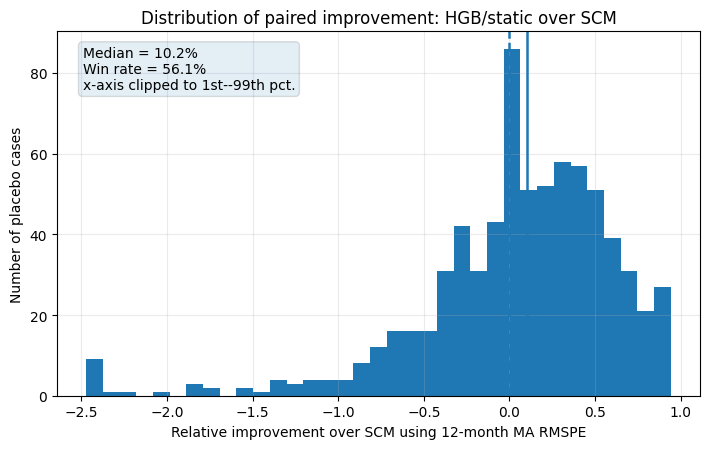

Saved: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\figures\dnsc_best_ml_relative_improvement_hist.png


In [77]:
# Upgrade Cell D: 12-month moving-average evaluation and final model ranking
#
# Main report metric:
#   12-month moving-average RMSPE + 12-month moving-average win rate vs SCM.
#
# This cell does NOT retrain any model.
# It only re-evaluates existing monthly predictions from placebo_pred_df.
#
# Important fix:
#   phase_dynamic_early and phase_dynamic_late are recombined into phase_dynamic.
#   We only evaluate complete 48-month post-period forecasts.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SCM_BASELINE = ("scm_nnls", "static")

FINAL_METHOD = "hist_gradient_boosting"
FINAL_VARIANT = "static"

MA_WINDOW = 12
SPLIT = "test"

print("Final report model:", FINAL_METHOD, FINAL_VARIANT)
print("Main metric: 12-month moving-average RMSPE")


# ---------------------------------------------------------------------
# 0. Load monthly predictions if not already in memory
# ---------------------------------------------------------------------

if "placebo_pred_df" not in globals() or placebo_pred_df is None or placebo_pred_df.empty:
    pred_path_candidates = [
        OUTPUT_DIR / "dnsc_placebo_predictions_full.csv",
        OUTPUT_DIR / "placebo_predictions_full.csv",
        OUTPUT_DIR / "dnsc_placebo_predictions.csv",
    ]

    loaded = False
    for p in pred_path_candidates:
        if p.exists():
            print("Loading monthly predictions from:", p)
            placebo_pred_df = pd.read_csv(p)
            loaded = True
            break

    if not loaded:
        raise ValueError(
            "placebo_pred_df is missing and no saved prediction CSV was found. "
            "Do NOT rerun models unless necessary; first check OUTPUT_DIR for the saved prediction file."
        )


required_pred_cols = [
    "place_id", "pseudo_date", "split", "method", "variant",
    "date", "y_true", "y_pred"
]
missing_cols = [c for c in required_pred_cols if c not in placebo_pred_df.columns]
if missing_cols:
    raise ValueError(f"placebo_pred_df is missing required columns: {missing_cols}")


# ---------------------------------------------------------------------
# 1. Helper functions
# ---------------------------------------------------------------------

def normalize_variant_for_eval(variant):
    """
    Recombine phase-dynamic early/late prediction records into one phase_dynamic variant.

    Some prediction tables store phase-dynamic forecasts as:
      phase_dynamic_early
      phase_dynamic_late

    These are parts of one 48-month forecast and should not be evaluated separately.
    """
    variant = str(variant)

    if variant in ["phase_dynamic_early", "phase_dynamic_late"]:
        return "phase_dynamic"

    return variant


def compute_raw_rmspe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true) == 0:
        return np.nan

    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def compute_raw_mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true) == 0:
        return np.nan

    return float(np.mean(np.abs(y_true - y_pred)))


def compute_ma_rmspe(y_true, y_pred, window=12, min_periods=1):
    """
    RMSPE after applying moving average to both observed and predicted series.
    """
    y_true = pd.Series(np.asarray(y_true, dtype=float))
    y_pred = pd.Series(np.asarray(y_pred, dtype=float))

    if len(y_true) == 0:
        return np.nan

    y_true_ma = y_true.rolling(window=window, min_periods=min_periods).mean()
    y_pred_ma = y_pred.rolling(window=window, min_periods=min_periods).mean()

    valid = y_true_ma.notna() & y_pred_ma.notna()

    if valid.sum() == 0:
        return np.nan

    return float(np.sqrt(np.mean((y_true_ma[valid] - y_pred_ma[valid]) ** 2)))


# ---------------------------------------------------------------------
# 2. Build case-level MA12 metrics from monthly predictions
# ---------------------------------------------------------------------

def compute_ma12_case_metrics_from_predictions(pred_df, window=12):
    tmp = pred_df.copy()

    tmp["place_id"] = tmp["place_id"].astype(str).map(clean_place_id)
    tmp["pseudo_date"] = pd.to_datetime(tmp["pseudo_date"]).dt.to_period("M").dt.to_timestamp()
    tmp["date"] = pd.to_datetime(tmp["date"]).dt.to_period("M").dt.to_timestamp()
    tmp["method"] = tmp["method"].astype(str)
    tmp["variant"] = tmp["variant"].astype(str).map(normalize_variant_for_eval)

    tmp["y_true"] = pd.to_numeric(tmp["y_true"], errors="coerce")
    tmp["y_pred"] = pd.to_numeric(tmp["y_pred"], errors="coerce")

    tmp = tmp.dropna(
        subset=["place_id", "pseudo_date", "date", "split", "method", "variant", "y_true", "y_pred"]
    ).copy()

    tmp = tmp.sort_values(
        ["place_id", "pseudo_date", "split", "method", "variant", "date"]
    )

    group_cols = ["place_id", "pseudo_date", "split", "method", "variant"]
    rows = []

    for keys, g in tmp.groupby(group_cols, sort=False):
        place_id, pseudo_date, split, method, variant = keys

        g = g.sort_values("date").copy()

        # After recombining phase_dynamic early/late, duplicate dates should not occur.
        # If duplicates exist, average them defensively.
        g = (
            g.groupby("date", as_index=False)
            .agg(
                y_true=("y_true", "mean"),
                y_pred=("y_pred", "mean"),
            )
            .sort_values("date")
        )

        n_months = len(g)

        # Only evaluate complete post-period forecasts.
        # This prevents phase_dynamic_early or other partial records from entering the ranking.
        if "CFG" in globals() and hasattr(CFG, "POST_MONTHS"):
            expected_months = int(CFG.POST_MONTHS)
        else:
            expected_months = 48

        if n_months != expected_months:
            continue

        y_true = g["y_true"].to_numpy(dtype=float)
        y_pred = g["y_pred"].to_numpy(dtype=float)

        rows.append({
            "place_id": place_id,
            "pseudo_date": pseudo_date,
            "split": split,
            "method": method,
            "variant": variant,
            "n_months": n_months,
            "rmspe_post": compute_raw_rmspe(y_true, y_pred),
            "ma12_rmspe_post": compute_ma_rmspe(y_true, y_pred, window=window, min_periods=1),
            "mae_post": compute_raw_mae(y_true, y_pred),
            "bias_post": float(np.mean(y_pred - y_true)) if len(y_true) else np.nan,
        })

    out = pd.DataFrame(rows)

    if out.empty:
        raise ValueError(
            "No complete 48-month forecasts were found after recombining phase_dynamic variants. "
            "Check placebo_pred_df variant names and CFG.POST_MONTHS."
        )

    return out


ma12_case_metrics = compute_ma12_case_metrics_from_predictions(
    placebo_pred_df,
    window=MA_WINDOW,
)

ma12_case_metrics.to_csv(
    OUTPUT_DIR / "dnsc_ma12_case_metrics.csv",
    index=False,
)

print("MA12 case metric rows:", ma12_case_metrics.shape)
print("Variants after normalization:")
display(
    ma12_case_metrics[["method", "variant"]]
    .drop_duplicates()
    .sort_values(["method", "variant"])
    .reset_index(drop=True)
)

display(ma12_case_metrics.head())


# ---------------------------------------------------------------------
# 3. Summarize absolute MA12 performance
# ---------------------------------------------------------------------

def summarize_ma12_results(df, split=None):
    tmp = df.copy()

    if split is not None:
        tmp = tmp[tmp["split"] == split].copy()

    if tmp.empty:
        return pd.DataFrame()

    out = (
        tmp.groupby(["method", "variant"])
        .agg(
            n=("place_id", "nunique"),
            n_cases=("place_id", "size"),
            median_ma12_rmspe_post=("ma12_rmspe_post", "median"),
            mean_ma12_rmspe_post=("ma12_rmspe_post", "mean"),
            median_monthly_rmspe_post=("rmspe_post", "median"),
            median_mae_post=("mae_post", "median"),
            median_bias_post=("bias_post", "median"),
        )
        .reset_index()
        .sort_values(["median_ma12_rmspe_post", "median_monthly_rmspe_post"])
        .reset_index(drop=True)
    )

    return out


ma12_test_summary = summarize_ma12_results(ma12_case_metrics, split="test")
ma12_valid_summary = summarize_ma12_results(ma12_case_metrics, split="valid")

ma12_test_summary.to_csv(
    OUTPUT_DIR / "dnsc_ma12_test_summary.csv",
    index=False,
)

ma12_valid_summary.to_csv(
    OUTPUT_DIR / "dnsc_ma12_validation_summary.csv",
    index=False,
)

print("\nMA12 TEST summary:")
display(ma12_test_summary.head(40))


# ---------------------------------------------------------------------
# 4. Paired MA12 comparison vs SCM
# ---------------------------------------------------------------------

def compute_ma12_paired_vs_scm(
    df,
    split="test",
    baseline=SCM_BASELINE,
    exclude_baseline=True,
):
    tmp = df.copy()

    if split is not None:
        tmp = tmp[tmp["split"] == split].copy()

    if tmp.empty:
        return pd.DataFrame()

    key_cols = ["place_id", "pseudo_date"]
    base_method, base_variant = baseline

    base = tmp[
        (tmp["method"] == base_method) &
        (tmp["variant"] == base_variant)
    ][key_cols + ["ma12_rmspe_post", "rmspe_post"]].rename(
        columns={
            "ma12_rmspe_post": "scm_ma12_rmspe_post",
            "rmspe_post": "scm_monthly_rmspe_post",
        }
    )

    if base.empty:
        raise ValueError("SCM/static baseline rows are missing from MA12 metrics.")

    rows = []

    for (method, variant), g in tmp.groupby(["method", "variant"]):
        if exclude_baseline and (method, variant) == baseline:
            continue

        comp = g[key_cols + ["ma12_rmspe_post", "rmspe_post"]].rename(
            columns={
                "ma12_rmspe_post": "method_ma12_rmspe_post",
                "rmspe_post": "method_monthly_rmspe_post",
            }
        )

        paired = base.merge(comp, on=key_cols, how="inner")

        if paired.empty:
            continue

        rel = (
            paired["scm_ma12_rmspe_post"] -
            paired["method_ma12_rmspe_post"]
        ) / paired["scm_ma12_rmspe_post"].replace(0, np.nan)

        monthly_rel = (
            paired["scm_monthly_rmspe_post"] -
            paired["method_monthly_rmspe_post"]
        ) / paired["scm_monthly_rmspe_post"].replace(0, np.nan)

        rows.append({
            "method": method,
            "variant": variant,
            "n_paired": len(paired),
            "median_scm_ma12_rmspe_post": paired["scm_ma12_rmspe_post"].median(),
            "median_method_ma12_rmspe_post": paired["method_ma12_rmspe_post"].median(),
            "median_relative_improvement_vs_scm_ma12": rel.replace([np.inf, -np.inf], np.nan).median(),
            "mean_relative_improvement_vs_scm_ma12": rel.replace([np.inf, -np.inf], np.nan).mean(),
            "win_rate_vs_scm_ma12": (
                paired["method_ma12_rmspe_post"] <
                paired["scm_ma12_rmspe_post"]
            ).mean(),
            "median_scm_monthly_rmspe_post": paired["scm_monthly_rmspe_post"].median(),
            "median_method_monthly_rmspe_post": paired["method_monthly_rmspe_post"].median(),
            "median_relative_improvement_vs_scm_monthly": monthly_rel.replace([np.inf, -np.inf], np.nan).median(),
            "win_rate_vs_scm_monthly": (
                paired["method_monthly_rmspe_post"] <
                paired["scm_monthly_rmspe_post"]
            ).mean(),
        })

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    return out.sort_values(
        ["median_method_ma12_rmspe_post", "win_rate_vs_scm_ma12"],
        ascending=[True, False],
    ).reset_index(drop=True)


ma12_paired_test = compute_ma12_paired_vs_scm(
    ma12_case_metrics,
    split="test",
    baseline=SCM_BASELINE,
    exclude_baseline=True,
)

ma12_paired_valid = compute_ma12_paired_vs_scm(
    ma12_case_metrics,
    split="valid",
    baseline=SCM_BASELINE,
    exclude_baseline=True,
)

ma12_paired_test.to_csv(
    OUTPUT_DIR / "dnsc_ma12_all_methods_paired_vs_scm_test.csv",
    index=False,
)

ma12_paired_valid.to_csv(
    OUTPUT_DIR / "dnsc_ma12_all_methods_paired_vs_scm_validation.csv",
    index=False,
)

print("\nMA12 paired TEST vs SCM:")
display(ma12_paired_test.head(40))


# ---------------------------------------------------------------------
# 5. Balanced ranking using MA12 RMSPE rank and MA12 win-rate rank
# ---------------------------------------------------------------------

def build_ma12_balanced_ranking(summary_df, paired_df, baseline=SCM_BASELINE):
    if summary_df.empty:
        return pd.DataFrame()

    out = summary_df.copy()

    paired_keep_cols = [
        "method",
        "variant",
        "n_paired",
        "median_relative_improvement_vs_scm_ma12",
        "mean_relative_improvement_vs_scm_ma12",
        "win_rate_vs_scm_ma12",
        "median_scm_ma12_rmspe_post",
        "median_method_ma12_rmspe_post",
        "median_relative_improvement_vs_scm_monthly",
        "win_rate_vs_scm_monthly",
    ]

    if paired_df is not None and not paired_df.empty:
        paired_keep = paired_df[[c for c in paired_keep_cols if c in paired_df.columns]].copy()
        out = out.merge(paired_keep, on=["method", "variant"], how="left")
    else:
        out["n_paired"] = np.nan
        out["median_relative_improvement_vs_scm_ma12"] = np.nan
        out["mean_relative_improvement_vs_scm_ma12"] = np.nan
        out["win_rate_vs_scm_ma12"] = np.nan
        out["median_scm_ma12_rmspe_post"] = np.nan
        out["median_method_ma12_rmspe_post"] = np.nan

    base_method, base_variant = baseline
    is_scm = (out["method"] == base_method) & (out["variant"] == base_variant)

    # SCM is kept for reference but not ranked because win rate vs itself is undefined.
    rankable = ~is_scm & out["win_rate_vs_scm_ma12"].notna()

    out["ma12_rmspe_rank"] = np.nan
    out["ma12_win_rank"] = np.nan
    out["ma12_balanced_score"] = np.nan

    out.loc[rankable, "ma12_rmspe_rank"] = (
        out.loc[rankable, "median_ma12_rmspe_post"]
        .rank(ascending=True, method="min")
    )

    out.loc[rankable, "ma12_win_rank"] = (
        out.loc[rankable, "win_rate_vs_scm_ma12"]
        .rank(ascending=False, method="min")
    )

    out.loc[rankable, "ma12_balanced_score"] = (
        0.5 * out.loc[rankable, "ma12_rmspe_rank"] +
        0.5 * out.loc[rankable, "ma12_win_rank"]
    )

    out = out.sort_values(
        [
            "ma12_balanced_score",
            "median_ma12_rmspe_post",
            "win_rate_vs_scm_ma12",
        ],
        ascending=[True, True, False],
    ).reset_index(drop=True)

    out["balanced_rank"] = np.nan
    ranked_idx = out["ma12_balanced_score"].notna()
    out.loc[ranked_idx, "balanced_rank"] = np.arange(1, ranked_idx.sum() + 1)

    ordered_cols = [
        "balanced_rank",
        "method",
        "variant",
        "n",
        "n_cases",
        "n_paired",
        "median_ma12_rmspe_post",
        "win_rate_vs_scm_ma12",
        "ma12_rmspe_rank",
        "ma12_win_rank",
        "ma12_balanced_score",
        "median_relative_improvement_vs_scm_ma12",
        "mean_relative_improvement_vs_scm_ma12",
        "median_monthly_rmspe_post",
        "median_relative_improvement_vs_scm_monthly",
        "win_rate_vs_scm_monthly",
        "median_scm_ma12_rmspe_post",
        "median_method_ma12_rmspe_post",
    ]

    existing_cols = [c for c in ordered_cols if c in out.columns]

    return out[existing_cols]


ma12_balanced_test = build_ma12_balanced_ranking(
    ma12_test_summary,
    ma12_paired_test,
    baseline=SCM_BASELINE,
)

ma12_balanced_valid = build_ma12_balanced_ranking(
    ma12_valid_summary,
    ma12_paired_valid,
    baseline=SCM_BASELINE,
)

ma12_balanced_test.to_csv(
    OUTPUT_DIR / "report_ready_ma12_balanced_ranking_test.csv",
    index=False,
)

ma12_balanced_valid.to_csv(
    OUTPUT_DIR / "report_ready_ma12_balanced_ranking_validation.csv",
    index=False,
)

print("\nMA12 balanced TEST ranking:")
display(ma12_balanced_test.head(50))

print("\nMA12 balanced VALIDATION ranking:")
display(ma12_balanced_valid.head(50))


# ---------------------------------------------------------------------
# 6. Selected model summary: HGB/static
# ---------------------------------------------------------------------

selected_ma12 = ma12_balanced_test[
    (ma12_balanced_test["method"] == FINAL_METHOD) &
    (ma12_balanced_test["variant"] == FINAL_VARIANT)
].copy()

if selected_ma12.empty:
    raise ValueError("HGB/static not found in MA12 balanced test ranking.")

selected_ma12.to_csv(
    OUTPUT_DIR / "report_ready_ma12_selected_model_summary.csv",
    index=False,
)

print("\nSelected HGB/static MA12 summary:")
display(selected_ma12)


# ---------------------------------------------------------------------
# 7. Paired case table for HGB/static vs SCM under MA12 metric
# ---------------------------------------------------------------------

def paired_ma12_case_table(
    df,
    ml_method,
    ml_variant,
    base_method="scm_nnls",
    base_variant="static",
    split="test",
):
    tmp = df[df["split"] == split].copy()
    key_cols = ["place_id", "pseudo_date"]

    base = tmp[
        (tmp["method"] == base_method) &
        (tmp["variant"] == base_variant)
    ][key_cols + ["ma12_rmspe_post", "rmspe_post"]].rename(
        columns={
            "ma12_rmspe_post": "base_ma12_rmspe_post",
            "rmspe_post": "base_monthly_rmspe_post",
        }
    )

    ml = tmp[
        (tmp["method"] == ml_method) &
        (tmp["variant"] == ml_variant)
    ][key_cols + ["ma12_rmspe_post", "rmspe_post"]].rename(
        columns={
            "ma12_rmspe_post": "ml_ma12_rmspe_post",
            "rmspe_post": "ml_monthly_rmspe_post",
        }
    )

    paired = base.merge(ml, on=key_cols, how="inner")

    if paired.empty:
        return paired

    paired["relative_improvement_ma12"] = (
        paired["base_ma12_rmspe_post"] -
        paired["ml_ma12_rmspe_post"]
    ) / paired["base_ma12_rmspe_post"].replace(0, np.nan)

    paired["ml_wins_ma12"] = (
        paired["ml_ma12_rmspe_post"] <
        paired["base_ma12_rmspe_post"]
    )

    paired["relative_improvement_monthly"] = (
        paired["base_monthly_rmspe_post"] -
        paired["ml_monthly_rmspe_post"]
    ) / paired["base_monthly_rmspe_post"].replace(0, np.nan)

    paired["ml_wins_monthly"] = (
        paired["ml_monthly_rmspe_post"] <
        paired["base_monthly_rmspe_post"]
    )

    return paired


paired_test = paired_ma12_case_table(
    ma12_case_metrics,
    FINAL_METHOD,
    FINAL_VARIANT,
    split="test",
)

if paired_test.empty:
    raise ValueError("No paired HGB/static vs SCM test cases found under MA12 metrics.")

paired_test.to_csv(
    OUTPUT_DIR / "report_hgb_static_ma12_paired_vs_scm_test.csv",
    index=False,
)

# Keep this filename for downstream compatibility.
paired_test.to_csv(
    OUTPUT_DIR / "dnsc_test_scm_vs_best_ml_paired_improvement.csv",
    index=False,
)

n_paired = len(paired_test)
median_improvement_ma12 = paired_test["relative_improvement_ma12"].replace([np.inf, -np.inf], np.nan).median()
win_rate_ma12 = paired_test["ml_wins_ma12"].mean()
median_ml_ma12 = paired_test["ml_ma12_rmspe_post"].median()
median_scm_ma12 = paired_test["base_ma12_rmspe_post"].median()
aggregate_reduction_ma12 = (median_scm_ma12 - median_ml_ma12) / median_scm_ma12

median_improvement_monthly = paired_test["relative_improvement_monthly"].replace([np.inf, -np.inf], np.nan).median()
win_rate_monthly = paired_test["ml_wins_monthly"].mean()
median_ml_monthly = paired_test["ml_monthly_rmspe_post"].median()
median_scm_monthly = paired_test["base_monthly_rmspe_post"].median()

selected_model_summary = pd.DataFrame([{
    "selected_method": FINAL_METHOD,
    "selected_variant": FINAL_VARIANT,
    "paired_test_cases": n_paired,

    "test_median_scm_ma12_rmspe": median_scm_ma12,
    "test_median_ml_ma12_rmspe": median_ml_ma12,
    "aggregate_reduction_vs_scm_ma12": aggregate_reduction_ma12,
    "test_median_relative_improvement_vs_scm_ma12": median_improvement_ma12,
    "test_win_rate_vs_scm_ma12": win_rate_ma12,

    "test_median_scm_monthly_rmspe": median_scm_monthly,
    "test_median_ml_monthly_rmspe": median_ml_monthly,
    "test_median_relative_improvement_vs_scm_monthly": median_improvement_monthly,
    "test_win_rate_vs_scm_monthly": win_rate_monthly,
}])

selected_model_summary.to_csv(
    OUTPUT_DIR / "report_ready_selected_model_summary.csv",
    index=False,
)

print("\nFinal report MA12 paired performance:")
print("Paired test cases:", n_paired)
print("SCM median MA12 RMSPE:", median_scm_ma12)
print("HGB/static median MA12 RMSPE:", median_ml_ma12)
print("Aggregate reduction vs SCM, MA12:", aggregate_reduction_ma12)
print("Paired median improvement vs SCM, MA12:", median_improvement_ma12)
print("Win rate vs SCM, MA12:", win_rate_ma12)

display(selected_model_summary)


# ---------------------------------------------------------------------
# 8. Generate report histogram: MA12 relative improvement
# ---------------------------------------------------------------------

improvement = (
    paired_test["relative_improvement_ma12"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

x_min = improvement.quantile(0.01)
x_max = improvement.quantile(0.99)

fig, ax = plt.subplots(figsize=(7.2, 4.6))

ax.hist(
    improvement.clip(lower=x_min, upper=x_max),
    bins=35,
)

ax.axvline(0, linestyle="--", linewidth=1.8, label="No improvement")
ax.axvline(median_improvement_ma12, linestyle="-", linewidth=1.8, label="Median improvement")

ax.set_xlabel("Relative improvement over SCM using 12-month MA RMSPE")
ax.set_ylabel("Number of placebo cases")
ax.set_title("Distribution of paired improvement: HGB/static over SCM")

ax.text(
    0.04,
    0.96,
    f"Median = {100 * median_improvement_ma12:.1f}%\n"
    f"Win rate = {100 * win_rate_ma12:.1f}%\n"
    f"x-axis clipped to 1st--99th pct.",
    transform=ax.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.12),
)

ax.grid(True, alpha=0.25)
plt.tight_layout()

hist_path = FIGURES_DIR / "dnsc_best_ml_relative_improvement_hist.png"
fig.savefig(hist_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", hist_path)

Available paired cases with monthly predictions: 727
Selected representative HGB/static MA12 improvement candidates:


,candidate_id,place_id,pseudo_date,scm_ma12_rmspe,hgb_static_ma12_rmspe,relative_improvement_ma12,hgb_wins_ma12
0,1,09277000,2018-01-01,2.743601,0.003394,0.998763,True
1,2,33333000,2018-01-01,3.107404,0.007537,0.997575,True
2,3,06504500,2018-01-01,1.873246,0.035540,0.981027,True
3,4,49059000,2014-01-01,33.900144,0.697962,0.979411,True
4,5,55941600,2018-01-01,0.664281,0.031728,0.952236,True
5,6,16629000,2020-01-01,39.698443,1.958590,0.950663,True
6,7,36140000,2020-01-01,14.473838,0.730514,0.949529,True
7,8,53301000,2020-01-01,16.785868,0.871863,0.948060,True
8,9,41517000,2018-01-01,28.254476,2.078809,0.926425,True
9,10,48473000,2016-01-01,7.511994,0.674195,0.910251,True


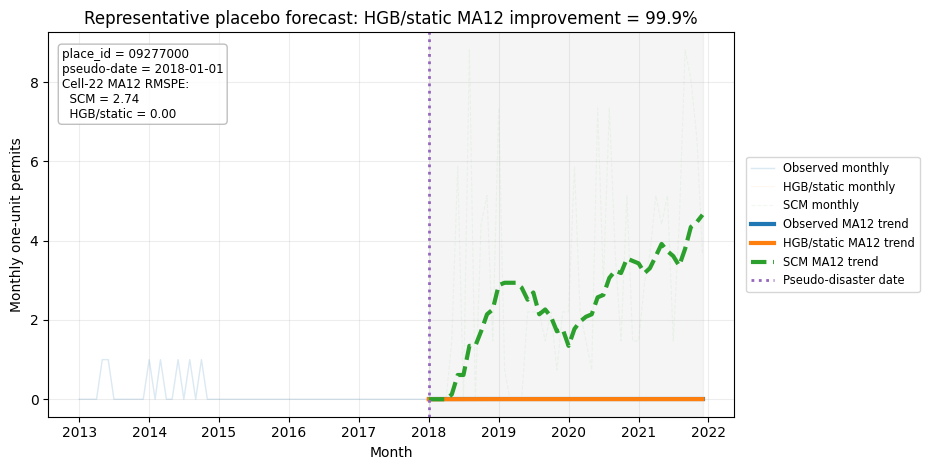

Saved: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\figures\placebo_forecast_hgb_static_ma12_candidate_01.png


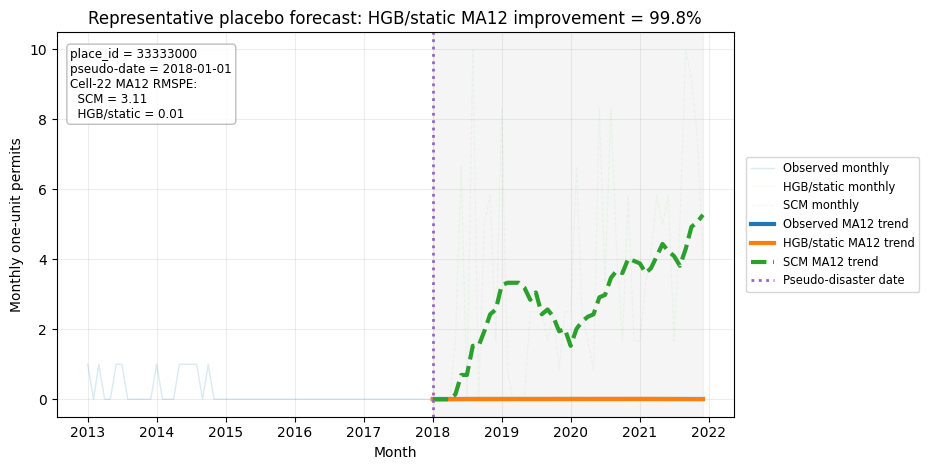

Saved: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\figures\placebo_forecast_hgb_static_ma12_candidate_02.png


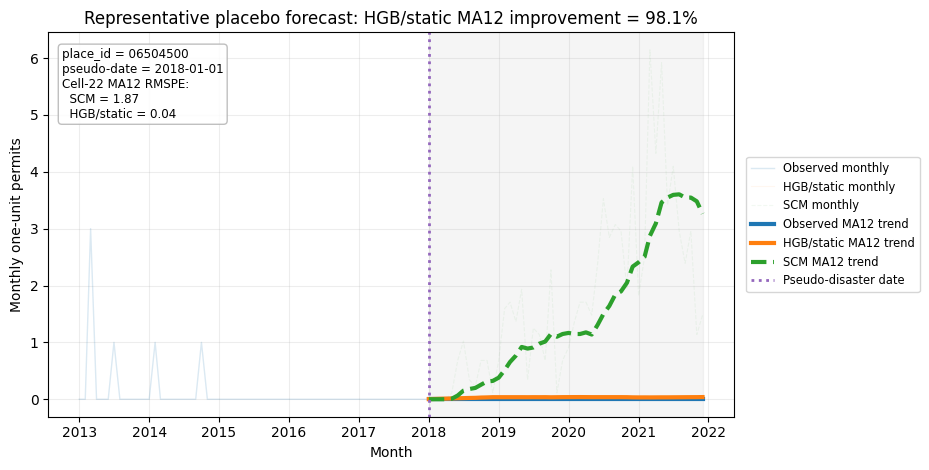

Saved: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\figures\placebo_forecast_hgb_static_ma12_candidate_03.png


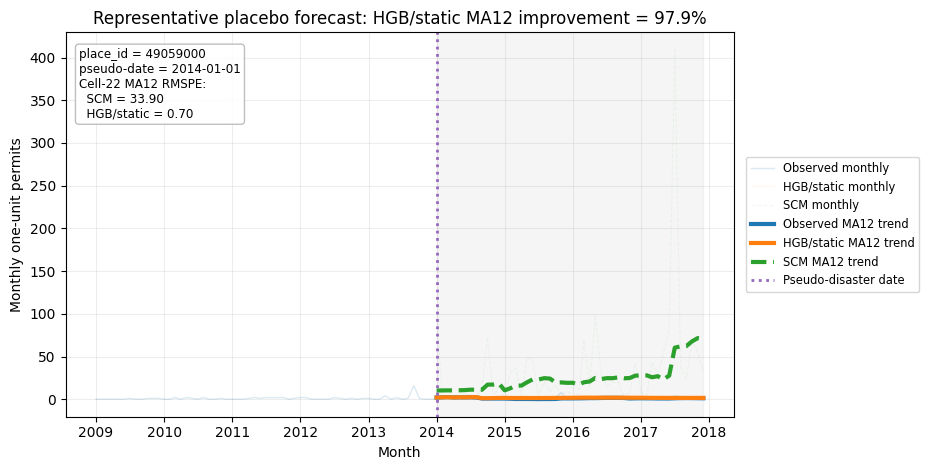

Saved: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\figures\placebo_forecast_hgb_static_ma12_candidate_04.png


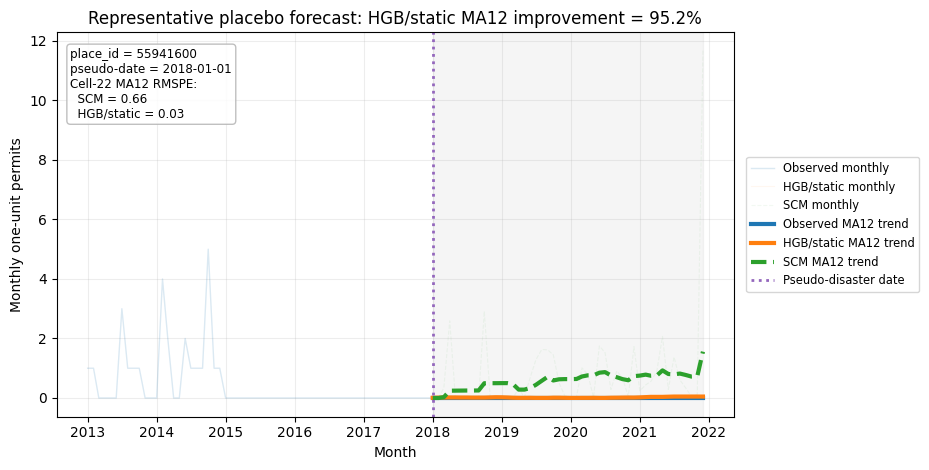

Saved: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\figures\placebo_forecast_hgb_static_ma12_candidate_05.png


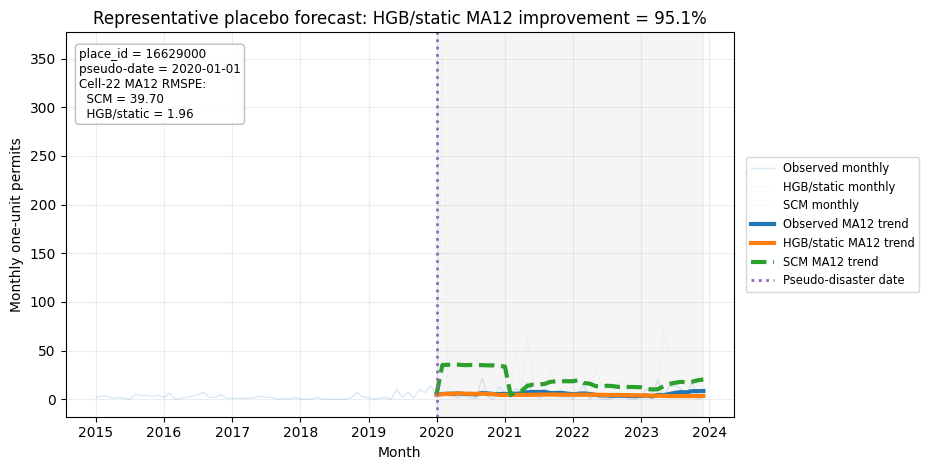

Saved: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\figures\placebo_forecast_hgb_static_ma12_candidate_06.png


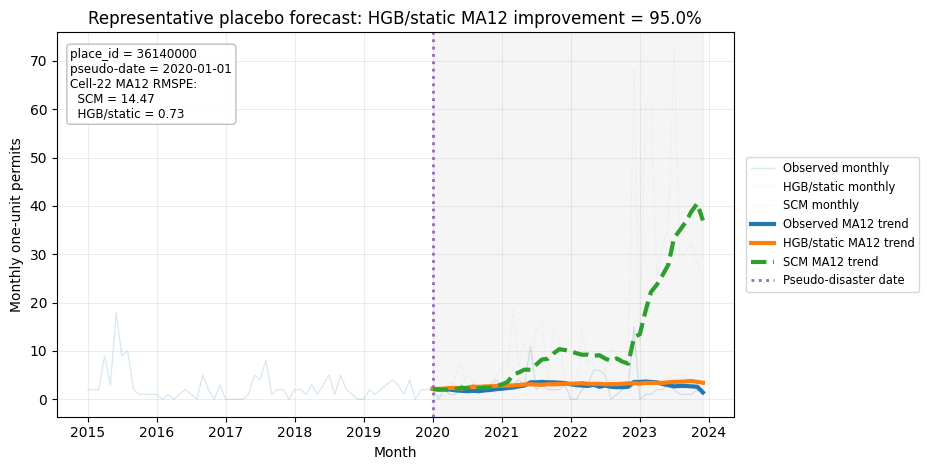

Saved: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\figures\placebo_forecast_hgb_static_ma12_candidate_07.png


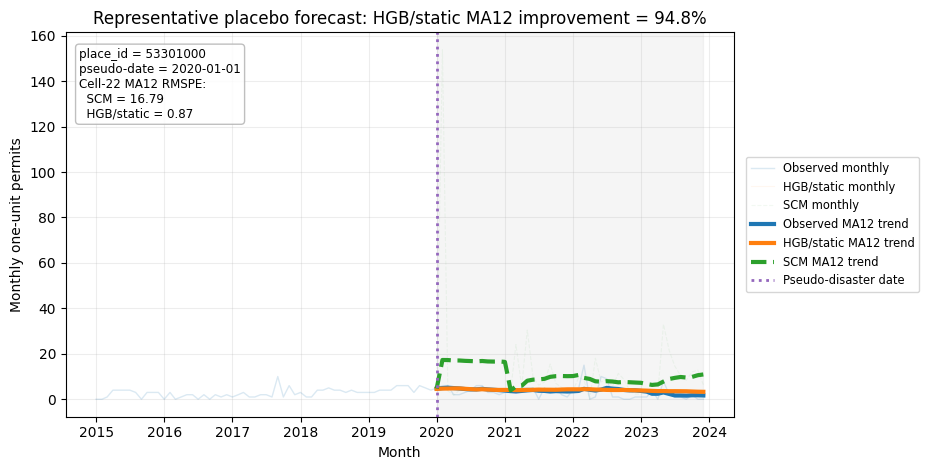

Saved: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\figures\placebo_forecast_hgb_static_ma12_candidate_08.png


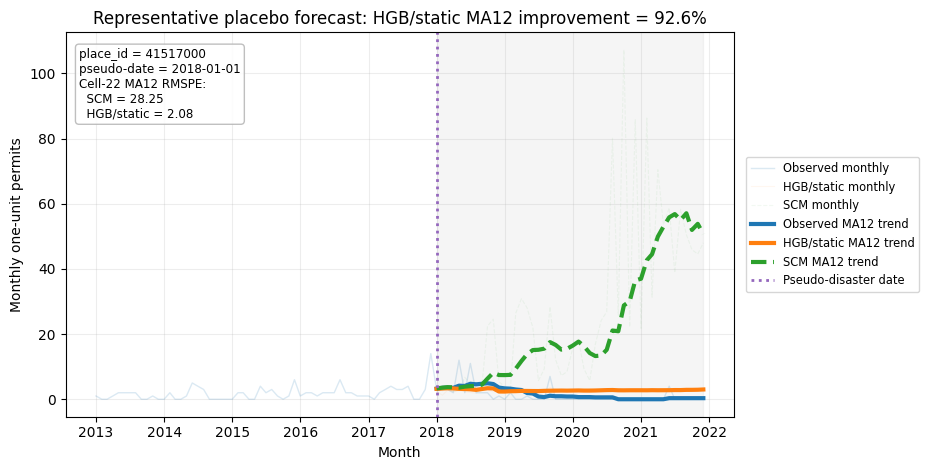

Saved: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\figures\placebo_forecast_hgb_static_ma12_candidate_09.png


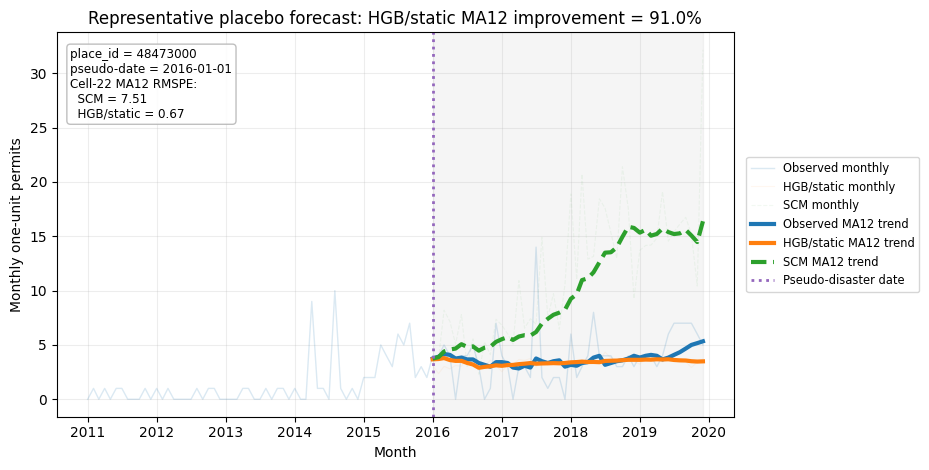

Saved: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\figures\placebo_forecast_hgb_static_ma12_candidate_10.png


In [95]:
# Cell 23: Generate representative HGB/static MA12 placebo forecast candidates
#          consistent with Cell 22 MA12 evaluation
#
# This cell uses:
#   paired_test from Cell 22
#   placebo_pred_df monthly predictions
#
# It selects multiple strong HGB/static improvement cases and saves:
#   figures/placebo_forecast_hgb_static_ma12_candidate_01.png
#   figures/placebo_forecast_hgb_static_ma12_candidate_02.png
#   ...
#   outputs/placebo_forecast_hgb_static_ma12_candidates.csv
#
# Notes:
#   - Reported MA12 RMSPE values are taken directly from Cell 22.
#   - The displayed MA12 trend is stitched for visualization:
#       pre-period = observed history
#       post-period = model forecast
#   - Raw monthly lines are shown faintly; MA12 trend lines are emphasized.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FINAL_METHOD = "hist_gradient_boosting"
FINAL_VARIANT = "static"

BASE_METHOD = "scm_nnls"
BASE_VARIANT = "static"

SPLIT = "test"

MA_WINDOW = 12
MA_MIN_PERIODS = 1

TOP_K_CANDIDATES = 10
MIN_IMPROVEMENT = 0.10


# ---------------------------------------------------------------------
# 0. Validate required dataframes
# ---------------------------------------------------------------------

if "paired_test" not in globals() or paired_test is None or paired_test.empty:
    raise ValueError("paired_test is missing or empty. Run Cell 22 first.")

if "placebo_pred_df" not in globals() or placebo_pred_df is None or placebo_pred_df.empty:
    raise ValueError(
        "placebo_pred_df is missing or empty. "
        "Set CFG.SAVE_PREDICTIONS = True and rerun Cell 13."
    )

required_pred_cols = [
    "place_id",
    "pseudo_date",
    "split",
    "method",
    "variant",
    "date",
    "y_true",
    "y_pred",
]

missing_pred_cols = [c for c in required_pred_cols if c not in placebo_pred_df.columns]
if missing_pred_cols:
    raise ValueError(
        f"placebo_pred_df is missing required columns: {missing_pred_cols}"
    )

required_pair_cols = [
    "place_id",
    "pseudo_date",
    "base_ma12_rmspe_post",
    "ml_ma12_rmspe_post",
    "relative_improvement_ma12",
    "ml_wins_ma12",
]

missing_pair_cols = [c for c in required_pair_cols if c not in paired_test.columns]
if missing_pair_cols:
    raise ValueError(
        f"paired_test is missing required Cell-22 columns: {missing_pair_cols}. "
        "Run the MA12 Cell 22 first."
    )


# ---------------------------------------------------------------------
# 1. Prepare clean paired table and prediction table
# ---------------------------------------------------------------------

def _normalize_variant_for_plot(variant):
    variant = str(variant)
    if variant in ["phase_dynamic_early", "phase_dynamic_late"]:
        return "phase_dynamic"
    return variant


paired_clean = paired_test.copy()

paired_clean["place_id"] = paired_clean["place_id"].astype(str).map(clean_place_id)

paired_clean["pseudo_date"] = (
    pd.to_datetime(paired_clean["pseudo_date"])
    .dt.to_period("M")
    .dt.to_timestamp()
)

paired_clean["base_ma12_rmspe_post"] = pd.to_numeric(
    paired_clean["base_ma12_rmspe_post"],
    errors="coerce",
)

paired_clean["ml_ma12_rmspe_post"] = pd.to_numeric(
    paired_clean["ml_ma12_rmspe_post"],
    errors="coerce",
)

paired_clean["relative_improvement_ma12"] = pd.to_numeric(
    paired_clean["relative_improvement_ma12"],
    errors="coerce",
)

paired_clean = paired_clean.dropna(
    subset=[
        "base_ma12_rmspe_post",
        "ml_ma12_rmspe_post",
        "relative_improvement_ma12",
    ]
).copy()

pred_clean = placebo_pred_df.copy()

pred_clean["place_id"] = pred_clean["place_id"].astype(str).map(clean_place_id)

pred_clean["pseudo_date"] = (
    pd.to_datetime(pred_clean["pseudo_date"])
    .dt.to_period("M")
    .dt.to_timestamp()
)

pred_clean["date"] = (
    pd.to_datetime(pred_clean["date"])
    .dt.to_period("M")
    .dt.to_timestamp()
)

pred_clean["method"] = pred_clean["method"].astype(str)
pred_clean["variant"] = pred_clean["variant"].astype(str).map(_normalize_variant_for_plot)

pred_clean["y_true"] = pd.to_numeric(pred_clean["y_true"], errors="coerce")
pred_clean["y_pred"] = pd.to_numeric(pred_clean["y_pred"], errors="coerce")

pred_clean = pred_clean[pred_clean["split"] == SPLIT].copy()

available_hgb = pred_clean[
    (pred_clean["method"] == FINAL_METHOD) &
    (pred_clean["variant"] == FINAL_VARIANT)
][["place_id", "pseudo_date"]].drop_duplicates()

available_scm = pred_clean[
    (pred_clean["method"] == BASE_METHOD) &
    (pred_clean["variant"] == BASE_VARIANT)
][["place_id", "pseudo_date"]].drop_duplicates()

available_cases = available_hgb.merge(
    available_scm,
    on=["place_id", "pseudo_date"],
    how="inner",
)

paired_available = paired_clean.merge(
    available_cases,
    on=["place_id", "pseudo_date"],
    how="inner",
)

if paired_available.empty:
    raise ValueError(
        "No paired HGB/static vs SCM test cases have both monthly predictions."
    )

print("Available paired cases with monthly predictions:", len(paired_available))


# ---------------------------------------------------------------------
# 2. Select representative HGB/static improvement candidates
# ---------------------------------------------------------------------

candidate_cases = paired_available[
    (paired_available["relative_improvement_ma12"] > MIN_IMPROVEMENT) &
    (paired_available["ml_ma12_rmspe_post"] < paired_available["base_ma12_rmspe_post"])
].copy()

candidate_cases = candidate_cases.sort_values(
    "relative_improvement_ma12",
    ascending=False,
).reset_index(drop=True)

if candidate_cases.empty:
    raise ValueError(
        f"No candidate cases found with relative_improvement_ma12 > {MIN_IMPROVEMENT:.2f}. "
        "Try lowering MIN_IMPROVEMENT."
    )

selected_cases = candidate_cases.head(TOP_K_CANDIDATES).copy()
selected_cases["candidate_id"] = np.arange(1, len(selected_cases) + 1)

example_case_summary = selected_cases[
    [
        "candidate_id",
        "place_id",
        "pseudo_date",
        "base_ma12_rmspe_post",
        "ml_ma12_rmspe_post",
        "relative_improvement_ma12",
        "ml_wins_ma12",
    ]
].rename(
    columns={
        "base_ma12_rmspe_post": "scm_ma12_rmspe",
        "ml_ma12_rmspe_post": "hgb_static_ma12_rmspe",
        "ml_wins_ma12": "hgb_wins_ma12",
    }
)

example_case_summary.to_csv(
    OUTPUT_DIR / "placebo_forecast_hgb_static_ma12_candidates.csv",
    index=False,
)

print("Selected representative HGB/static MA12 improvement candidates:")
display(example_case_summary)


# ---------------------------------------------------------------------
# 3. Plot helper functions
# ---------------------------------------------------------------------

def _complete_prediction_series(pred_df, date_index, value_col="y_pred"):
    s = (
        pred_df[["date", value_col]]
        .dropna()
        .drop_duplicates(subset=["date"], keep="last")
        .set_index("date")[value_col]
        .sort_index()
    )
    return s.reindex(date_index)


def _rolling_ma(s, window=12, min_periods=1):
    return s.rolling(window=window, min_periods=min_periods).mean()


def plot_hgb_static_ma12_candidate(case_row):
    place_id = case_row["place_id"]
    pseudo_date = pd.Timestamp(case_row["pseudo_date"])
    candidate_id = int(case_row["candidate_id"])

    pre_start = pseudo_date - pd.DateOffset(months=CFG.PRE_MONTHS)
    post_end = pseudo_date + pd.DateOffset(months=CFG.POST_MONTHS - 1)

    full_index = pd.date_range(pre_start, post_end, freq="MS")
    post_index = pd.date_range(pseudo_date, post_end, freq="MS")

    y_series = get_place_series(panel, place_id)

    if y_series is None or y_series.empty:
        raise ValueError(
            f"Could not find observed panel series for place_id={place_id}"
        )

    observed_full = make_complete_monthly_series(y_series, pre_start, post_end)
    observed_full = pd.to_numeric(observed_full, errors="coerce").reindex(full_index)

    case_pred = pred_clean[
        (pred_clean["place_id"] == place_id) &
        (pred_clean["pseudo_date"] == pseudo_date)
    ].copy()

    hgb_pred_df = (
        case_pred[
            (case_pred["method"] == FINAL_METHOD) &
            (case_pred["variant"] == FINAL_VARIANT)
        ][["date", "y_pred"]]
        .dropna()
        .sort_values("date")
    )

    scm_pred_df = (
        case_pred[
            (case_pred["method"] == BASE_METHOD) &
            (case_pred["variant"] == BASE_VARIANT)
        ][["date", "y_pred"]]
        .dropna()
        .sort_values("date")
    )

    if hgb_pred_df.empty:
        raise ValueError(
            f"No HGB/static predictions found for place_id={place_id}, "
            f"pseudo_date={pseudo_date.date()}."
        )

    if scm_pred_df.empty:
        raise ValueError(
            f"No SCM predictions found for place_id={place_id}, "
            f"pseudo_date={pseudo_date.date()}."
        )

    hgb_post = _complete_prediction_series(hgb_pred_df, post_index)
    scm_post = _complete_prediction_series(scm_pred_df, post_index)

    hgb_display = observed_full.copy()
    scm_display = observed_full.copy()

    hgb_display.loc[post_index] = hgb_post.values
    scm_display.loc[post_index] = scm_post.values

    observed_ma12_full = _rolling_ma(
        observed_full,
        window=MA_WINDOW,
        min_periods=MA_MIN_PERIODS,
    )

    hgb_ma12_full = _rolling_ma(
        hgb_display,
        window=MA_WINDOW,
        min_periods=MA_MIN_PERIODS,
    )

    scm_ma12_full = _rolling_ma(
        scm_display,
        window=MA_WINDOW,
        min_periods=MA_MIN_PERIODS,
    )

    observed_ma12 = observed_ma12_full.reindex(post_index)
    hgb_ma12 = hgb_ma12_full.reindex(post_index)
    scm_ma12 = scm_ma12_full.reindex(post_index)

    fig, ax = plt.subplots(figsize=(9.4, 4.8))

    ax.axvspan(
        pseudo_date,
        post_end,
        alpha=0.08,
        color="gray",
        zorder=0,
    )

    ax.plot(
        observed_full.index,
        observed_full.values,
        label="Observed monthly",
        linewidth=1.0,
        alpha=0.16,
        color="tab:blue",
    )

    ax.plot(
        hgb_post.index,
        hgb_post.values,
        label="HGB/static monthly",
        linewidth=0.8,
        alpha=0.06,
        color="tab:orange",
    )

    ax.plot(
        scm_post.index,
        scm_post.values,
        label="SCM monthly",
        linewidth=0.8,
        alpha=0.06,
        linestyle="--",
        color="tab:green",
    )

    ax.plot(
        observed_ma12.index,
        observed_ma12.values,
        label="Observed MA12 trend",
        linewidth=3.0,
        color="tab:blue",
    )

    ax.plot(
        hgb_ma12.index,
        hgb_ma12.values,
        label="HGB/static MA12 trend",
        linewidth=3.0,
        color="tab:orange",
    )

    ax.plot(
        scm_ma12.index,
        scm_ma12.values,
        label="SCM MA12 trend",
        linewidth=3.0,
        linestyle="--",
        color="tab:green",
    )

    ax.axvline(
        pseudo_date,
        linestyle=":",
        linewidth=2.0,
        color="tab:purple",
        label="Pseudo-disaster date",
    )

    rel = float(case_row["relative_improvement_ma12"])
    scm_r = float(case_row["base_ma12_rmspe_post"])
    ml_r = float(case_row["ml_ma12_rmspe_post"])

    ax.set_title(
        f"Representative placebo forecast: "
        f"HGB/static MA12 improvement = {100 * rel:.1f}%"
    )

    ax.set_xlabel("Month")
    ax.set_ylabel("Monthly one-unit permits")

    ax.text(
        0.02,
        0.96,
        f"place_id = {place_id}\n"
        f"pseudo-date = {pseudo_date.date()}\n"
        f"Cell-22 MA12 RMSPE:\n"
        f"  SCM = {scm_r:.2f}\n"
        f"  HGB/static = {ml_r:.2f}",
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=8.6,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor="0.7",
            alpha=0.84,
        ),
    )

    ax.grid(True, alpha=0.22)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=True,
        fontsize=8.3,
    )

    plt.tight_layout()

    out = FIGURES_DIR / (
        f"placebo_forecast_hgb_static_ma12_candidate_{candidate_id:02d}.png"
    )

    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out)


# ---------------------------------------------------------------------
# 4. Generate representative candidate figures
# ---------------------------------------------------------------------

for _, row in selected_cases.iterrows():
    plot_hgb_static_ma12_candidate(row)

In [56]:
# Upgrade Cell E: Cross-region and cross-time generalization diagnostics.
#
# This cell does not refit models. It stress-tests the already-run placebo results
# by asking whether the validation-selected method still wins in harder subsets.

placebo_meta_for_stress = placebo_specs[["place_id", "pseudo_date", "split"]].copy()
placebo_meta_for_stress["place_id"] = placebo_meta_for_stress["place_id"].apply(clean_place_id)
placebo_meta_for_stress["pseudo_date"] = pd.to_datetime(placebo_meta_for_stress["pseudo_date"])

place_region = panel.groupby("place_id").agg(
    state_fips=("state_fips", "first"),
    region=("region", "first"),
    avg_permits=("units_1", "mean"),
).reset_index()
place_region["place_id"] = place_region["place_id"].apply(clean_place_id)

stress_df = placebo_plus_df.copy()
stress_df["place_id"] = stress_df["place_id"].apply(clean_place_id)
stress_df["pseudo_date"] = pd.to_datetime(stress_df["pseudo_date"])
stress_df = stress_df.merge(place_region, on="place_id", how="left")
stress_df["pseudo_year"] = stress_df["pseudo_date"].dt.year
nstress_df = stress_df.copy()

def summarize_by_group(df, group_col, methods_to_show):
    tmp = df.copy()
    tmp = tmp[tmp[["method", "variant"]].apply(tuple, axis=1).isin(methods_to_show)].copy()
    if tmp.empty:
        return pd.DataFrame()
    return tmp.groupby([group_col, "method", "variant"]).agg(
        n=("place_id", "nunique"),
        median_post_rmspe=("rmspe_post", "median"),
        median_ratio=("ratio", "median"),
    ).reset_index().sort_values([group_col, "median_post_rmspe"])

methods_to_show = [("scm_nnls", "static"), (best_ml_method, best_ml_variant), ("naive_month_mean", "seasonal"), ("naive_last_year", "seasonal_lag12")]

region_summary = summarize_by_group(stress_df[stress_df["split"] == "test"], "region", methods_to_show)
time_summary = summarize_by_group(stress_df[stress_df["split"] == "test"].assign(
    time_group=lambda x: np.where(x["pseudo_year"] <= 2016, "early_pseudo_dates", "late_pseudo_dates")
), "time_group", methods_to_show)

region_summary.to_csv(OUTPUT_DIR / "dnsc_test_region_stress_summary.csv", index=False)
time_summary.to_csv(OUTPUT_DIR / "dnsc_test_time_stress_summary.csv", index=False)

print("Cross-region stress summary:")
display(region_summary)
print("Cross-time stress summary:")
display(time_summary)


Cross-region stress summary:


,region,method,variant,n,median_post_rmspe,median_ratio
0,Midwest,hist_gradient_boosting,rolling_recent_dynamic,170,3.098669,2.127535
1,Midwest,naive_last_year,seasonal_lag12,170,3.152380,1.040680
2,Midwest,naive_month_mean,seasonal,170,3.204814,1.399565
3,Midwest,scm_nnls,static,170,3.651598,2.102138
4,Northeast,hist_gradient_boosting,rolling_recent_dynamic,106,2.042560,1.869465
5,Northeast,naive_last_year,seasonal_lag12,106,2.150581,0.897843
6,Northeast,naive_month_mean,seasonal,106,2.253146,1.358502
7,Northeast,scm_nnls,static,106,2.654323,2.063434
8,South,hist_gradient_boosting,rolling_recent_dynamic,163,6.516670,2.763209
9,South,naive_last_year,seasonal_lag12,163,6.869316,1.137296


Cross-time stress summary:


,time_group,method,variant,n,median_post_rmspe,median_ratio
0,early_pseudo_dates,hist_gradient_boosting,rolling_recent_dynamic,360,3.642632,2.332555
2,early_pseudo_dates,naive_month_mean,seasonal,360,3.968439,1.473658
1,early_pseudo_dates,naive_last_year,seasonal_lag12,360,3.988262,0.966460
3,early_pseudo_dates,scm_nnls,static,360,4.567639,2.245147
4,late_pseudo_dates,hist_gradient_boosting,rolling_recent_dynamic,293,3.939890,2.484994
5,late_pseudo_dates,naive_last_year,seasonal_lag12,293,4.245095,1.193125
6,late_pseudo_dates,naive_month_mean,seasonal,293,4.389761,1.587338
7,late_pseudo_dates,scm_nnls,static,293,5.052163,2.502107


In [57]:
# Upgrade Cell F: Oracle donor upper-bound experiment.
#
# This deliberately uses post-period information to select donors. It is NOT a usable
# forecasting method. It estimates an upper bound: if donor selection were almost perfect,
# how much could the counterfactual improve?


def select_oracle_donors(target_series, donor_matrix, pre_start, pre_end, pseudo_date, post_end, top_k=50, pre_weight=0.35, post_weight=0.65):
    scores = []
    target_pre = target_series.loc[pre_start:pre_end]
    target_post = target_series.loc[pseudo_date:post_end]
    for col in donor_matrix.columns:
        donor_pre = donor_matrix[col].loc[pre_start:pre_end]
        donor_post = donor_matrix[col].loc[pseudo_date:post_end]
        pre_both = pd.concat([target_pre, donor_pre], axis=1).dropna()
        post_both = pd.concat([target_post, donor_post], axis=1).dropna()
        if len(pre_both) < 12 or len(post_both) < 12:
            continue
        pre_rmse = rmspe(pre_both.iloc[:, 0], pre_both.iloc[:, 1]) / max(pre_both.iloc[:, 0].mean(), 1.0)
        post_rmse = rmspe(post_both.iloc[:, 0], post_both.iloc[:, 1]) / max(post_both.iloc[:, 0].mean(), 1.0)
        pre_corr = pre_both.iloc[:, 0].corr(pre_both.iloc[:, 1])
        post_corr = post_both.iloc[:, 0].corr(post_both.iloc[:, 1])
        score = -pre_weight * pre_rmse - post_weight * post_rmse
        if pd.notna(pre_corr):
            score += 0.1 * pre_corr
        if pd.notna(post_corr):
            score += 0.2 * post_corr
        scores.append({"place_id": col, "oracle_score": score})
    if not scores:
        return []
    return pd.DataFrame(scores).sort_values("oracle_score", ascending=False)["place_id"].head(top_k).tolist()


def run_oracle_upper_bound_one(panel, target_place_id, pseudo_date, split, cfg, model_names, fixed_params_by_model, exclude_places=None):
    target_place_id = clean_place_id(target_place_id)
    pseudo_date = pd.Timestamp(pseudo_date)
    pre_start = pseudo_date - pd.DateOffset(months=cfg.PRE_MONTHS)
    pre_end = pseudo_date - pd.DateOffset(months=1)
    post_end = pseudo_date + pd.DateOffset(months=cfg.POST_MONTHS - 1)
    all_dates = pd.date_range(pre_start - pd.DateOffset(months=cfg.LAG), post_end, freq="MS")
    pre_dates = pd.date_range(pre_start, pre_end, freq="MS")
    post_dates = pd.date_range(pseudo_date, post_end, freq="MS")

    target_raw = get_place_series(panel, target_place_id)
    if target_raw is None or target_raw.empty:
        return []
    target_series = make_complete_monthly_series(target_raw, all_dates.min(), all_dates.max())

    donor_pool = get_donor_pool(panel, target_place_id, pre_start, post_end, cfg, exclude_places=exclude_places)
    if len(donor_pool) < cfg.MIN_DONORS:
        return []
    donor_matrix = build_donor_matrix(panel, donor_pool).reindex(all_dates).fillna(0.0)
    if donor_matrix.empty:
        return []

    oracle_donors = select_oracle_donors(target_series, donor_matrix, pre_start, pre_end, pseudo_date, post_end, cfg.TOP_K_DONORS)
    if len(oracle_donors) < cfg.MIN_DONORS:
        return []

    out = []

    if "scm_nnls" in model_names:
        y_all_pred, y_pre_hat, info = fit_predict_scm_nnls(target_series, donor_matrix, oracle_donors, pre_dates, list(pre_dates) + list(post_dates))
        if len(y_all_pred) == len(pre_dates) + len(post_dates):
            out.append(evaluate_predictions(
                target_place_id, pseudo_date, split, "scm_nnls", "oracle_donor_upper_bound",
                target_series.reindex(pre_dates).fillna(0.0).values, y_all_pred[:len(pre_dates)],
                target_series.reindex(post_dates).fillna(0.0).values, y_all_pred[len(pre_dates):], len(oracle_donors),
                extra={"experiment": "oracle_upper_bound"}
            ))

    for model_name in model_names:
        if model_name == "scm_nnls" or model_name not in MODEL_REGISTRY:
            continue
        X, y, dates = build_lagged_dataset(target_series, donor_matrix, all_dates, oracle_donors, cfg.LAG)
        if X.size == 0:
            continue
        pred, reason = fit_predict_ml(model_name, X, y, dates, pseudo_date, post_end, fixed_params_by_model.get(model_name, {}))
        if pred is None:
            continue
        out.append(evaluate_predictions(
            target_place_id, pseudo_date, split, model_name, "oracle_donor_upper_bound",
            pred["y_pre_true"], pred["y_pre_pred"], pred["y_post_true"], pred["y_post_pred"], len(oracle_donors),
            extra={"experiment": "oracle_upper_bound"}
        ))
    return out

oracle_specs = placebo_specs[placebo_specs["split"].isin(["valid", "test"])].sample(
    min(UPGRADE["N_ORACLE_PLACEBOS"], len(placebo_specs[placebo_specs["split"].isin(["valid", "test"])])),
    random_state=RANDOM_SEED,
).copy()

oracle_rows = []
for i, row in oracle_specs.iterrows():
    print(f"Oracle donor upper bound | place={row['place_id']} | date={pd.Timestamp(row['pseudo_date']).date()}")
    oracle_rows.extend(run_oracle_upper_bound_one(
        panel, row["place_id"], row["pseudo_date"], row["split"], CFG,
        UPGRADE["ORACLE_MODELS"], BEST_PARAMS_BY_MODEL,
        exclude_places=known_disaster_places,
    ))

oracle_df = pd.DataFrame(oracle_rows)
oracle_df.to_csv(OUTPUT_DIR / "dnsc_oracle_donor_upper_bound_results.csv", index=False)

print("Oracle upper-bound shape:", oracle_df.shape)
if not oracle_df.empty:
    display(oracle_df.groupby(["split", "method", "variant"]).agg(
        n=("place_id", "nunique"),
        median_post_rmspe=("rmspe_post", "median"),
        median_ratio=("ratio", "median"),
    ).reset_index().sort_values(["split", "median_post_rmspe"]))


Oracle donor upper bound | place=01394000 | date=2020-01-01
Oracle donor upper bound | place=17826900 | date=2020-01-01
Oracle donor upper bound | place=19014200 | date=2018-01-01
Oracle donor upper bound | place=08619000 | date=2014-01-01
Oracle donor upper bound | place=26472000 | date=2014-01-01
Oracle donor upper bound | place=39322300 | date=2020-01-01
Oracle donor upper bound | place=16405000 | date=2018-01-01
Oracle donor upper bound | place=06041000 | date=2018-01-01
Oracle donor upper bound | place=53339000 | date=2014-01-01
Oracle donor upper bound | place=42015400 | date=2020-01-01
Oracle donor upper bound | place=55296000 | date=2018-01-01
Oracle donor upper bound | place=41077000 | date=2018-01-01
Oracle donor upper bound | place=08245000 | date=2020-01-01
Oracle donor upper bound | place=28403000 | date=2020-01-01
Oracle donor upper bound | place=06250000 | date=2014-01-01
Oracle donor upper bound | place=29647500 | date=2020-01-01
Oracle donor upper bound | place=2818100

,split,method,variant,n,median_post_rmspe,median_ratio
1,test,hist_gradient_boosting,oracle_donor_upper_bound,43,3.948976,1.938371
3,test,scm_nnls,oracle_donor_upper_bound,43,4.229448,1.561077
0,test,extra_trees,oracle_donor_upper_bound,43,5.403643,6.055720
2,test,ridge,oracle_donor_upper_bound,43,6.103278,529.154501
7,valid,scm_nnls,oracle_donor_upper_bound,37,2.703859,1.889087
5,valid,hist_gradient_boosting,oracle_donor_upper_bound,37,2.906871,2.245858
4,valid,extra_trees,oracle_donor_upper_bound,37,2.971484,7.230735
6,valid,ridge,oracle_donor_upper_bound,37,3.737836,631.681133


In [78]:
# Upgrade Cell G: Compact final report-ready MA12 tables.
#
# This cell assumes Cell 22 has already created:
#   ma12_balanced_test
#   ma12_balanced_valid
#   selected_model_summary
#   ma12_case_metrics
#   paired_test

import numpy as np
import pandas as pd

required_objects = [
    "ma12_balanced_test",
    "ma12_balanced_valid",
    "selected_model_summary",
    "ma12_case_metrics",
    "paired_test",
]

missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise ValueError(
        f"Missing objects from Cell 22: {missing_objects}. "
        "Run corrected Cell 22 first."
    )


def add_family_label(method):
    if method in [
        "random_forest",
        "extra_trees",
        "gradient_boosting",
        "hist_gradient_boosting",
        "xgb",
    ]:
        return "tree"
    if method in ["ridge", "lasso", "elasticnet"]:
        return "linear"
    if method in ["naive_pre_mean", "naive_month_mean", "naive_last_year"]:
        return "naive"
    if method == "scm_nnls":
        return "SCM"
    return "non-tree"


def pretty_method_name(method):
    mapping = {
        "hist_gradient_boosting": "HGB",
        "random_forest": "Random Forest",
        "extra_trees": "Extra Trees",
        "gradient_boosting": "Gradient Boosting",
        "xgb": "XGBoost",
        "svr": "SVR",
        "mlp": "MLP",
        "ridge": "Ridge",
        "lasso": "Lasso",
        "elasticnet": "ElasticNet",
        "scm_nnls": "SCM NNLS",
        "naive_pre_mean": "Naive Pre Mean",
        "naive_month_mean": "Naive Month Mean",
        "naive_last_year": "Naive LastYr",
    }
    return mapping.get(method, method)


def pretty_variant_name(variant):
    mapping = {
        "static": "static",
        "phase_dynamic": "phase dynamic",
        "rolling_recent_dynamic": "rolling recent",
        "no_donors": "no donors",
        "seasonal": "seasonal",
        "seasonal_lag_12": "seasonal lag 12",
    }
    return mapping.get(variant, str(variant).replace("_", " "))


def format_report_ranking_table(df, include_scm=False, top_n=None):
    out = df.copy()

    if not include_scm:
        out = out[out["ma12_balanced_score"].notna()].copy()

    out["family"] = out["method"].map(add_family_label)
    out["method_pretty"] = out["method"].map(pretty_method_name)
    out["variant_pretty"] = out["variant"].map(pretty_variant_name)

    out = out.sort_values(
        ["ma12_balanced_score", "median_ma12_rmspe_post", "win_rate_vs_scm_ma12"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

    out["report_rank"] = np.arange(1, len(out) + 1)

    keep_cols = [
        "report_rank",
        "method_pretty",
        "variant_pretty",
        "family",
        "median_ma12_rmspe_post",
        "win_rate_vs_scm_ma12",
        "ma12_rmspe_rank",
        "ma12_win_rank",
        "ma12_balanced_score",
        "median_relative_improvement_vs_scm_ma12",
        "median_monthly_rmspe_post",
        "median_relative_improvement_vs_scm_monthly",
        "win_rate_vs_scm_monthly",
        "n_paired",
    ]

    out = out[[c for c in keep_cols if c in out.columns]]

    if top_n is not None:
        out = out.head(top_n)

    return out


# ---------------------------------------------------------------------
# 1. Full appendix balanced ranking table
# ---------------------------------------------------------------------

report_ready_ma12_balanced_ranking = format_report_ranking_table(
    ma12_balanced_test,
    include_scm=False,
    top_n=None,
)

report_ready_ma12_balanced_ranking.to_csv(
    OUTPUT_DIR / "report_ready_ma12_balanced_ranking_test_clean.csv",
    index=False,
)

print("Report-ready MA12 balanced ranking table:")
display(report_ready_ma12_balanced_ranking)


# ---------------------------------------------------------------------
# 2. Main-text top-10 table
# ---------------------------------------------------------------------

report_ready_ma12_top10 = format_report_ranking_table(
    ma12_balanced_test,
    include_scm=False,
    top_n=10,
)

report_ready_ma12_top10.to_csv(
    OUTPUT_DIR / "report_ready_ma12_top10_table.csv",
    index=False,
)

print("\nMain-text MA12 top-10 table:")
display(report_ready_ma12_top10)


# ---------------------------------------------------------------------
# 3. Selected model summary
# ---------------------------------------------------------------------

selected_model_summary.to_csv(
    OUTPUT_DIR / "report_ready_selected_model_summary.csv",
    index=False,
)

print("\nSelected-model MA12 summary:")
display(selected_model_summary)


# ---------------------------------------------------------------------
# 4. Simple baseline comparison
# ---------------------------------------------------------------------

simple_methods = [
    "naive_pre_mean",
    "naive_month_mean",
    "naive_last_year",
    "scm_nnls",
    FINAL_METHOD,
]

simple_baseline_table = ma12_balanced_test[
    ma12_balanced_test["method"].isin(simple_methods)
].copy()

simple_baseline_table["family"] = simple_baseline_table["method"].map(add_family_label)
simple_baseline_table["method_pretty"] = simple_baseline_table["method"].map(pretty_method_name)
simple_baseline_table["variant_pretty"] = simple_baseline_table["variant"].map(pretty_variant_name)

simple_baseline_table = simple_baseline_table.sort_values(
    ["ma12_balanced_score", "median_ma12_rmspe_post"],
    ascending=[True, True],
)

simple_baseline_keep = [
    "method_pretty",
    "variant_pretty",
    "family",
    "median_ma12_rmspe_post",
    "win_rate_vs_scm_ma12",
    "median_relative_improvement_vs_scm_ma12",
    "ma12_balanced_score",
    "median_monthly_rmspe_post",
    "n_paired",
]

simple_baseline_table = simple_baseline_table[
    [c for c in simple_baseline_keep if c in simple_baseline_table.columns]
]

simple_baseline_table.to_csv(
    OUTPUT_DIR / "report_ready_ma12_simple_baselines.csv",
    index=False,
)

print("\nMA12 simple baseline comparison:")
display(simple_baseline_table)


# ---------------------------------------------------------------------
# 5. Print LaTeX-ready rounded versions
# ---------------------------------------------------------------------

def pct(x):
    if pd.isna(x):
        return "--"
    return f"{100 * x:.1f}\\%"


def num(x, digits=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{digits}f}"


print("\nLaTeX-ready top-10 rows:")
for _, row in report_ready_ma12_top10.iterrows():
    print(
        f"{int(row['report_rank'])} & "
        f"{row['method_pretty']} & "
        f"{row['variant_pretty']} & "
        f"{row['family']} & "
        f"{num(row['median_ma12_rmspe_post'])} & "
        f"{pct(row['win_rate_vs_scm_ma12'])} & "
        f"{int(row['ma12_rmspe_rank'])} & "
        f"{int(row['ma12_win_rank'])} & "
        f"{num(row['ma12_balanced_score'], 1)} \\\\"
    )

print("\nLaTeX-ready simple baseline rows:")
for _, row in simple_baseline_table.iterrows():
    print(
        f"{row['method_pretty']} & "
        f"{row['variant_pretty']} & "
        f"{num(row['median_ma12_rmspe_post'])} & "
        f"{pct(row['win_rate_vs_scm_ma12'])} & "
        f"{pct(row['median_relative_improvement_vs_scm_ma12'])} & "
        f"{num(row['ma12_balanced_score'], 1)} \\\\"
    )

Report-ready MA12 balanced ranking table:


,report_rank,method_pretty,variant_pretty,family,median_ma12_rmspe_post,win_rate_vs_scm_ma12,ma12_rmspe_rank,ma12_win_rank,ma12_balanced_score,median_relative_improvement_vs_scm_ma12,median_monthly_rmspe_post,median_relative_improvement_vs_scm_monthly,win_rate_vs_scm_monthly,n_paired
0,1,HGB,static,tree,2.087659,0.560910,2.0,3.0,2.5,0.102436,3.755143,0.080671,0.607764,747.0
1,2,Extra Trees,rolling recent,tree,2.137083,0.571620,6.0,1.0,3.5,0.088834,3.992209,0.076273,0.625167,747.0
2,3,Random Forest,rolling recent,tree,2.148126,0.570281,7.0,2.0,4.5,0.101622,3.835081,0.078844,0.623829,747.0
3,4,HGB,phase dynamic,tree,2.130184,0.551539,5.0,5.0,5.0,0.088920,3.751025,0.070959,0.583668,747.0
4,5,HGB,rolling recent,tree,2.077678,0.527443,1.0,11.0,6.0,0.074749,3.756072,0.068770,0.582329,747.0
5,6,Extra Trees,static,tree,2.189509,0.560910,9.0,3.0,6.0,0.079436,3.913085,0.065603,0.605087,747.0
6,7,XGBoost,rolling recent,tree,2.112224,0.531459,3.0,10.0,6.5,0.048317,3.951334,0.059264,0.582329,747.0
7,8,Random Forest,static,tree,2.173913,0.550201,8.0,6.0,7.0,0.071410,3.855183,0.068991,0.610442,747.0
8,9,XGBoost,static,tree,2.128646,0.527443,4.0,11.0,7.5,0.058844,3.902890,0.055278,0.579652,747.0
9,10,Extra Trees,phase dynamic,tree,2.210945,0.544846,10.0,7.0,8.5,0.056531,3.951701,0.052686,0.593039,747.0



Main-text MA12 top-10 table:


,report_rank,method_pretty,variant_pretty,family,median_ma12_rmspe_post,win_rate_vs_scm_ma12,ma12_rmspe_rank,ma12_win_rank,ma12_balanced_score,median_relative_improvement_vs_scm_ma12,median_monthly_rmspe_post,median_relative_improvement_vs_scm_monthly,win_rate_vs_scm_monthly,n_paired
0,1,HGB,static,tree,2.087659,0.560910,2.0,3.0,2.5,0.102436,3.755143,0.080671,0.607764,747.0
1,2,Extra Trees,rolling recent,tree,2.137083,0.571620,6.0,1.0,3.5,0.088834,3.992209,0.076273,0.625167,747.0
2,3,Random Forest,rolling recent,tree,2.148126,0.570281,7.0,2.0,4.5,0.101622,3.835081,0.078844,0.623829,747.0
3,4,HGB,phase dynamic,tree,2.130184,0.551539,5.0,5.0,5.0,0.088920,3.751025,0.070959,0.583668,747.0
4,5,HGB,rolling recent,tree,2.077678,0.527443,1.0,11.0,6.0,0.074749,3.756072,0.068770,0.582329,747.0
5,6,Extra Trees,static,tree,2.189509,0.560910,9.0,3.0,6.0,0.079436,3.913085,0.065603,0.605087,747.0
6,7,XGBoost,rolling recent,tree,2.112224,0.531459,3.0,10.0,6.5,0.048317,3.951334,0.059264,0.582329,747.0
7,8,Random Forest,static,tree,2.173913,0.550201,8.0,6.0,7.0,0.071410,3.855183,0.068991,0.610442,747.0
8,9,XGBoost,static,tree,2.128646,0.527443,4.0,11.0,7.5,0.058844,3.902890,0.055278,0.579652,747.0
9,10,Extra Trees,phase dynamic,tree,2.210945,0.544846,10.0,7.0,8.5,0.056531,3.951701,0.052686,0.593039,747.0



Selected-model MA12 summary:


,selected_method,selected_variant,paired_test_cases,test_median_scm_ma12_rmspe,test_median_ml_ma12_rmspe,aggregate_reduction_vs_scm_ma12,test_median_relative_improvement_vs_scm_ma12,test_win_rate_vs_scm_ma12,test_median_scm_monthly_rmspe,test_median_ml_monthly_rmspe,test_median_relative_improvement_vs_scm_monthly,test_win_rate_vs_scm_monthly
0,hist_gradient_boosting,static,747,2.766229,2.087659,0.245305,0.102436,0.56091,4.855752,3.755143,0.080671,0.607764



MA12 simple baseline comparison:


,method_pretty,variant_pretty,family,median_ma12_rmspe_post,win_rate_vs_scm_ma12,median_relative_improvement_vs_scm_ma12,ma12_balanced_score,median_monthly_rmspe_post,n_paired
0,HGB,static,tree,2.087659,0.560910,0.102436,2.5,3.755143,747.0
3,HGB,phase dynamic,tree,2.130184,0.551539,0.088920,5.0,3.751025,747.0
4,HGB,rolling recent,tree,2.077678,0.527443,0.074749,6.0,3.756072,747.0
30,SCM NNLS,static,SCM,2.766229,NaN,NaN,NaN,4.855752,NaN



LaTeX-ready top-10 rows:
1 & HGB & static & tree & 2.088 & 56.1\% & 2 & 3 & 2.5 \\
2 & Extra Trees & rolling recent & tree & 2.137 & 57.2\% & 6 & 1 & 3.5 \\
3 & Random Forest & rolling recent & tree & 2.148 & 57.0\% & 7 & 2 & 4.5 \\
4 & HGB & phase dynamic & tree & 2.130 & 55.2\% & 5 & 5 & 5.0 \\
5 & HGB & rolling recent & tree & 2.078 & 52.7\% & 1 & 11 & 6.0 \\
6 & Extra Trees & static & tree & 2.190 & 56.1\% & 9 & 3 & 6.0 \\
7 & XGBoost & rolling recent & tree & 2.112 & 53.1\% & 3 & 10 & 6.5 \\
8 & Random Forest & static & tree & 2.174 & 55.0\% & 8 & 6 & 7.0 \\
9 & XGBoost & static & tree & 2.129 & 52.7\% & 4 & 11 & 7.5 \\
10 & Extra Trees & phase dynamic & tree & 2.211 & 54.5\% & 10 & 7 & 8.5 \\

LaTeX-ready simple baseline rows:
HGB & static & 2.088 & 56.1\% & 10.2\% & 2.5 \\
HGB & phase dynamic & 2.130 & 55.2\% & 8.9\% & 5.0 \\
HGB & rolling recent & 2.078 & 52.7\% & 7.5\% & 6.0 \\
SCM NNLS & static & 2.766 & -- & -- & -- \\


In [81]:
# Upgrade Cell H: MA12 appendix diagnostic tables
#
# This cell creates MA12-consistent appendix tables:
#   1. MA12 donor-strategy comparison
#   2. MA12 model-family comparison
#   3. MA12 selected-top-model comparison
#
# It does NOT retrain models.

import numpy as np
import pandas as pd

required_objects = [
    "ma12_case_metrics",
    "ma12_balanced_test",
    "ma12_paired_test",
]

missing = [x for x in required_objects if x not in globals()]
if missing:
    raise ValueError(f"Missing objects from MA12 evaluation cell: {missing}. Run the MA12 Cell D first.")


def strategy_group_from_variant(variant):
    variant = str(variant)

    if variant == "static":
        return "Static donors"
    if variant == "phase_dynamic":
        return "Phase-dynamic donors"
    if variant == "rolling_recent_dynamic":
        return "Rolling-recent donors"

    return "Other"


def model_family_from_method(method):
    method = str(method)

    if method in ["hist_gradient_boosting", "random_forest", "extra_trees", "gradient_boosting", "xgb"]:
        return "Tree ensemble"
    if method in ["ridge", "lasso", "elasticnet"]:
        return "Linear"
    if method in ["svr", "mlp"]:
        return "Non-tree ML"
    if method == "scm_nnls":
        return "SCM"

    return "Other"


def pretty_method(method):
    mapping = {
        "hist_gradient_boosting": "HGB",
        "random_forest": "Random Forest",
        "extra_trees": "Extra Trees",
        "gradient_boosting": "Gradient Boosting",
        "xgb": "XGBoost",
        "svr": "SVR",
        "mlp": "MLP",
        "ridge": "Ridge",
        "lasso": "Lasso",
        "elasticnet": "ElasticNet",
        "scm_nnls": "SCM NNLS",
    }
    return mapping.get(method, method)


def pretty_variant(variant):
    mapping = {
        "static": "static",
        "phase_dynamic": "phase dynamic",
        "rolling_recent_dynamic": "rolling recent",
    }
    return mapping.get(variant, str(variant).replace("_", " "))


# ---------------------------------------------------------------------
# 1. MA12 donor-strategy comparison
# ---------------------------------------------------------------------

test_metrics = ma12_case_metrics[ma12_case_metrics["split"] == "test"].copy()
test_metrics["donor_strategy"] = test_metrics["variant"].map(strategy_group_from_variant)

# Exclude SCM because donor strategy variants are mainly for ML models.
donor_strategy_table = (
    test_metrics[test_metrics["method"] != "scm_nnls"]
    .groupby("donor_strategy")
    .agg(
        n_cases=("ma12_rmspe_post", "size"),
        median_ma12_rmspe=("ma12_rmspe_post", "median"),
        mean_ma12_rmspe=("ma12_rmspe_post", "mean"),
        median_monthly_rmspe=("rmspe_post", "median"),
    )
    .reset_index()
    .sort_values("median_ma12_rmspe")
)

donor_strategy_table.to_csv(
    OUTPUT_DIR / "report_ready_ma12_donor_strategy_comparison.csv",
    index=False,
)

print("MA12 donor-strategy comparison:")
display(donor_strategy_table)


# ---------------------------------------------------------------------
# 2. MA12 model-family comparison
# ---------------------------------------------------------------------

family_table_source = ma12_balanced_test.copy()
family_table_source = family_table_source[family_table_source["ma12_balanced_score"].notna()].copy()
family_table_source["family"] = family_table_source["method"].map(model_family_from_method)

model_family_table = (
    family_table_source
    .groupby("family")
    .agg(
        n_models=("method", "size"),
        best_ma12_rmspe=("median_ma12_rmspe_post", "min"),
        median_ma12_rmspe=("median_ma12_rmspe_post", "median"),
        best_win_rate=("win_rate_vs_scm_ma12", "max"),
        median_win_rate=("win_rate_vs_scm_ma12", "median"),
        best_balanced_score=("ma12_balanced_score", "min"),
    )
    .reset_index()
    .sort_values("best_balanced_score")
)

model_family_table.to_csv(
    OUTPUT_DIR / "report_ready_ma12_model_family_comparison.csv",
    index=False,
)

print("\nMA12 model-family comparison:")
display(model_family_table)


# ---------------------------------------------------------------------
# 3. Compact top-model table for appendix or main text
# ---------------------------------------------------------------------

compact_top_models = ma12_balanced_test.copy()
compact_top_models = compact_top_models[compact_top_models["ma12_balanced_score"].notna()].copy()

compact_top_models["method_pretty"] = compact_top_models["method"].map(pretty_method)
compact_top_models["variant_pretty"] = compact_top_models["variant"].map(pretty_variant)
compact_top_models["family"] = compact_top_models["method"].map(model_family_from_method)

compact_top_models = compact_top_models.sort_values(
    ["ma12_balanced_score", "median_ma12_rmspe_post", "win_rate_vs_scm_ma12"],
    ascending=[True, True, False],
).reset_index(drop=True)

compact_top_models["report_rank"] = np.arange(1, len(compact_top_models) + 1)

compact_top_models = compact_top_models[
    [
        "report_rank",
        "method_pretty",
        "variant_pretty",
        "family",
        "median_ma12_rmspe_post",
        "win_rate_vs_scm_ma12",
        "ma12_rmspe_rank",
        "ma12_win_rank",
        "ma12_balanced_score",
        "median_relative_improvement_vs_scm_ma12",
        "median_monthly_rmspe_post",
    ]
]

compact_top_models.to_csv(
    OUTPUT_DIR / "report_ready_ma12_compact_full_ranking.csv",
    index=False,
)

print("\nCompact full MA12 ranking:")
display(compact_top_models)


# ---------------------------------------------------------------------
# 4. Print LaTeX-ready donor strategy rows
# ---------------------------------------------------------------------

print("\nLaTeX-ready donor strategy rows:")
for _, row in donor_strategy_table.iterrows():
    print(
        f"{row['donor_strategy']} & "
        f"{int(row['n_cases'])} & "
        f"{row['median_ma12_rmspe']:.3f} & "
        f"{row['mean_ma12_rmspe']:.3f} & "
        f"{row['median_monthly_rmspe']:.3f} \\\\"
    )


print("\nLaTeX-ready model family rows:")
for _, row in model_family_table.iterrows():
    print(
        f"{row['family']} & "
        f"{int(row['n_models'])} & "
        f"{row['best_ma12_rmspe']:.3f} & "
        f"{100 * row['best_win_rate']:.1f}\\% & "
        f"{row['best_balanced_score']:.1f} \\\\"
    )

MA12 donor-strategy comparison:


,donor_strategy,n_cases,median_ma12_rmspe,mean_ma12_rmspe,median_monthly_rmspe
1,Rolling-recent donors,7470,2.481434,6.029869,4.539490
0,Phase-dynamic donors,7470,2.511267,6.363410,4.550741
2,Static donors,7470,2.535478,6.369915,4.605660



MA12 model-family comparison:


,family,n_models,best_ma12_rmspe,median_ma12_rmspe,best_win_rate,median_win_rate,best_balanced_score
2,Tree ensemble,15,2.077678,2.173913,0.571620,0.536814,2.5
1,Non-tree ML,6,2.232604,3.065843,0.481928,0.386212,15.0
0,Linear,9,2.735959,2.813271,0.437751,0.427041,19.5



Compact full MA12 ranking:


,report_rank,method_pretty,variant_pretty,family,median_ma12_rmspe_post,win_rate_vs_scm_ma12,ma12_rmspe_rank,ma12_win_rank,ma12_balanced_score,median_relative_improvement_vs_scm_ma12,median_monthly_rmspe_post
0,1,HGB,static,Tree ensemble,2.087659,0.560910,2.0,3.0,2.5,0.102436,3.755143
1,2,Extra Trees,rolling recent,Tree ensemble,2.137083,0.571620,6.0,1.0,3.5,0.088834,3.992209
2,3,Random Forest,rolling recent,Tree ensemble,2.148126,0.570281,7.0,2.0,4.5,0.101622,3.835081
3,4,HGB,phase dynamic,Tree ensemble,2.130184,0.551539,5.0,5.0,5.0,0.088920,3.751025
4,5,HGB,rolling recent,Tree ensemble,2.077678,0.527443,1.0,11.0,6.0,0.074749,3.756072
5,6,Extra Trees,static,Tree ensemble,2.189509,0.560910,9.0,3.0,6.0,0.079436,3.913085
6,7,XGBoost,rolling recent,Tree ensemble,2.112224,0.531459,3.0,10.0,6.5,0.048317,3.951334
7,8,Random Forest,static,Tree ensemble,2.173913,0.550201,8.0,6.0,7.0,0.071410,3.855183
8,9,XGBoost,static,Tree ensemble,2.128646,0.527443,4.0,11.0,7.5,0.058844,3.902890
9,10,Extra Trees,phase dynamic,Tree ensemble,2.210945,0.544846,10.0,7.0,8.5,0.056531,3.951701



LaTeX-ready donor strategy rows:
Rolling-recent donors & 7470 & 2.481 & 6.030 & 4.539 \\
Phase-dynamic donors & 7470 & 2.511 & 6.363 & 4.551 \\
Static donors & 7470 & 2.535 & 6.370 & 4.606 \\

LaTeX-ready model family rows:
Tree ensemble & 15 & 2.078 & 57.2\% & 2.5 \\
Non-tree ML & 6 & 2.233 & 48.2\% & 15.0 \\
Linear & 9 & 2.736 & 43.8\% & 19.5 \\
